In [300]:
# symbols_latent_context_weighted_sentence.py
# ------------------------------------------------------------
# Context-conditioned Lakota-symbol space with
#   • weighted symbol proximities
#   • sentence / free-text context (hybrid)
#   • personalised PageRank graph diffusion
#   • ambiguity metrics + rich plots
# ------------------------------------------------------------

from __future__ import annotations
import math, warnings, itertools
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---------- optional back-ends ----------
_HAS_ST = _HAS_SCI = _HAS_UMAP = False
try:
    from sentence_transformers import SentenceTransformer          # type: ignore
    _HAS_ST = True
except Exception:
    pass
try:
    from scipy.spatial import ConvexHull                            # type: ignore
    _HAS_SCI = True
except Exception:
    pass
try:
    import umap                                                    # type: ignore
    _HAS_UMAP = True
except Exception:
    pass

# ---------- utilities ----------
def l2_normalize(X, axis=1, eps=1e-9):
    n = np.linalg.norm(X, axis=axis, keepdims=True) + eps
    return X / n

def softmax(x, tau=1.0):
    z = (x - np.max(x)) / max(tau, 1e-6)
    e = np.exp(z)
    return e / np.sum(e)

def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return float(-np.sum(p * np.log(p)))

def minmax_scale(d: Dict[str, float]):
    if not d:
        return {}
    v = np.array(list(d.values()))
    lo, hi = float(v.min()), float(v.max())
    if hi - lo < 1e-12:
        return {k: 0.5 for k in d}
    return {k: (val - lo) / (hi - lo) for k, val in d.items()}

# ---------- embedding backend ----------
from transformers import AutoTokenizer, AutoModel
import torch

import math, warnings
import numpy as np
from typing import List
import torch

from transformers import AutoTokenizer, AutoModel

# ---------- utilities ----------
def l2_normalize(X, axis=1, eps=1e-9):
    n = np.linalg.norm(X, axis=axis, keepdims=True) + eps
    return X / n
# ---------- embedding backend ----------
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import math, warnings
from typing import List, Optional

def _l2norm_torch(x, eps=1e-9):
    return torch.nn.functional.normalize(x, p=2, dim=1)

class TextEmbedder:
    """
    Flexible text embedder supporting:
      - Original SentenceTransformer backend
      - Qwen2 / Qwen3 embedding models (EOS pooling by default)
    Also supports optional instruction + context prompting.
    Fallback: hashing-based projection.
    """
    def __init__(
        self,
        backend: str = "original",             # "original", "qwen2", "qwen3"
        model: Optional[str] = None,
        dim_fallback: int = 384,
        device: Optional[str] = None,
        pooling: str = "eos",                 # "eos" | "mean" | "cls" | "last"
        default_instruction: Optional[str] = None,
        default_context: Optional[str] = None,
    ):
        self.backend_type = backend.lower()
        self.dim = dim_fallback
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.pooling = pooling.lower()
        self.default_instruction = default_instruction
        self.default_context = default_context

        self._backend = None
        self._tokenizer = None
        self._proj = None  # for fallback

        if self.backend_type == "original":
            self._init_original(model or "sentence-transformers/all-mpnet-base-v2")

        elif self.backend_type == "qwen2":
            self._init_qwen(model or "Qwen/Qwen2-Embedding")

        elif self.backend_type == "qwen3":
            # pick your variant; you can also pass a specific one via `model=...`
            self._init_qwen(model or "Qwen/Qwen3-Embedding-0.6B")

        else:
            raise ValueError(f"Unknown backend '{backend}'. Choose: original | qwen2 | qwen3")

        if self._backend is None:
            # hashing fallback
            self._init_fallback()

    # ---------- init helpers ----------
    def _init_original(self, model_name):
        try:
            from sentence_transformers import SentenceTransformer
            self._backend = SentenceTransformer(model_name)
            self.dim = int(self._backend.get_sentence_embedding_dimension())
            print(f"[Embedder] SentenceTransformer loaded ({self.dim}-d).")
        except Exception as e:
            warnings.warn(f"SentenceTransformer load failed: {e}")
            self._backend = None

    def _init_qwen(self, model_name):
        try:
            print(f"[Embedder] Loading Qwen model: {model_name}")
            self._tokenizer = AutoTokenizer.from_pretrained(model_name)
            self._backend = AutoModel.from_pretrained(model_name, trust_remote_code=True).to(self.device)
            self._backend.eval()
            # probe dim with EOS pooling
            with torch.no_grad():
                toks = self._tokenizer("probe", return_tensors="pt").to(self.device)
                out = self._backend(**toks)
                pooled = self._pool(out.last_hidden_state, toks["attention_mask"])
                self.dim = int(pooled.shape[1])
            print(f"[Embedder] Qwen loaded ({self.dim}-d), pooling={self.pooling}.")
        except Exception as e:
            warnings.warn(f"Qwen load failed: {e}")
            self._backend = None
            self._tokenizer = None

    def _init_fallback(self):
        rng = np.random.default_rng(42)
        self._proj = rng.normal(0, 1 / math.sqrt(self.dim), size=(7000, self.dim))
        print(f"[Embedder] Using hashing fallback ({self.dim}-d).")

    # ---------- pooling ----------
    def _pool(self, last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """
        last_hidden_state: [B, T, H]
        attention_mask   : [B, T] with 1 for real tokens, 0 for pad
        """
        if self.pooling == "mean":
            # mean over non-padding tokens
            mask = attention_mask.unsqueeze(-1)  # [B, T, 1]
            sum_hidden = (last_hidden_state * mask).sum(dim=1)
            lengths = mask.sum(dim=1).clamp(min=1)
            pooled = sum_hidden / lengths
            return _l2norm_torch(pooled)

        if self.pooling == "cls":
            # first token (works if model prepends a special token)
            pooled = last_hidden_state[:, 0, :]
            return _l2norm_torch(pooled)

        # "last": last timestep regardless of padding (usually not what you want)
        if self.pooling == "last":
            pooled = last_hidden_state[:, -1, :]
            return _l2norm_torch(pooled)

        # default: "eos" — last *non-pad* token
        idxs = attention_mask.sum(dim=1) - 1  # [B]
        idxs = idxs.clamp(min=0)
        bsz = last_hidden_state.size(0)
        pooled = last_hidden_state[torch.arange(bsz, device=last_hidden_state.device), idxs, :]
        return _l2norm_torch(pooled)

    # ---------- input templating ----------
    def _apply_prompt_template(self, texts: List[str], instruction: Optional[str], context: Optional[str]) -> List[str]:
        inst = instruction if instruction is not None else self.default_instruction
        ctx = context if context is not None else self.default_context

        # simple neutral template — keeps your vectors comparable
        # You can change labels "Context:" / "Text:" to match your pipeline.
        if inst is None and ctx is None:
            return texts

        templated = []
        for i, t in enumerate(texts):
            parts = []
            if inst:
                parts.append(inst.strip())
            if ctx is not None:
                ctx = list(ctx)
                print(f"[Embedder] Using context for text {i}: {ctx[i] if isinstance(ctx, list) else ctx}")
                parts.append(f"Context: {ctx[i] if isinstance(ctx, list) else ctx}")
            
            parts.append(f"Text: {t}")
            templated.append("\n".join(parts))
        return templated

    # ---------- encoding ----------
    def encode(
        self,
        texts: List[str],
        instruction: Optional[str] = None,
        context: Optional[str] = None,
    ):
        # Qwen backends via HF
        if self._backend is not None and self._tokenizer is not None:
            # Only apply instruction/context prompting for Qwen backends
            use_template = self.backend_type in ("qwen2", "qwen3")
            inputs = self._apply_prompt_template(texts, instruction, context) if use_template else texts

            with torch.no_grad():
                toks = self._tokenizer(
                    inputs,
                    padding=True,
                    truncation=True,
                    return_tensors="pt"
                ).to(self.device)

                out = self._backend(**toks)
                pooled = self._pool(out.last_hidden_state, toks["attention_mask"])
                return pooled.cpu().numpy().astype(np.float32)

        # SentenceTransformer (original)
        if self.backend_type == "original" and self._backend is not None:
            # We ignore instruction/context here on purpose; ST models are already task-tuned.
            return np.asarray(self._backend.encode(texts, normalize_embeddings=True), dtype=np.float32)

        # --- hashing fallback ---
        vocab = 7000
        def vec(t):
            v = np.zeros(vocab, np.float32)
            for tok in t.lower().split():
                v[hash(tok) % vocab] += 1
            return v
        M = np.stack([vec(t) for t in texts]) @ self._proj
        # L2 normalize
        M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
        return M.astype(np.float32)


# ---------- core container ----------
@dataclass
class SymbolSpace:
    symbols_to_descriptors: Dict[str, List[str]]
    embedder: TextEmbedder
    descriptor_threshold: float = 0.2
    contextual_embeddings: bool = False   # <---- NEW FLAG
    

    # -------- init --------
    def __post_init__(self):
        self.symbols = list(self.symbols_to_descriptors)
        self.descriptors = [d for lst in self.symbols_to_descriptors.values() for d in lst]
        self.owner = {d: s for s, lst in self.symbols_to_descriptors.items() for d in lst}
        symbol_membership = np.array([self.owner[d] for d in self.descriptors])
        if self.embedder.default_context == "Distributed":
            self.D = l2_normalize(self.embedder.encode(self.descriptors, context=symbol_membership), axis=1)
        else:
            self.D = l2_normalize(self.embedder.encode(self.descriptors), axis=1)
        self.desc_idx = {d: i for i, d in enumerate(self.descriptors)}
        self.symbol_to_idx = {s: [self.desc_idx[d] for d in ds]
                              for s, ds in self.symbols_to_descriptors.items()}
        self.symbol_centroids = {
            s: self.D[idx].mean(0)
            for s, idx in self.symbol_to_idx.items()
        }


        self.G = self._build_graph()
        self._nbrs = NearestNeighbors(metric="cosine",
                                      n_neighbors=min(10, len(self.descriptors) - 1)
                                     ).fit(self.D)
        self._pca = PCA(n_components=2, random_state=42).fit(self.D)

    # -------- graph --------
    def _build_graph(self):
        G = nx.Graph()
        for s in self.symbols:
            G.add_node(f"S:{s}")
            for d in self.symbols_to_descriptors[s]:
                G.add_edge(f"S:{s}", f"D:{d}", weight=1.0)
        if self.descriptor_threshold > 0:
            C = self.D @ self.D.T
            for i, j in itertools.combinations(range(len(self.descriptors)), 2):
                if C[i, j] > self.descriptor_threshold:
                    G.add_edge(f"D:{self.descriptors[i]}",
                               f"D:{self.descriptors[j]}",
                               weight=float(C[i, j]))
        return G

    # -------- context helpers --------
    def _sent_vec(self, text: Optional[str]):
        if not text or not text.strip():
            return np.zeros(self.embedder.dim, np.float32)
        v = self.embedder.encode([text])[0]
        return v / (np.linalg.norm(v) + 1e-9)

    def _weight_vec(self, w: Optional[Dict[str, float]]):
        if not w:
            return np.zeros(self.embedder.dim, np.float32)
        parts = [(wt, self.symbol_centroids[s]) for s, wt in w.items()
                 if wt > 0 and s in self.symbol_centroids]
        if not parts:
            return np.zeros(self.embedder.dim, np.float32)
        ws, vecs = zip(*parts)
        v = (np.stack(vecs) * np.array(ws)[:, None]).sum(0) / (sum(ws) + 1e-9)
        return v / (np.linalg.norm(v) + 1e-9)

    def ctx_vec(self, weights=None, sentence=None):
        v = self._weight_vec(weights) + self._sent_vec(sentence)
        n = np.linalg.norm(v)
        return v if n == 0 else v / n

    # -------- conditioned embedding --------

    def _attention(self, symbol, vctx, tau, sentence=None):
        D, descriptors = self._get_descriptor_vectors(symbol, sentence)
        scores = D @ vctx
        a = softmax(scores, tau)
        return a, descriptors


    def conditioned_symbol(self, symbol, weights=None, sentence=None, tau=0.3):
        """
        Compute the context-conditioned embedding and descriptor attention for a given symbol.

        This method returns a contextually weighted centroid for the symbol, based on:
          - Optional symbol weights (e.g., from user or prior context)
          - Optional free-text sentence context
          - Softmax attention over the symbol's descriptors, conditioned on the context vector

        If no context is provided (weights and sentence are both None or empty), the plain centroid
        of the symbol's descriptors is returned, and attention is uniform over descriptors.

        Parameters
        ----------
        symbol : str
            The symbol for which to compute the conditioned embedding.
        weights : dict, optional
            Optional dictionary mapping symbols to weights (float). Used to build a context vector.
        sentence : str, optional
            Optional free-text context sentence. Used to build a context vector.
        tau : float, default=0.3
            Softmax temperature for attention over descriptors.

        Returns
        -------
        e : np.ndarray
            The context-conditioned embedding vector for the symbol (L2-normalized).
        attn_dict : dict
            Dictionary mapping each descriptor (str) to its attention weight (float) under the context.

        Notes
        -----
        - If both weights and sentence are provided, both are used to form the context vector.
        - If the context vector is zero (no context), the plain centroid and uniform attention are returned.
        - The attention weights sum to 1 over the symbol's descriptors.
        """
        vctx = self.ctx_vec(weights, sentence)
        if np.linalg.norm(vctx) < 1e-8:
            k = len(self.symbol_to_idx[symbol])
            return self.symbol_centroids[symbol], \
                {d: 1.0 / k for d in self.symbols_to_descriptors[symbol]}
        a, ds = self._attention(symbol, vctx, tau, sentence=sentence)
        # Use D as in _get_descriptor_vectors:
        D, _ = self._get_descriptor_vectors(symbol, sentence)
        e = (D * a[:, None]).sum(0)
        return e / (np.linalg.norm(e) + 1e-9), {d: float(ai) for d, ai in zip(ds, a)}


    # -------- proposals --------
    def _ppr(self, weights, alpha):
        if not weights:
            return {s: 0.0 for s in self.symbols}
        pers = {n: 0.0 for n in self.G.nodes}
        tot = sum(v for v in weights.values() if v > 0)
        for s, v in weights.items():
            if v > 0 and f"S:{s}" in self.G:
                pers[f"S:{s}"] = v / tot
        pr = nx.pagerank(self.G, alpha=alpha, personalization=pers, weight="weight")
        return {n[2:]: float(v) for n, v in pr.items() if n.startswith("S:")}

    def _ppr_with_sentence(self, sentence: str, alpha: float = 0.85, tau: float = 0.2):
        """
        Personalized PageRank: inject probability mass at descriptor nodes based on 
        their semantic similarity to the input sentence. The closer the descriptor to 
        the sentence, the higher its initial mass.
        """
        # 1. Embed the sentence
        sent_vec = self.embedder.encode([sentence])[0]
        sent_vec = sent_vec / (np.linalg.norm(sent_vec) + 1e-9)

        # 2. Compute cosine similarity to every descriptor
        sims = self.D @ sent_vec
        # 3. Softmax for normalized, temperature-controlled attention over descriptors
        desc_weights = softmax(sims, tau=tau)
        
        pers = {n: 0.0 for n in self.G.nodes}
        for i, d in enumerate(self.descriptors):
            pers[f"D:{d}"] = desc_weights[i]

        # 4. Run PPR with personalization over descriptors
        pr = nx.pagerank(self.G, alpha=alpha, personalization=pers, weight="weight")

        # Return just the scores for symbols (could also return for descriptors if needed)
        return {n[2:]: float(v) for n, v in pr.items() if n.startswith("S:")}


    def _ppr_general(self, weights=None, sentence=None, alpha=0.85, tau=0.2, lam=0.5):
        # Get personalization for symbols (if any)
        pers_syms = {n: 0.0 for n in self.G.nodes}
        if weights:
            tot = sum(v for v in weights.values() if v > 0)
            for s, v in weights.items():
                if v > 0 and f"S:{s}" in self.G:
                    pers_syms[f"S:{s}"] = v / tot
        # Get personalization for descriptors (if sentence)
        pers_descs = {n: 0.0 for n in self.G.nodes}
        if sentence:
            sent_vec = self.embedder.encode([sentence])[0]
            sent_vec = sent_vec / (np.linalg.norm(sent_vec) + 1e-9)
            sims = self.D @ sent_vec
            desc_weights = softmax(sims, tau=tau)
            for i, d in enumerate(self.descriptors):
                pers_descs[f"D:{d}"] = desc_weights[i]
        # Blend both (lam controls mixture)
        pers = {n: lam * pers_syms[n] + (1-lam) * pers_descs[n] for n in self.G.nodes}
        pr = nx.pagerank(self.G, alpha=alpha, personalization=pers, weight="weight")
        return {n[2:]: float(v) for n, v in pr.items() if n.startswith("S:")}

    
    def get_symbol_color_dict(self):
        colors = plt.cm.tab20(np.linspace(0, 1, len(self.symbols)))
        return {s: colors[i] for i, s in enumerate(self.symbols)}
        
    def propose(self, weights=None, sentence=None,
                topk=5, tau=0.3, lam=0.6, alpha=0.85, use_ppr=True):
        vctx = self.ctx_vec(weights, sentence)
        if use_ppr:
            if weights is not None and sentence is not None:
                pr = self._ppr_general(weights, sentence, alpha, tau, lam)
            elif sentence is not None and weights is None:
                pr = self._ppr_with_sentence(sentence, alpha, tau)
            elif weights is not None and sentence is None:
                pr = self._ppr(weights, alpha)
        
        else:
            pr = {s: 0.0 for s in self.symbols}
        coh = {}
        for s in self.symbols:
            es, _ = self.conditioned_symbol(s, weights, sentence, tau)
            coh[s] = float(es @ vctx) if np.linalg.norm(vctx) > 0 else 0.0
        coh_n = minmax_scale(coh)
        pr_n = minmax_scale(pr)
        score = {s: lam * coh_n[s] + (1 - lam) * pr_n.get(s, 0.0) for s in self.symbols}
        ranked = sorted(self.symbols, key=lambda s: score[s], reverse=True)[:topk]
        return [(s, score[s], coh_n[s], pr_n.get(s, 0.0)) for s in ranked]

    def _get_descriptor_vectors(self, symbol, sentence=None):
        """
        Return descriptor embeddings for a symbol.
        If contextual_embeddings=True and sentence provided, embed descriptors in context.
        """
        descriptors = self.symbols_to_descriptors[symbol]
        if self.contextual_embeddings and sentence:
            # Example template; you can adjust for better results
            texts = [f"In this context: {sentence}. Descriptor: {desc}" for desc in descriptors]
            D = l2_normalize(self.embedder.encode(texts), axis=1)
        else:
            idx = self.symbol_to_idx[symbol]
            D = self.D[idx]
        return D, descriptors

    # -------- metrics --------
    def dispersion(self, symbol):
        idx = self.symbol_to_idx[symbol]
        if len(idx) < 2:
            return 0.0
        S = cosine_similarity(self.D[idx])
        return float(np.mean(1 - S[np.triu_indices(len(idx), 1)]))

    def leakage(self, symbol, k=10):
        idx = self.symbol_to_idx[symbol]
        if not idx:
            return 0.0
        k = min(k, len(self.descriptors) - 1)
        _, nbrs = self._nbrs.kneighbors(self.D[idx], n_neighbors=k + 1)
        leaks = []
        for r, row in enumerate(nbrs):
            row = [j for j in row if j != idx[r]][:k]
            labs = [self.owner[self.descriptors[j]] for j in row]
            leaks.append(sum(1 for lab in labs if lab != symbol) / k)
        return float(np.mean(leaks))

    def soft_entropy(self, symbol, tau=0.5):
        idx = self.symbol_to_idx[symbol]
        if not idx:
            return 0.0
        cent = np.stack(list(self.symbol_centroids.values()))
        ents = []
        for i in idx:
            p = softmax(self.D[i] @ cent.T, tau)
            ents.append(entropy(p))
        return float(np.mean(ents))

    def reduce_2d(self, method: str = "auto", random_state: int = 42):
        """Return 2-D projection of every descriptor embedding."""
        X = self.D
        if method == "auto" and _HAS_UMAP:
            return (
                umap.UMAP(
                    n_neighbors=20,
                    min_dist=0.1,
                    metric="cosine",
                    random_state=random_state,
                )
                .fit_transform(X)
                .astype(np.float32)
            )
        if method == "tsne":
            return (
                TSNE(
                    n_components=2,
                    metric="cosine",
                    random_state=random_state,
                    init="random",
                    perplexity=20,
                )
                .fit_transform(X)
                .astype(np.float32)
            )
        return PCA(n_components=2, random_state=random_state).fit_transform(X)

    def top_symbols_and_descriptors(self, sentence, method="ppr", topk_symbols=3, topk_desc=3, alpha=0.85, tau=0.02):
        if method == "ppr":
            return recommend_symbols_with_ppr_descriptors(self, sentence, topk=topk_symbols, alpha=alpha, tau=tau, n_best=topk_desc)
        else:
            return recommend_symbols_with_softmax_attention(self, sentence, topk=topk_symbols, tau=tau, n_best=topk_desc)

    def recommend_symbols_with_ppr_descriptors(self, sentence, topk=2, alpha=0.85, tau=0.02, n_best=3):
        # 1) Build descriptor personalization from sentence once
        sent_vec = self.embedder.encode([sentence])[0]
        sent_vec /= (np.linalg.norm(sent_vec) + 1e-9)
        pers = {f"D:{d}": float(w) for d, w in zip(self.descriptors, softmax(self.D @ sent_vec, tau=tau))}
        # 2) Run a single PageRank over the whole graph
        pr_all = nx.pagerank(self.G, alpha=alpha, personalization=pers, weight="weight")
        # 3) Symbols ranked by PR
        pr_syms = {n[2:]: v for n, v in pr_all.items() if n.startswith("S:")}
        top_syms = sorted(pr_syms.items(), key=lambda x: x[1], reverse=True)[:topk]
        # 4) Top descriptors per symbol by PR
        results = []
        for sym, score in top_syms:
            descs = self.symbols_to_descriptors[sym]
            desc_scores = sorted([(d, pr_all.get(f"D:{d}", 0.0)) for d in descs],
                                 key=lambda x: x[1], reverse=True)[:n_best]
            results.append({
                "symbol": sym,
                "score": score,
                "best_descriptors": [d for d, _ in desc_scores],
                "descriptor_scores": [s for _, s in desc_scores]
            })
        return results

    def recommend_symbols_with_softmax_attention(self, context_sentence, topk=2, tau=0.02, n_best=3, score_method="entropy",
                                                    lam=None, topN=5):
        """
        Get top-k symbols and their most attended descriptor, all ranked by attention
        (using direct softmax attention between context and descriptors).
        """
        # Compute the context vector from the sentence
        ctx_vec = self.ctx_vec(sentence=context_sentence)
        symbol_scores = {}
        symbol_desc_att = {}

        for sym in self.symbols:
            e_sym, desc_attention = self.conditioned_symbol(sym, sentence=context_sentence, tau=tau)
            vals = np.fromiter(desc_attention.values(), dtype=float)
            k = len(vals)

            if k == 0:
                score = 0.0
            elif score_method == "max":
                score = float(vals.max())
            elif score_method == "excess":
                # k-invariant: 0 for uniform (1/k), 1 for one-hot
                score = float((vals.max() - 1.0/k) / (1.0 - 1.0/k + 1e-12))
            elif score_method == "mean":
                score = float(vals.mean())
            elif score_method == "sum_topN":
                score = float(np.sort(vals)[-topN:].sum())
            elif score_method == "mean_topN":
                score = float(np.sort(vals)[-topN:].mean())
            elif score_method == "entropy":
                p = np.clip(vals, 1e-12, 1.0)
                H = float(-(p * np.log(p)).sum())
                score = 1.0 - H / np.log(k)            # 0 uniform, 1 one-hot
            elif score_method == "coh":
                score = float(e_sym @ ctx_vec) if np.linalg.norm(ctx_vec) > 0 else 0.0
            elif score_method == "blend":
                # blend coherence with k-invariant attention sharpness
                att = (vals.max() - 1.0/k) / (1.0 - 1.0/k + 1e-12)
                coh = float(e_sym @ ctx_vec) if np.linalg.norm(ctx_vec) > 0 else 0.0
                lam = 0.5 if lam is None else float(lam)
                score = lam * coh + (1 - lam) * att
            else:
                raise ValueError(f"Unknown score_method '{score_method}'")

            symbol_scores[sym] = score
            sorted_descs = sorted(desc_attention.items(), key=lambda x: x[1], reverse=True)[:n_best]
            symbol_desc_att[sym] = sorted_descs

        # Rank symbols by score (max attention)
        top_syms = sorted(symbol_scores.items(), key=lambda x: x[1], reverse=True)[:topk]

        results = []
        for sym, sym_score in top_syms:
            desc_scores_sorted = symbol_desc_att[sym]
            results.append({
                "symbol": sym,
                "score": sym_score,
                "best_descriptors": [d for d, _ in desc_scores_sorted],
                "descriptor_scores": [s for _, s in desc_scores_sorted]
            })
        return results

    def descriptor_shifted_embeddings(self, *, weights=None, sentence=None,
                                  beta: float = 0.6, gate: str = "relu", tau: float = 0.5):
        """
        Return a context-shifted descriptor matrix D_ctx from original D.
        Shift rule: D_i' = norm( D_i + beta * g_i * v_ctx ), where g_i gates the shift.
        - v_ctx: normalized context vector from (weights + sentence)
        - g_i: gating per descriptor; options:
            "relu"   -> max(0, cos(D_i, v_ctx))
            "cos"    -> raw cosine(D_i, v_ctx) (can be negative: two-way shift)
            "softmax"-> softmax over cosine similarities (temperature tau)
            "uniform"-> 1 for all descriptors (global tilt)
        """
        vctx = self.ctx_vec(weights=weights, sentence=sentence)
        if np.linalg.norm(vctx) < 1e-8:
            return self.D.copy()

        sims = self.D @ vctx  # cosine because rows of D are L2-normalized
        if gate == "relu":
            g = np.maximum(0.0, sims)
        elif gate == "cos":
            g = sims
        elif gate == "softmax":
            g = softmax(sims, tau=tau)
        elif gate == "uniform":
            g = np.ones_like(sims)
        else:
            raise ValueError(f"Unknown gate '{gate}'")

        D_ctx = self.D + (beta * g[:, None]) * vctx[None, :]
        return l2_normalize(D_ctx, axis=1)

    def descriptor_similarity_matrices(
        self,
        *,
        weights=None,
        sentence=None,
        beta: float = 0.6,
        gate: str = "relu",
        tau: float = 0.5,
        order_by_attention: bool = True,
    ):
        """
        Returns a dict:
        symbol -> {
            "descriptors": [list of names in matrix order],
            "S_before":  (m x m) cosine sim among that symbol's descriptors (original self.D),
            "S_after":   (m x m) cosine sim among that symbol's descriptors (shifted D_ctx),
            "S_delta":   S_after - S_before
        }
        """
        # 1) shifted descriptor matrix for ALL descriptors (same shape as self.D)
        D_ctx = self.descriptor_shifted_embeddings(
            weights=weights, sentence=sentence, beta=beta, gate=gate, tau=tau
        )

        out = {}
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            desc_names = self.symbols_to_descriptors[s]

            D_before = self.D[idx]
            D_after  = D_ctx[idx]

            # optional: reorder by attention (most context-relevant first)
            if order_by_attention and (weights is not None or sentence):
                _, att = self.conditioned_symbol(s, weights=weights, sentence=sentence, tau=tau)
                # build sort index (fallback to original order if some desc not in att)
                scores = [att.get(d, 0.0) for d in desc_names]
                order = np.argsort(scores)[::-1]
                D_before = D_before[order]
                D_after  = D_after[order]
                desc_names = [desc_names[i] for i in order]

            # pairwise cosine sims
            S_before = cosine_similarity(D_before)
            S_after  = cosine_similarity(D_after)
            S_delta  = S_after - S_before

            out[s] = {
                "descriptors": desc_names,
                "S_before": S_before,
                "S_after": S_after,
                "S_delta": S_delta,
            }
        return out


    # ------------------------------------------------------------------
    #                       P L O T T I N G
    # ------------------------------------------------------------------
    def plot_map(self,
             method="umap",
             n_neighbors=15,
             with_hulls=True,
             include_centroids=True,
             normalize_centroids=False,
             figsize=(8, 6),
             title="Descriptor map"):
        """
        Minimal, original-style descriptor map.

        - Points fed to reducer are ordered per symbol:
        [descriptors of S] then [centroid of S] (if include_centroids), then next symbol.
        - Centroids (if included) are NOT normalized, matching the original behavior.
        """

        # --- choose reducer ---
        if method == "umap" and _HAS_UMAP:
            reducer = umap.UMAP(
                n_neighbors=n_neighbors, min_dist=0.1,
                metric="cosine", random_state=42
            )
            xlbl, ylbl = "UMAP 1", "UMAP 2"
        elif method == "tsne":
            reducer = TSNE(
                n_components=2, metric="cosine",
                random_state=42, init="random", perplexity=30
            )
            xlbl, ylbl = "t-SNE 1", "t-SNE 2"
        else:
            reducer = PCA(n_components=2, random_state=42)
            xlbl, ylbl = "PCA 1", "PCA 2"

        # --- stack points in legacy order ---
        all_points = []
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            all_points.append(self.D[idx])  # descriptors
            if include_centroids:
                c = self.D[idx].mean(0)      # centroid (not L2-normalized)
                if normalize_centroids:
                    c = c / (np.linalg.norm(c) + 1e-9)
                all_points.append(c[None, :])

        X = np.concatenate(all_points, axis=0)
        Z = reducer.fit_transform(X)

        # --- colors per symbol ---
        colors = plt.cm.tab20(np.linspace(0, 1, len(self.symbols)))
        color_dict = {s: colors[i] for i, s in enumerate(self.symbols)}

        # --- plot following the same indexing pattern ---
        plt.figure(figsize=figsize)
        cidx = 0
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            Zi = Z[cidx : cidx + len(idx)]            # descriptors
            plt.scatter(Zi[:, 0], Zi[:, 1], s=40, alpha=0.85, color=color_dict[s], label=s)
            cidx += len(idx)

            # centroid marker (immediately after descriptors in Z)
            if include_centroids:
                cz = Z[cidx]
                plt.scatter(cz[0], cz[1], s=220, color=color_dict[s],
                            edgecolor="black", marker="*", alpha=0.95, zorder=10)
                cidx += 1

            # convex hull over descriptors
            if with_hulls and _HAS_SCI and len(idx) >= 3:
                try:
                    hull = ConvexHull(Zi)
                    poly = Zi[hull.vertices]
                    closed = np.vstack([poly, poly[0]])
                    plt.fill(closed[:, 0], closed[:, 1], alpha=0.15, color=color_dict[s])
                    plt.plot(closed[:, 0], closed[:, 1], color=color_dict[s], lw=2, alpha=0.7)
                except Exception:
                    pass

        plt.xlabel(xlbl); plt.ylabel(ylbl)
        plt.title(title)
        plt.legend(frameon=False, ncol=2)
        plt.tight_layout()
        plt.show()




    # --- in class SymbolSpace ---

    def plot_map_shift(
        self,
        *,
        weights=None,
        sentence=None,
        method="umap",
        n_neighbors=15,
        with_hulls=True,
        include_centroids=True,
        normalize_centroids=False,
        figsize=(9, 7),
        title="Context shift on descriptor map",
        arrow_scale=1.0,
        arrow_alpha=0.65,
        gate="relu",
        tau=0.5,
        beta=0.6,
        membership_alpha=0.0,      # existing: 0 = pure descriptor shift, 1 = pure symbol-centroid shift
        within_symbol_softmax=False # NEW: if gate=='softmax', apply softmax per symbol (temperature=tau)
    ):
        """
        Show original descriptor positions and their context-shifted positions, with arrows.

        membership_alpha in [0,1] blends two HD shift components per descriptor i in symbol s:
        Δ_i = (1 - a) * [g_i * v_ctx] + a * [Δ_centroid(s)]
        where Δ_centroid(s) = mean(D_ctx[s]) - mean(D[s]) is the symbol centroid shift,
        g_i is the descriptor gate (relu/cos/softmax/uniform), and v_ctx is the normalized context.

        When membership_alpha=0.0, behavior matches the earlier descriptor-only shift.

        If gate == 'softmax' and within_symbol_softmax == True, the softmax is computed
        **within each symbol** over its descriptors using temperature `tau`. Otherwise,
        the softmax is computed globally over all descriptors.
        """

        # ---------- 1) Build context + gates ----------
        D = self.D
        vctx = self.ctx_vec(weights=weights, sentence=sentence)
        use_ctx = np.linalg.norm(vctx) > 1e-8

        if not use_ctx:
            return self.plot_map(
                method=method,
                n_neighbors=n_neighbors,
                with_hulls=with_hulls,
                include_centroids=include_centroids,
                normalize_centroids=normalize_centroids,
                figsize=figsize,
                title=title + " (no context)"
            )

        sims = D @ vctx  # cosine sims (rows of D are L2-normalized)

        # ---- gating g_i (only change is the per-symbol softmax branch) ----
        if gate == "relu":
            g = np.maximum(0.0, sims)
        elif gate == "cos":
            g = sims
        elif gate == "softmax":
            if within_symbol_softmax:
                g = np.zeros_like(sims)
                for s in self.symbols:
                    idx = self.symbol_to_idx[s]
                    if len(idx) > 0:
                        g[idx] = softmax(sims[idx], tau=tau)  # softmax INSIDE each symbol
            else:
                g = softmax(sims, tau=tau)  # global softmax across all descriptors
        elif gate == "uniform":
            g = np.ones_like(sims)
        else:
            raise ValueError(f"Unknown gate '{gate}'")

        # ---------- 2) Descriptor-only shifted matrix (for centroid deltas) ----------
        D_ctx_desc = l2_normalize(D + (beta * g[:, None]) * vctx[None, :], axis=1)

        # ---------- 3) Symbol-level centroid shifts ----------
        delta_sym = {}
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            if not idx:
                continue
            c0 = D[idx].mean(0)
            c1 = D_ctx_desc[idx].mean(0)
            delta_sym[s] = c1 - c0

        # ---------- 4) Final membership-blended shifted descriptors ----------
        D_ctx = D.copy()
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            if not idx:
                continue
            desc_term = (beta * g[idx][:, None]) * vctx[None, :]
            sym_term  = delta_sym[s][None, :].repeat(len(idx), axis=0)
            delta = (1.0 - membership_alpha) * desc_term + membership_alpha * sym_term
            D_ctx[idx] = D[idx] + delta
        D_ctx = l2_normalize(D_ctx, axis=1)

        # ---------- 5) Choose reducer (mirror plot_map) ----------
        if method == "umap" and _HAS_UMAP:
            reducer = umap.UMAP(
                n_neighbors=n_neighbors, min_dist=0.1,
                metric="cosine", random_state=42
            )
            xlbl, ylbl = "UMAP 1", "UMAP 2"
        elif method == "tsne":
            reducer = PCA(n_components=2, random_state=42)
            xlbl, ylbl = "PCA 1", "PCA 2"
        else:
            reducer = PCA(n_components=2, random_state=42)
            xlbl, ylbl = "PCA 1", "PCA 2"

        # ---------- 6) Fit on ORIGINAL in SAME order as plot_map ----------
        blocks, slices, cursor = [], {}, 0
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            Xi = D[idx]
            blocks.append(Xi)
            slices[s] = (cursor, cursor + len(idx))
            cursor += len(idx)
            if include_centroids and len(idx) > 0:
                c = D[idx].mean(0)
                if normalize_centroids:
                    c = c / (np.linalg.norm(c) + 1e-9)
                blocks.append(c[None, :])
                cursor += 1

        X_fit = np.concatenate(blocks, axis=0)
        Z_fit = reducer.fit_transform(X_fit)

        Z_orig = np.zeros((len(self.descriptors), 2), dtype=np.float32)
        for s, (a, b) in slices.items():
            idx = self.symbol_to_idx[s]
            Z_orig[idx] = Z_fit[a:b]

        Z_ctx = reducer.transform(D_ctx)

        Zc_orig, Zc_ctx = {}, {}
        if include_centroids:
            for s in self.symbols:
                a, b = slices[s]
                idx = self.symbol_to_idx[s]
                if len(idx) == 0:
                    continue
                Zc_orig[s] = Z_fit[b]
            for s in self.symbols:
                idx = self.symbol_to_idx[s]
                if idx:
                    Zc_ctx[s] = Z_ctx[idx].mean(0)
        else:
            for s in self.symbols:
                idx = self.symbol_to_idx[s]
                if idx:
                    Zc_orig[s] = Z_orig[idx].mean(0)
                    Zc_ctx[s]  = Z_ctx[idx].mean(0)

        # ---------- 7) Plot ----------
        colors = plt.cm.tab20(np.linspace(0, 1, len(self.symbols)))
        color_dict = {s: colors[i] for i, s in enumerate(self.symbols)}

        plt.figure(figsize=figsize)
        for s in self.symbols:
            idx = self.symbol_to_idx[s]
            if not idx:
                continue

            Zi  = Z_orig[idx]
            Zi2 = Z_ctx[idx]

            plt.scatter(Zi[:, 0], Zi[:, 1], s=18, alpha=0.85, color=color_dict[s], label=s)

            dx = (Zi2[:, 0] - Zi[:, 0]) * arrow_scale
            dy = (Zi2[:, 1] - Zi[:, 1]) * arrow_scale
            plt.quiver(
                Zi[:, 0], Zi[:, 1], dx, dy,
                angles="xy", scale_units="xy", scale=1,
                width=0.003, alpha=arrow_alpha, color=color_dict[s]
            )

            if with_hulls and _HAS_SCI and len(idx) >= 3:
                try:
                    hull = ConvexHull(Zi)
                    poly = Zi[hull.vertices]
                    closed = np.vstack([poly, poly[0]])
                    plt.fill(closed[:, 0], closed[:, 1], alpha=0.12, color=color_dict[s])
                    plt.plot(closed[:, 0], closed[:, 1], color=color_dict[s], lw=1.7, alpha=0.6)
                except Exception:
                    pass

            if include_centroids and (s in Zc_orig) and (s in Zc_ctx):
                c0 = Zc_orig[s]; c1 = Zc_ctx[s]
                plt.scatter(c0[0], c0[1], s=140, marker="*", color=color_dict[s],
                            edgecolor="black", zorder=5)
                plt.scatter(c1[0], c1[1], s=140, marker="*", color=color_dict[s],
                            edgecolor="black", zorder=5, alpha=0.55)
                plt.plot([c0[0], c1[0]], [c0[1], c1[1]], '-', color=color_dict[s], alpha=0.6, linewidth=2)

        plt.xlabel(xlbl); plt.ylabel(ylbl)
        plt.title(title + (f"  (membership α={membership_alpha:.2f})" if membership_alpha else ""))
        plt.legend(frameon=False, ncol=2)
        plt.tight_layout()
        plt.show()







    def plot_symbol_similarity_heatmaps(self, simdict, symbol, vmax=1.0, figsize=(13,4)):
        """
        simdict: output of descriptor_similarity_matrices(...)
        Plots S_before | S_after | S_delta for the chosen symbol.
        """
        import matplotlib.pyplot as plt
        try:
            import seaborn as sns
            use_sns = True
        except Exception:
            use_sns = False

        data = simdict[symbol]
        labels = data["descriptors"]
        S0, S1, Sd = data["S_before"], data["S_after"], data["S_delta"]

        fig, axs = plt.subplots(1, 3, figsize=figsize)
        sd_min_without_diagonal = Sd[np.triu_indices(len(Sd), 1)].min()
        mats = [("Before", S0, (-1, vmax)), ("After", S1, (-1, vmax)), ("Δ After-Before", Sd, (sd_min_without_diagonal, Sd.max()))]

        for ax, (title, M, vr) in zip(axs, mats):
            if use_sns:
                import seaborn as sns
                im = sns.heatmap(M, vmin=vr[0], vmax=vr[1], cmap="coolwarm", xticklabels=labels, yticklabels=labels, ax=ax)
            else:
                im = ax.imshow(M, vmin=vr[0], vmax=vr[1], cmap="coolwarm")
                ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
                ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
            ax.set_title(title)
        plt.tight_layout()
        plt.show()

    def plot_attention(self, symbol: str, *,
                        weights=None, sentence=None,
                        tau=0.3, top_n=6, figsize=(6, 4),
                        title: Optional[str] = None):
        """Horizontal bar plot of top-N descriptor attention weights."""
        _, w = self.conditioned_symbol(symbol, weights, sentence, tau)
        top = sorted(w.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
        if not top:
            return
        labels, vals = zip(*top)
        plt.figure(figsize=figsize)
        plt.barh(range(len(vals))[::-1], vals[::-1])
        plt.yticks(range(len(labels))[::-1], labels[::-1])
        plt.xlabel("attention weight")
        plt.title(title or f"{symbol} – descriptor attention")
        plt.tight_layout()
        plt.show()

    def plot_symbol_predictions(self, weights=None, sentence=None, tau=0.5, lam=0.6, alpha=0.85, topk=None, figsize=(7,4), title=None, use_ppr=True):
        """
        Plot symbol prediction scores for current context (horizontal bar chart).
        """

        preds = self.propose(weights=weights, sentence=sentence, tau=tau, lam=lam, alpha=alpha, topk=len(self.symbols) if topk is None else topk, use_ppr=use_ppr)
        symbols, scores, _, _ = zip(*preds)
        colors = plt.cm.tab20(np.linspace(0, 1, len(self.symbols)))
        color_dict = {s: colors[i] for i, s in enumerate(self.symbols)}
        bar_colors = [color_dict[s] for s in symbols]
        
        plt.figure(figsize=figsize)
        plt.barh(range(len(symbols))[::-1], scores[::-1], color=bar_colors[::-1])
        plt.yticks(range(len(symbols))[::-1], symbols[::-1])
        plt.xlabel("Prediction score")
        plt.title(title or "Symbol prediction for context")
        plt.tight_layout()
        plt.show()


    def plot_weight_sweep(self, symbol: str,
                            sweep: List[Dict[str, float]],
                            tau=0.5, figsize=(6, 5),
                            title="Trajectory in weight sweep"):
        """2-D PCA trajectory of the symbol under a list of weight dictionaries."""
        traj = [self.conditioned_symbol(symbol, w, None, tau)[0] for w in sweep]
        Z_traj = self._pca.transform(np.stack(traj))
        Z_desc = self._pca.transform(self.D)

        plt.figure(figsize=figsize)
        plt.scatter(Z_desc[:, 0], Z_desc[:, 1],
                    s=8, alpha=0.08, color="gray")
        plt.plot(Z_traj[:, 0], Z_traj[:, 1], "-o",
                    linewidth=2, markersize=5, color="tab:red")
        for i, (x, y) in enumerate(Z_traj):
            plt.text(x, y, str(i), fontsize=8)
        plt.title(title)
        plt.tight_layout()
        plt.show()




    def plot_graph(self, node_size=600, font_size=10, context_symbols=None,
                pagerank_scores=None, figsize=(11, 9), title="Symbol/Descriptor Graph", seed=42):

        import matplotlib.patches as mpatches
        import numpy as np
        import matplotlib.pyplot as plt
        import networkx as nx

        G = self.G
        # Build color map: assign a color per symbol
        from matplotlib.cm import get_cmap
        cmap = get_cmap("tab20")
        symbol_list = self.symbols
        color_dict = {s: cmap(i / max(1, len(symbol_list)-1)) for i, s in enumerate(symbol_list)}

        pos = nx.spring_layout(G, seed=seed, k=0.6)
        labels = {}

        # For legend later
        legend_handles = [mpatches.Patch(color=color_dict[s], label=s) for s in symbol_list]

        # 1. Plot symbol nodes
        for node in G.nodes():
            if node.startswith("S:"):
                sname = node[2:]
                color = color_dict[sname]
                is_context = context_symbols and sname in context_symbols
                size = node_size * (0.6 + 3.5 * pagerank_scores.get(sname, 0)) if pagerank_scores else node_size * 1.2
                edgecolor = "black" if is_context else "gray"
                linewidth = 2.7 if is_context else 1.0
                alpha = 1.0 if is_context else 0.7
                # Draw context symbol nodes with strong border and size
                nx.draw_networkx_nodes(
                    G, pos,
                    nodelist=[node],
                    node_color=[color],
                    node_size=[size],
                    alpha=alpha,
                    edgecolors=edgecolor,
                    linewidths=linewidth,
                )
                labels[node] = sname

        # 2. Plot descriptor nodes
        for node in G.nodes():
            if node.startswith("D:"):
                dname = node[2:]
                sname = self.owner[dname]
                color = color_dict[sname]
                nx.draw_networkx_nodes(
                    G, pos,
                    nodelist=[node],
                    node_color=[color],
                    node_size=[node_size * 0.68],
                    alpha=0.45,
                    edgecolors="gray",
                    linewidths=0.7,
                )
                labels[node] = dname

        # 3. Edges and labels
        nx.draw_networkx_edges(G, pos, alpha=0.26, width=1.2)
        nx.draw_networkx_labels(G, pos, labels, font_size=font_size, font_weight="bold")

        # 4. Custom legend (with context symbol example if relevant)
        if context_symbols:
            # Add a patch with thick black border to show context highlight
            legend_handles.append(
                mpatches.Patch(facecolor=(1,1,0.8,1), edgecolor="black", linewidth=2.2, label="Context symbol (highlighted)")
            )
        plt.legend(handles=legend_handles, bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=font_size)

        plt.axis("off")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    
def plot_descriptor_attention_heatmap(space, symbol, contexts, context_labels=None, tau=0.1):
    """
    Plot heatmap of descriptor attention weights for a symbol across multiple contexts.
    :param space: SymbolSpace object
    :param symbol: symbol to plot (string)
    :param contexts: list of dicts: each dict with optional keys 'sentence', 'weights'
    :param context_labels: list of str, optional
    :param tau: float, softmax temperature
    """
    descriptors = space.symbols_to_descriptors[symbol]
    att_matrix = []
    for ctx in contexts:
        _, attn = space.conditioned_symbol(symbol, weights=ctx.get("weights"), sentence=ctx.get("sentence"), tau=tau)
        att_matrix.append([attn.get(d, 0.0) for d in descriptors])
    att_matrix = np.array(att_matrix).T  # shape: [descriptors, contexts]

    if context_labels is None:
        context_labels = [f"C{i+1}" for i in range(len(contexts))]

    plt.figure(figsize=(1.8 * len(contexts) + 3, 0.5 * len(descriptors) + 3))
    sns.heatmap(att_matrix, annot=True, cmap="YlGnBu", 
                yticklabels=descriptors, xticklabels=context_labels,
                cbar_kws={'label': 'Attention weight'})
    plt.title(f"Descriptor Attention for '{symbol}' across Contexts")
    plt.xlabel("Context")
    plt.ylabel("Descriptor")
    plt.tight_layout()
    plt.show()

def plot_meaning_landscape(
    space,
    method="umap",
    grid_res=220,
    sigma=None,              # Let sigma adapt to centroid spread if None
    symbols=None,
    figsize=(12, 10),
    colormap="coolwarm"
):
    import matplotlib.colors as mcolors
    from sklearn.preprocessing import StandardScaler

    # 1. Reduce descriptors+centroids to 2D (UMAP/t-SNE = nonlinear)
    if symbols is None:
        symbols = space.symbols
    idxs = [i for s in symbols for i in space.symbol_to_idx[s]]
    desc_2d = space.reduce_2d(method=method)[idxs]
    # Project centroids
    centroids_2d = []
    for s in symbols:
        idx = space.symbol_to_idx[s]
        centroid_vec = space.D[idx].mean(0)
        # UMAP/t-SNE: find centroid in reduced space
        centroid_2d = desc_2d[ [j-idxs[0] for j in idx] ].mean(0)
        centroids_2d.append(centroid_2d)
    centroids_2d = np.stack(centroids_2d)

    # (Optional) Normalize (whiten) 2D space for better separation
    scaler = StandardScaler()
    all_points = np.vstack([desc_2d, centroids_2d])
    all_points_scaled = scaler.fit_transform(all_points)
    desc_2d_scaled = all_points_scaled[:len(desc_2d)]
    centroids_2d_scaled = all_points_scaled[len(desc_2d):]

    # Choose sigma adaptively (default: 0.2 × median inter-centroid distance)
    if sigma is None:
        dists = []
        for i in range(len(centroids_2d_scaled)):
            for j in range(i+1, len(centroids_2d_scaled)):
                dists.append(np.linalg.norm(centroids_2d_scaled[i] - centroids_2d_scaled[j]))
        med_dist = np.median(dists) if dists else 0.2
        sigma = 0.2 * med_dist

    # 2. Make grid over the scaled 2D space
    xlim = (desc_2d_scaled[:,0].min()-0.6, desc_2d_scaled[:,0].max()+0.6)
    ylim = (desc_2d_scaled[:,1].min()-0.6, desc_2d_scaled[:,1].max()+0.6)
    xx, yy = np.meshgrid(
        np.linspace(*xlim, grid_res), np.linspace(*ylim, grid_res)
    )
    pos = np.stack([xx.ravel(), yy.ravel()], axis=1)

    # 3. Compute semantic "potential" (energy landscape): sum of negative sharp Gaussians at each centroid
    potential = np.zeros(len(pos))
    for mu in centroids_2d_scaled:
        dist2 = ((pos - mu)**2).sum(1)
        potential -= np.exp(-dist2 / (2 * sigma ** 2))
    potential = potential.reshape(xx.shape)

    # 4. Plot surface + centroids + descriptors
    plt.figure(figsize=figsize)
    cs = plt.contourf(xx, yy, potential, 60, cmap=colormap, alpha=0.92)
    plt.colorbar(cs, label="Semantic Potential (lower = attractor)")

    # Colors per symbol
    color_list = plt.cm.tab20(np.linspace(0, 1, len(symbols)))
    # Plot centroids
    for i, s in enumerate(symbols):
        plt.scatter(
            *centroids_2d_scaled[i],
            s=300,
            marker='*',
            edgecolor='k',
            color=color_list[i],
            label=s,
            zorder=6,
            linewidths=1.3
        )
    # Plot descriptors (faded)
    plt.scatter(desc_2d_scaled[:,0], desc_2d_scaled[:,1], s=26, alpha=0.11, color='k', label='Descriptors', zorder=1)
    # set axis to (-1, 1) in both dimensions
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.title("Meaning Landscape for Symbols (Semantic Energy Surface, Maximized Granularity)")
    plt.legend(loc="upper right", bbox_to_anchor=(1.24, 1.03))
    plt.tight_layout()
    plt.show()



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_meaning_energy_3d(space, method="pca", grid_res=220, sigma=0.14, figsize=(12, 8)):
    # 1. 2D reduction
    desc_2d = space.reduce_2d(method=method)
    # 2. Get centroids
    centroids_2d = []
    for s in space.symbols:
        idx = space.symbol_to_idx[s]
        centroid_vec = space.D[idx].mean(0)
        centroid_2d = space._pca.transform([centroid_vec])[0] if method == "pca" else desc_2d[idx].mean(0)
        centroids_2d.append(centroid_2d)
    centroids_2d = np.stack(centroids_2d)
    colors = plt.cm.tab20(np.linspace(0, 1, len(space.symbols)))
    symbols = space.symbols

    # 3. Create grid over embedding space
    xlim = (desc_2d[:, 0].min() - 0.2, desc_2d[:, 0].max() + 0.2)
    ylim = (desc_2d[:, 1].min() - 0.2, desc_2d[:, 1].max() + 0.2)
    xx, yy = np.meshgrid(np.linspace(*xlim, grid_res), np.linspace(*ylim, grid_res))
    pos = np.stack([xx, yy], axis=-1)  # shape [grid_res, grid_res, 2]

    # 4. Energy surface: sum of negative Gaussians
    E = np.zeros(xx.shape)
    for mu, c in zip(centroids_2d, colors):
        dx = xx - mu[0]
        dy = yy - mu[1]
        E -= np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
    # Optionally, add a constant to bring the maximum up to 0 (just for color mapping)
    E = E - E.max()

    # 5. Plot 3D surface
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(xx, yy, E, cmap='coolwarm', alpha=0.93, linewidth=0, antialiased=True)

    # Overlay centroids
    for i, (mu, sym) in enumerate(zip(centroids_2d, symbols)):
        ax.scatter(mu[0], mu[1], np.min(E), color=colors[i], marker="*", s=170, label=sym, edgecolor='k')

    ax.set_title("3D Meaning Energy Landscape for Symbols")
    ax.set_xlabel("Embedding dim 1")
    ax.set_ylabel("Embedding dim 2")
    ax.set_zlabel("Semantic Potential (lower=attractor)")
    fig.colorbar(surf, shrink=0.6, aspect=10, label="Semantic Potential")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


def plot_symbol_context_trajectory(space, symbol, sentences, tau=0.3, method="pca", figsize=(7,5), title=None):
    """
    Plot the trajectory of the context-conditioned embedding for a symbol
    as the context sentence varies. Points are projected to 2D via PCA/UMAP.
    """
    # Get conditioned embeddings for each context
    embeddings = []
    for sent in sentences:
        emb, _ = space.conditioned_symbol(symbol, sentence=sent, tau=tau)
        embeddings.append(emb)
    embeddings = np.stack(embeddings)
    
    # Project to 2D
    all_desc = space.D  # all descriptor embeddings
    reducer = space._pca if method == "pca" else PCA(n_components=2, random_state=42).fit(all_desc)
    traj_2d = reducer.transform(embeddings)
    desc_2d = reducer.transform(all_desc)
    
    # Plot all descriptors faintly
    plt.figure(figsize=figsize)
    plt.scatter(desc_2d[:,0], desc_2d[:,1], s=12, alpha=0.11, color="gray")
    
    # Plot trajectory
    plt.plot(traj_2d[:,0], traj_2d[:,1], '-o', color="crimson", linewidth=2.5, label=f"{symbol} (contextual centroid)")
    for i, (x, y) in enumerate(traj_2d):
        plt.text(x, y, str(i+1), fontsize=10, weight='bold', color="crimson")
    plt.title(title or f"Trajectory of '{symbol}' meaning across contexts")
    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_symbol_centroid_shifts(space, symbol, sentences, tau=0.3, method="pca", figsize=(8,6), title=None, context_labels=None):
    """
    Plot 2D descriptor map with original centroid and context-conditioned centroids
    for a symbol, showing movement across contexts.
    """
    # Get all descriptor embeddings (projected to 2D)
    all_desc = space.D
    reducer = space._pca if method == "pca" else PCA(n_components=2, random_state=42).fit(all_desc)
    desc_2d = reducer.transform(all_desc)
    # Get indices for the symbol's descriptors
    idx = space.symbol_to_idx[symbol]
    desc_2d_sym = desc_2d[idx]
    descriptors = space.symbols_to_descriptors[symbol]

    # Original centroid
    orig_centroid = desc_2d_sym.mean(0)

    # Context-conditioned centroids
    centroids = []
    for sent in sentences:
        emb, _ = space.conditioned_symbol(symbol, sentence=sent, tau=tau)
        centroids.append(reducer.transform([emb])[0])
    centroids = np.stack(centroids)
    
    # Plot descriptors for all symbols (faded)
    plt.figure(figsize=figsize)
    plt.scatter(desc_2d[:,0], desc_2d[:,1], s=12, alpha=0.08, color="gray", label="Descriptors")
    # add names for descriptors
    for i, (x, y) in enumerate(desc_2d_sym):
        plt.text(x, y, descriptors[i], fontsize=8, color="black", alpha=0.7, ha='center', va='center')
        
    # be sure there is no legend for descriptors
    plt.legend().remove()
    # Plot descriptors for this symbol (highlighted)
    plt.scatter(desc_2d_sym[:,0], desc_2d_sym[:,1], s=46, alpha=0.45, color="orange", label=f"{symbol} descriptors")

    # Plot original centroid
    plt.scatter(orig_centroid[0], orig_centroid[1], s=170, marker="*", color="black", edgecolor="orange", label="Original centroid", zorder=5)
    # Plot shifted centroids and arrows
    plt.scatter(centroids[:,0], centroids[:,1], s=110, marker="*", color="crimson", label="Contextual centroid(s)", zorder=6)
    for i in range(len(centroids)):
        plt.arrow(orig_centroid[0], orig_centroid[1],
                  centroids[i,0] - orig_centroid[0], centroids[i,1] - orig_centroid[1],
                  color="darkred", width=0.002, head_width=0.01, length_includes_head=True, alpha=0.85, zorder=3)
        # Optionally label
        lbl = context_labels[i] if context_labels and i < len(context_labels) else str(i+1)
        plt.text(centroids[i,0], centroids[i,1], lbl, fontsize=8, color="crimson", weight="bold", zorder=7)

    xlim = (desc_2d[:,0].min() - 0.01, desc_2d[:,0].max() + 0.01)
    ylim = (desc_2d[:,1].min() - 0.01, desc_2d[:,1].max() + 0.01)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title(title or f"Centroid shift for '{symbol}' across contexts")
    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_contexts_and_symbol_centroid(space, symbol, sentences, tau=0.3, method="pca", figsize=(7,5), context_labels=None):
    all_desc = space.D
    reducer = space._pca if method == "pca" else PCA(n_components=2, random_state=42).fit(all_desc)
    desc_2d = reducer.transform(all_desc)
    idx = space.symbol_to_idx[symbol]
    desc_2d_sym = desc_2d[idx]
    orig_centroid = desc_2d_sym.mean(0)

    # Context-conditioned centroids and context vectors
    centroids = []
    context_vecs = []
    for sent in sentences:
        emb, _ = space.conditioned_symbol(symbol, sentence=sent, tau=tau)
        centroids.append(reducer.transform([emb])[0])
        cvec = space.embedder.encode([sent])[0]
        context_vecs.append(reducer.transform([cvec])[0])
    centroids = np.stack(centroids)
    context_vecs = np.stack(context_vecs)

    plt.figure(figsize=figsize)
    plt.scatter(desc_2d[:,0], desc_2d[:,1], s=12, alpha=0.11, color="gray")
    plt.scatter(desc_2d_sym[:,0], desc_2d_sym[:,1], s=46, alpha=0.45, color="orange", label=f"{symbol} descriptors")
    plt.scatter(orig_centroid[0], orig_centroid[1], s=170, marker="*", color="black", edgecolor="orange", label="Original centroid", zorder=5)
    plt.scatter(centroids[:,0], centroids[:,1], s=110, marker="*", color="crimson", label="Contextual centroid(s)", zorder=6)
    plt.scatter(context_vecs[:,0], context_vecs[:,1], s=70, marker="P", color="royalblue", label="Context vector(s)", zorder=6)
    for i in range(len(centroids)):
        plt.arrow(orig_centroid[0], orig_centroid[1],
                  centroids[i,0] - orig_centroid[0], centroids[i,1] - orig_centroid[1],
                  color="crimson", width=0.01, head_width=0.04, length_includes_head=True, alpha=0.85, zorder=3)
        lbl = context_labels[i] if context_labels and i < len(context_labels) else str(i+1)
        plt.text(centroids[i,0], centroids[i,1], lbl, fontsize=10, color="crimson", weight="bold", zorder=7)
        plt.text(context_vecs[i,0], context_vecs[i,1], lbl, fontsize=9, color="royalblue", style='italic', zorder=8)
    plt.title(f"Centroid/context vectors for '{symbol}'")
    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

def project_to_centroid_context_plane(centroid, context, vectors):
    """
    Project vectors onto the 2D plane spanned by the centroid and context.
    centroid: [D,] np.array
    context:  [D,] np.array
    vectors:  [N, D] np.array
    Returns: [N, 2] np.array
    """
    # 1. Make orthonormal basis
    v1 = (context - centroid)
    v1 = v1 / (np.linalg.norm(v1) + 1e-9)
    # Pick any vector not colinear for second axis
    tmp = np.random.randn(*v1.shape)
    v2 = tmp - v1 * np.dot(tmp, v1)
    v2 = v2 / (np.linalg.norm(v2) + 1e-9)
    # Project all vectors onto [v1, v2] basis
    projections = np.stack([np.dot(vec - centroid, v1) for vec in vectors])
    projections2 = np.stack([np.dot(vec - centroid, v2) for vec in vectors])
    return np.stack([projections, projections2], axis=1)

def plot_centroid_context_plane(space, symbol, sentences, tau=0.3, figsize=(7,5), context_labels=None):
    # --- Get original centroid and context vectors ---
    orig_cent = space.symbol_centroids[symbol]
    context_vecs = np.stack([space.embedder.encode([sent])[0] for sent in sentences])
    centroids = np.stack([space.conditioned_symbol(symbol, sentence=sent, tau=tau)[0] for sent in sentences])
    # Project all points onto the 2D plane (first context for orientation)
    Z_centroids = project_to_centroid_context_plane(orig_cent, context_vecs[0], centroids)
    Z_contexts = project_to_centroid_context_plane(orig_cent, context_vecs[0], context_vecs)
    Z_orig = np.zeros(2)
    Z_context0 = project_to_centroid_context_plane(orig_cent, context_vecs[0], [context_vecs[0]])[0]
    # --- Plot ---
    plt.figure(figsize=figsize)
    plt.scatter(Z_contexts[:,0], Z_contexts[:,1], s=80, marker="P", color="royalblue", label="Context vector(s)", zorder=6)
    plt.scatter(Z_centroids[:,0], Z_centroids[:,1], s=110, marker="*", color="crimson", label="Contextual centroid(s)", zorder=7)
    plt.scatter([Z_orig[0]], [Z_orig[1]], s=170, marker="*", color="black", edgecolor="orange", label="Original centroid", zorder=5)
    # draw arrows and labels
    for i in range(len(centroids)):
        plt.arrow(Z_orig[0], Z_orig[1],
                  Z_centroids[i,0], Z_centroids[i,1],
                  color="crimson", width=0.004, head_width=0.016, length_includes_head=True, alpha=0.8, zorder=4)
        # draw line to context too
        plt.plot([Z_orig[0], Z_contexts[i,0]], [Z_orig[1], Z_contexts[i,1]], '--', color="gray", alpha=0.6, linewidth=1.2)
        lbl = context_labels[i] if context_labels and i < len(context_labels) else str(i+1)
        plt.text(Z_centroids[i,0], Z_centroids[i,1], lbl, fontsize=10, color="crimson", weight="bold", zorder=8)
        plt.text(Z_contexts[i,0], Z_contexts[i,1], lbl, fontsize=9, color="royalblue", style='italic', zorder=9)
    plt.title(f"Context-conditioned centroid shifts for '{symbol}' (true 2D plane)")
    plt.xlabel("axis 1 (centroid→context dir)")
    plt.ylabel("axis 2 (orthogonal)")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ============================================================
    #                           D E M O
    # ============================================================


[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.


c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


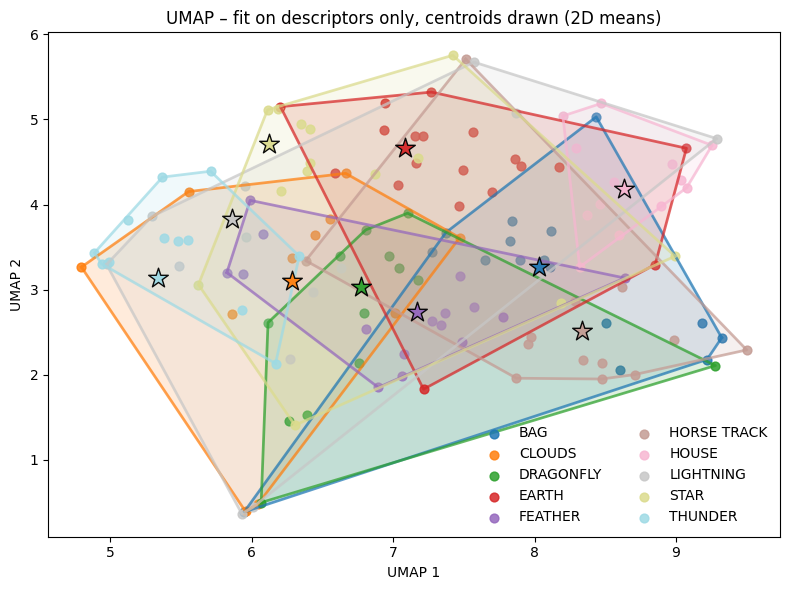

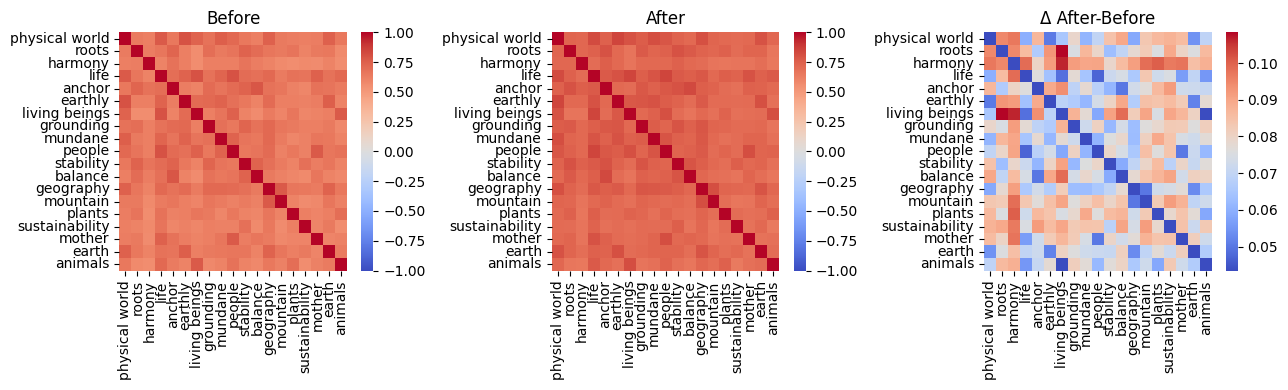

c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


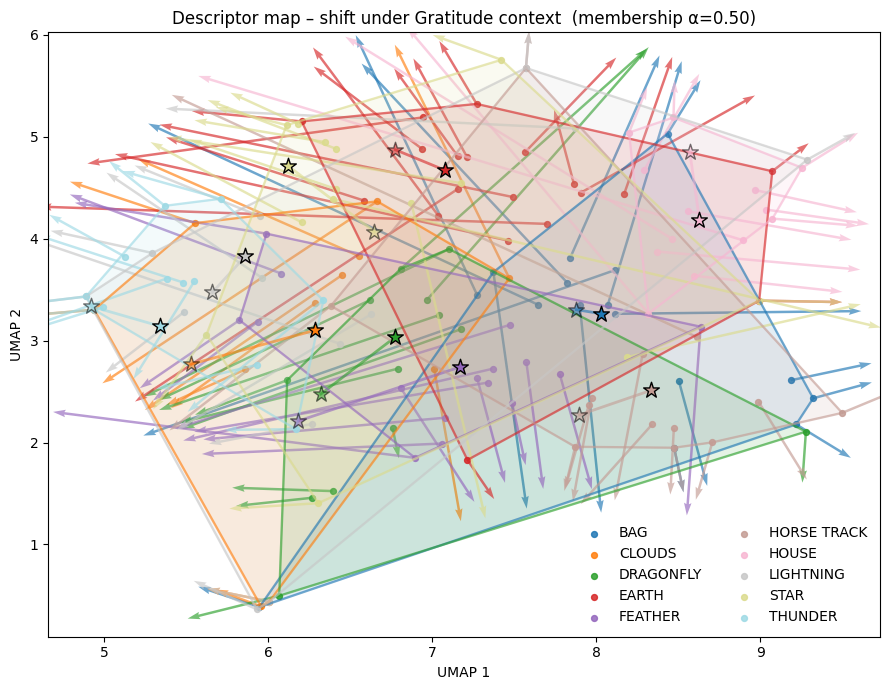

c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


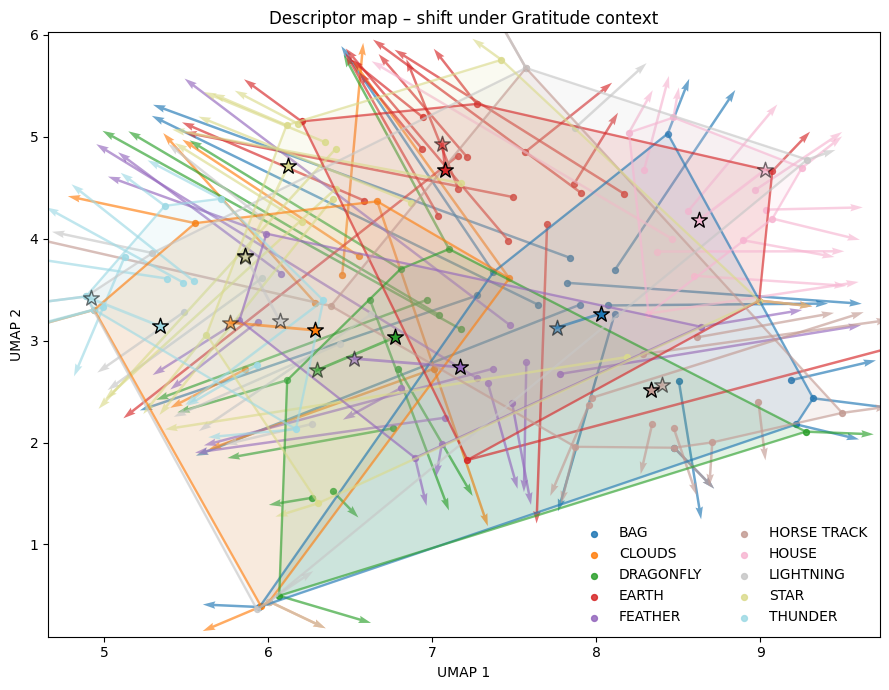

c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


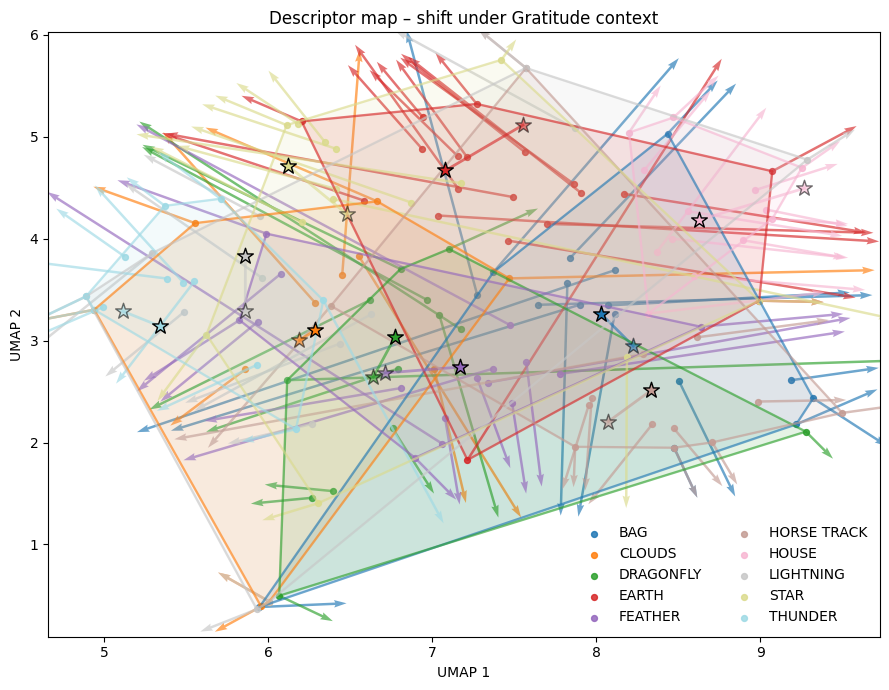

In [301]:
symbols_to_descriptors = {
"BAG": [
    "bag", "movement", "storage", "transport", "physical medicine",
    "spiritual medicine", "peace pipe", "healing", "necessity", "holding",
    "physical travel", "container", "physical protection", "carrying", "journey", "food"
],
"CLOUDS": [
    "clouds", "rain", "spiritual connection", "vision", "spiritual knowledge",
    "spirit world", "portal", "transcendence", "wisdom", "openness of the plane", "vastness"
],
"DRAGONFLY": [
    "dragonfly", "resilience", "ancient connection", "ancestral", "confirmation",
    "message", "spiritual travel", "flight", "astral travel", "lightly", "blessing",
    "patience", "survival"
],
"EARTH": [
    "earth", "people", "animals", "living beings", "plants", "roots", "mother",
    "geography", "mountain", "earthly", "mundane", "physical world", "harmony",
    "life", "sustainability", "balance", "grounding", "anchor", "stability"
],
"FEATHER": [
    "feather", "achievement", "honor", "bravery", "merit", "counting coup",
    "courage", "knowledge", "eagle", "bird", "ceremony", "humbleness", "nobility",
    "virtue", "valor", "strength"
],
"HORSE TRACK": [
    "horse track", "wealth", "travelling", "movement", "path", "motion",
    "riding", "hunting", "abundance", "dowry", "generosity", "west", "mobility"
],
"HOUSE": [
    "house", "nurturing", "protection", "security", "home", "community",
    "matriarchy", "camp", "family", "care", "council", "grandmother", "safety"
],
"LIGHTNING": [
    "lightning", "power", "thunderbird", "sacred clown", "spirituality", "storm",
    "spiritual connection", "electricity", "west", "fear", "grandfather", "danger",
    "goes out of the eyes of the thunderbird"
],
"STAR": [
    "star", "medicine wheel", "four directions", "north", "ancestral connection",
    "stardust in our bones", "elemental", "extraterrestrial", "star people", "soul",
    "source", "light", "outer space", "balance"
],
"THUNDER": [
    "thunder", "storm", "sound", "cry", "rain", "alert", "spirits arrival",
    "humility", "reminder of humanness", "fragility", "vulnerability", "out of the mouth of the thunderbird"
]
}

space = SymbolSpace(
    symbols_to_descriptors,
    TextEmbedder(
        backend="qwen3",
        pooling="eos",
        # default_instruction="Encode the meaning in its symbolic form. Each word is a facet of a symbol and is part of a bigger constellation of meaning.",
        # default_context = 'Distributed'
    ),
    contextual_embeddings=False
)

# 1) Fit on descriptors only (best to match plot_map_shift), draw centroids as 2D means
space.plot_map(method="umap", n_neighbors=15, with_hulls=True,
               include_centroids=True,
               title="UMAP – fit on descriptors only, centroids drawn (2D means)")


# Build per-symbol matrices under a sentence context
simdict = space.descriptor_similarity_matrices(
    # sentence="My skull is a mixture of heaven and hell",
    sentence="Drinking coffee is a blend of alchemy and destiny",
    beta=0.6, gate="relu", tau=0.2, order_by_attention=True
)

# Plot for one symbol
space.plot_symbol_similarity_heatmaps(simdict, symbol="EARTH")

space.plot_map_shift(
    sentence="The symmetry of the storm",
    method="umap",        # or "pca" for guaranteed transform
    gate="relu",
    tau=0.1,
    membership_alpha=0.5,
    with_hulls=True,
    title="Descriptor map – shift under Gratitude context",
    include_centroids=True,
    normalize_centroids=False,
)
space.plot_map_shift(
    sentence="The symmetry of the storm",
    method="umap",        # or "pca" for guaranteed transform
    gate="softmax",
    tau=0.1,
    membership_alpha=0.0,
    within_symbol_softmax=True,
    with_hulls=True,
    title="Descriptor map – shift under Gratitude context",
    include_centroids=True,
    normalize_centroids=False,
)

space.plot_map_shift(
    sentence="The symmetry of the storm",
    method="umap",        # or "pca" for guaranteed transform
    gate="softmax",
    tau=0.1,
    membership_alpha=0.0,
    within_symbol_softmax=False,
    with_hulls=True,
    title="Descriptor map – shift under Gratitude context",
    include_centroids=True,
    normalize_centroids=False,
)

In [307]:
def plot_alluvial_community_shift(
    space,
    *,
    sentence=None, weights=None, beta=0.6, gate="relu", tau=0.2, k=8,
    sym_filter=None,             # restrict to these symbols
    min_move_strength=0.0, top_n=None,
    title="Alluvial: community reassignment (before → after)",
    color_dict=None,             # space.get_symbol_color_dict()
    use_plotly=True              # fallback to matplotlib if Plotly not available
):
    """
    Builds communities before/after (kNN graph) and draws a Sankey/Alluvial
    showing how many descriptors flow from community i (before) to j (after).
    Flows are stacked per symbol color for quick archetypal reading.
    """
    import numpy as np, collections
    moved, P0, P1 = community_shift(
        space, sentence=sentence, weights=weights,
        beta=beta, gate=gate, tau=tau, k=k,
        sym_filter=sym_filter,
        min_move_strength=min_move_strength,
        top_n=top_n
    )

    # Collect all descriptors that are inside the filtered set (including non-movers)
    if sym_filter:
        keep_idx = sorted({i for s in sym_filter for i in space.symbol_to_idx.get(s, [])})
        names = [space.descriptors[i] for i in keep_idx]
    else:
        names = list(space.descriptors)

    # Community labels
    coms0 = sorted(set(P0.get(n, -1) for n in names if P0.get(n, -1) != -1))
    coms1 = sorted(set(P1.get(n, -1) for n in names if P1.get(n, -1) != -1))
    if not coms0 or not coms1:
        print("[plot_alluvial_community_shift] No communities to plot.")
        return

    # Flow counts broken down by symbol
    flow = collections.defaultdict(lambda: collections.Counter())
    # also count per-symbol to color subflows
    flow_sym = collections.defaultdict(lambda: collections.Counter())  # (c0,c1) -> symbol -> count

    for n in names:
        c0 = P0.get(n, -1); c1 = P1.get(n, -1)
        if c0 == -1 or c1 == -1: 
            continue
        if sym_filter and space.owner[n] not in sym_filter:
            continue
        flow[(c0, c1)] += 1
        flow_sym[(c0, c1)][space.owner[n]] += 1

    # palette
    syms_present = sorted({space.owner[n] for n in names if (P0.get(n,-1)!=-1 and P1.get(n,-1)!=-1)})
    if color_dict is None:
        import matplotlib.pyplot as plt
        cols = plt.cm.tab20(np.linspace(0, 1, max(1, len(syms_present))))
        cdict = {s: cols[i] for i, s in enumerate(syms_present)}
    else:
        cdict = {s: color_dict.get(s, (0.5,0.5,0.5,1.0)) for s in syms_present}

    # Try Plotly Sankey first
    if use_plotly:
        try:
            import plotly.graph_objects as go
            # Nodes = left communities + right communities
            left_labels  = [f"Before c{c}" for c in coms0]
            right_labels = [f"After  c{c}"  for c in coms1]
            labels = left_labels + right_labels
            idx_left  = {c:i for i,c in enumerate(coms0)}
            idx_right = {c:i+len(coms0) for i,c in enumerate(coms1)}

            # Build one link per (c0,c1,symbol) so colors reflect symbols
            sources, targets, values, colors = [], [], [], []
            for (c0,c1), counter in flow_sym.items():
                for sym, cnt in counter.items():
                    sources.append(idx_left[c0])
                    targets.append(idx_right[c1])
                    values.append(cnt)
                    rgba = cdict[sym]
                    if len(rgba)==4:
                        r,g,b,a = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255), rgba[3])
                    else:
                        r,g,b = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255)); a=0.9
                    colors.append(f"rgba({r},{g},{b},{a:.3f})")

            fig = go.Figure(data=[go.Sankey(
                node=dict(label=labels, pad=18, thickness=16),
                link=dict(source=sources, target=targets, value=values, color=colors)
            )])
            fig.update_layout(title_text=title, font_size=12, height=520)
            fig.show()
            return
        except Exception:
            pass  # fall back to matplotlib

    # Minimal matplotlib fallback (stacked bands per (c0,c1))
    import matplotlib.pyplot as plt
    # Build left/right vertical stacks proportional to totals
    total_left = {c0:0 for c0 in coms0}
    total_right= {c1:0 for c1 in coms1}
    for (c0,c1), cnt in flow.items():
        total_left[c0]  += cnt
        total_right[c1] += cnt

    # Normalize to [0,1] height
    Lsum, Rsum = sum(total_left.values()), sum(total_right.values())
    ly = {c0: total_left[c0]/max(1,Lsum) for c0 in coms0}
    ry = {c1: total_right[c1]/max(1,Rsum) for c1 in coms1}

    # Vertical positions
    def blocks(sizes):
        y=0.0; out={}
        for k,v in sizes.items():
            out[k]=(y,y+v); y+=v
        return out

    Lpos = blocks(ly); Rpos = blocks(ry)

    # Plot
    plt.figure(figsize=(10,6))
    # left / right bars
    for c0,(y0,y1) in Lpos.items():
        plt.fill_between([0,0.05],[y0,y0],[y1,y1], color="#444", alpha=0.2)
        plt.text(-0.03, (y0+y1)/2, f"B c{c0}", ha="right", va="center")
    for c1,(y0,y1) in Rpos.items():
        plt.fill_between([0.95,1.0],[y0,y0],[y1,y1], color="#444", alpha=0.2)
        plt.text(1.03, (y0+y1)/2, f"A c{c1}", ha="left", va="center")

    # flows per symbol, stacked within each (c0,c1)
    for (c0,c1), counter in flow_sym.items():
        L0,L1 = Lpos[c0]
        R0,R1 = Rpos[c1]
        total = sum(counter.values())
        # maintain per-source offsets
        yL = getattr(plot_alluvial_community_shift, "_yL", {})
        yR = getattr(plot_alluvial_community_shift, "_yR", {})
        if c0 not in yL: yL[c0]=L0
        if c1 not in yR: yR[c1]=R0

        for sym, cnt in counter.items():
            h = (cnt/ max(1,total)) * ((L1-L0) if L1>L0 else (R1-R0))
            y0L, y1L = yL[c0], yL[c0]+h
            y0R, y1R = yR[c1], yR[c1]+h
            yL[c0]=y1L; yR[c1]=y1R

            X = np.linspace(0.05, 0.95, 30)
            Yt = np.linspace(y0L, y0R, 30)
            Yb = np.linspace(y1L, y1R, 30)
            plt.fill_between(X, Yt, Yb, color=cdict[sym], alpha=0.75, linewidth=0)

        plot_alluvial_community_shift._yL = yL
        plot_alluvial_community_shift._yR = yR

    plt.title(title); plt.xlim(-0.08, 1.08); plt.ylim(0,1); plt.axis('off'); plt.tight_layout(); plt.show()

def community_shift(
    space,
    *,
    sentence=None,
    weights=None,
    beta=0.6,
    gate="relu",
    tau=0.2,
    k=8,
    sym_filter=None,          # strict subset
    min_move_strength=0.0,    # |Δ mean sim| threshold
    top_n=None,               # keep top-N strongest
    require_label_change=True # NEW: if False, also report strong drifts inside same label
):
    import numpy as np
    import networkx as nx
    from sklearn.neighbors import kneighbors_graph

    # --- subset ---
    if sym_filter:
        keep_idx = sorted({i for s in sym_filter for i in space.symbol_to_idx.get(s, [])})
        names = [space.descriptors[i] for i in keep_idx]
        owners = {n: space.owner[n] for n in names}
        D0 = space.D[keep_idx]
        D1_all = space.descriptor_shifted_embeddings(
            weights=weights, sentence=sentence, beta=beta, gate=gate, tau=tau
        )
        D1 = D1_all[keep_idx]
    else:
        names  = list(space.descriptors)
        owners = dict(space.owner)
        D0 = space.D
        D1 = space.descriptor_shifted_embeddings(
            weights=weights, sentence=sentence, beta=beta, gate=gate, tau=tau
        )

    n = len(names)
    if n < 2: return [], {}, {}

    k_eff = max(1, min(k, n-1))

    def build_graph_and_W(D):
        A = kneighbors_graph(D, n_neighbors=k_eff, metric="cosine", mode="distance")
        W = (1.0 - A.toarray()).astype(np.float32)
        W = np.maximum(W, W.T)  # symmetrize
        G = nx.Graph()
        for i, nm in enumerate(names):
            G.add_node(nm, symbol=owners[nm], idx=i)
        for i in range(n):
            for j in range(i+1, n):
                w = float(W[i, j])
                if w > 0: G.add_edge(names[i], names[j], weight=w)
        return G, W

    G0, W0 = build_graph_and_W(D0)
    G1, W1 = build_graph_and_W(D1)

    try:
        import community as community_louvain
        P0 = community_louvain.best_partition(G0, weight="weight")
        P1 = community_louvain.best_partition(G1, weight="weight")
    except Exception:
        comms0 = nx.algorithms.community.greedy_modularity_communities(G0, weight="weight")
        comms1 = nx.algorithms.community.greedy_modularity_communities(G1, weight="weight")
        P0 = {n: cid for cid, com in enumerate(comms0) for n in com}
        P1 = {n: cid for cid, com in enumerate(comms1) for n in com}

    name2idx = {nm: i for i, nm in enumerate(names)}
    def mean_internal_sim(W, comm_nodes, i_idx):
        if not comm_nodes: return 0.0
        js = [name2idx[m] for m in comm_nodes if m != names[i_idx]]
        if not js: return 0.0
        return float(np.mean(W[i_idx, js]))

    moved = []
    for nm in names:
        c0 = P0.get(nm, -1); c1 = P1.get(nm, -1)
        i = name2idx[nm]
        old_members = [x for x, cc in P0.items() if cc == c0]
        new_members = [x for x, cc in P1.items() if cc == c1]

        # honor sym_filter strictly
        if sym_filter and owners[nm] not in sym_filter:
            continue

        m_old = mean_internal_sim(W0, old_members, i)
        m_new = mean_internal_sim(W1, new_members, i)
        move_strength = abs(m_new - m_old)

        if move_strength < float(min_move_strength):
            continue
        if require_label_change and (c0 == c1):
            continue  # skip pure “drifts” if user wants label changes only

        moved.append((nm, c0, c1, move_strength))

    moved.sort(key=lambda x: x[3], reverse=True)
    if top_n and top_n > 0:
        moved = moved[:top_n]
    return moved, P0, P1


plot_alluvial_community_shift(
    space,
    sentence="The imagination of the fire is warming the existential dust of the universe.",
    sym_filter=["EARTH","THUNDER","CLOUDS","STAR"],
    tau=0.1,
    color_dict=cdict,
    use_plotly=True
)


AttributeError: 'int' object has no attribute 'items'

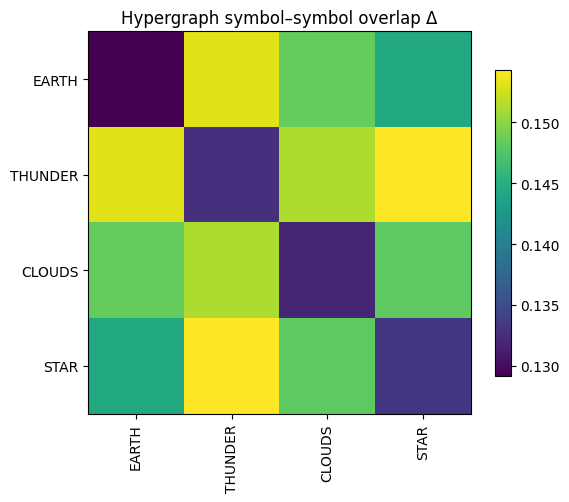

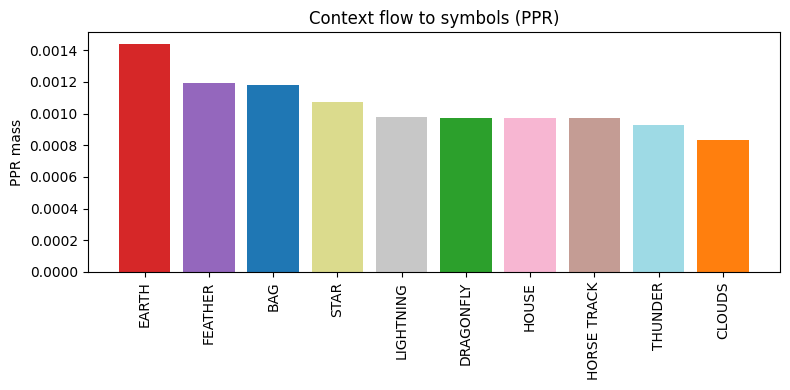

EARTH 0.0014 → ['anchor:0.0103', 'life:0.0087', 'balance:0.0084', 'people:0.0083', 'roots:0.0083']
FEATHER 0.0012 → ['honor:0.0080', 'humbleness:0.0079', 'strength:0.0078', 'merit:0.0078', 'knowledge:0.0076']
BAG 0.0012 → ['holding:0.0086', 'journey:0.0081', 'movement:0.0081', 'container:0.0078', 'carrying:0.0074']
STAR 0.0011 → ['balance:0.0084', 'north:0.0084', 'star:0.0082', 'soul:0.0080', 'elemental:0.0079']
LIGHTNING 0.0010 → ['danger:0.0090', 'storm:0.0087', 'west:0.0081', 'fear:0.0079', 'power:0.0075']


In [317]:
def plot_edge_bundled_delta(
    space, *,
    sentence=None, weights=None,
    beta=0.6, gate="relu", tau=0.2,
    within_symbol=False,          # set False to see cross-symbol bundles
    sym_filter=None, only_symbol=None,
    top_abs_edges=120, min_abs_delta=0.02,
    connected_only=True,
    halo_scale=1800.0,            # attention → halo (outline) size
    node_size=240,
    edge_width_scale=8.0,
    title="Bundled Δ-links with attention halos",
    color_dict=None
):
    import numpy as np, networkx as nx, matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # 1) delta graph
    Gd = context_delta_graph(
        space, sentence=sentence, weights=weights, beta=beta, gate=gate, tau=tau,
        within_symbol=within_symbol, sym_filter=sym_filter, only_symbol=only_symbol,
        top_abs_edges=top_abs_edges, min_abs_delta=min_abs_delta, connected_only=connected_only
    )
    if Gd.number_of_nodes() == 0:
        print("[plot_edge_bundled_delta] empty graph.")
        return

    # 2) attention (within symbol) for halos
    att = {}
    if sentence:
        vctx = space.ctx_vec(weights=weights, sentence=sentence)
        for s in sorted({Gd.nodes[n]["symbol"] for n in Gd.nodes()}):
            idx = [space.desc_idx[d] for d in space.symbols_to_descriptors[s]]
            sims = (space.D[idx] @ vctx)
            a = softmax(sims, tau=tau)
            for d, a_i in zip(space.symbols_to_descriptors[s], a):
                if d in Gd.nodes:
                    att[d] = float(a_i)
    else:
        for n in Gd.nodes: att[n] = 0.0

    # 3) color palette
    syms_present = sorted({Gd.nodes[n]["symbol"] for n in Gd.nodes()})
    if color_dict is None:
        base = plt.cm.tab20(np.linspace(0, 1, max(1, len(syms_present))))
        cdict = {s: base[i] for i, s in enumerate(syms_present)}
    else:
        cdict = {s: color_dict.get(s, (0.5,0.5,0.5,1.0)) for s in syms_present}

    # 4) build a small “bundling” meta-graph:
    # add a hub node per symbol; route cross-symbol edges via these hubs.
    Gb = nx.Graph()
    for n in Gd.nodes:
        Gb.add_node(n, kind="desc", symbol=Gd.nodes[n]["symbol"])
    hubs = {}
    for s in syms_present:
        hub = f"_HUB_{s}"
        hubs[s] = hub
        Gb.add_node(hub, kind="hub", symbol=s)

    # descriptor ↔ own hub (thin, invisible support edges)
    for n in Gd.nodes:
        s = Gd.nodes[n]["symbol"]
        Gb.add_edge(n, hubs[s], weight=0.0001, _support=True)

    # bundle cross-symbol edges via hubs; within-symbol stay direct
    for u, v, d in Gd.edges(data=True):
        su, sv = Gd.nodes[u]["symbol"], Gd.nodes[v]["symbol"]
        if su == sv:
            Gb.add_edge(u, v, delta=d["delta"], abs_delta=d["abs_delta"], sign=d["sign"], _support=False)
        else:
            # route u->hub_su and hub_sv->v plus hub_su<->hub_sv (thicker)
            Gb.add_edge(u, hubs[su], delta=d["delta"], abs_delta=d["abs_delta"], sign=d["sign"], _support=True)
            Gb.add_edge(hubs[su], hubs[sv], delta=d["delta"], abs_delta=d["abs_delta"], sign=d["sign"], _support=False, _is_bundle=True)
            Gb.add_edge(hubs[sv], v, delta=d["delta"], abs_delta=d["abs_delta"], sign=d["sign"], _support=True)

    # 5) layout (spring compresses bundles naturally)
    pos = nx.spring_layout(Gb, seed=42, k=0.6)

    # 6) draw
    plt.figure(figsize=(10,8))

    # descriptor nodes with halos (outline width scales with attention)
    nlist = [n for n in Gb.nodes if Gb.nodes[n].get("kind")=="desc"]
    halo_w = [1.0 + halo_scale * att.get(n,0.0) for n in nlist]
    nx.draw_networkx_nodes(
        Gb, pos, nodelist=nlist,
        node_color=[cdict[Gb.nodes[n]["symbol"]] for n in nlist],
        node_size=node_size, edgecolors="black", linewidths=halo_w, alpha=0.95
    )
    nx.draw_networkx_labels(Gb, pos, labels={n:n for n in nlist}, font_size=8)

    # hubs (small, faint)
    hlist = list(hubs.values())
    nx.draw_networkx_nodes(Gb, pos, nodelist=hlist, node_color="white", node_size=80, edgecolors="gray", linewidths=0.5, alpha=0.6)

    # edges
    up  = [(u,v,d) for u,v,d in Gb.edges(data=True) if not d.get("_support") and d.get("delta",0)>0]
    dn  = [(u,v,d) for u,v,d in Gb.edges(data=True) if not d.get("_support") and d.get("delta",0)<0]
    w_up = [max(0.4, d["abs_delta"]*edge_width_scale) for _,_,d in up]
    w_dn = [max(0.4, d["abs_delta"]*edge_width_scale) for _,_,d in dn]
    nx.draw_networkx_edges(Gb, pos, edgelist=[(u,v) for u,v,_ in up], edge_color="tab:red", width=w_up, alpha=0.75)
    nx.draw_networkx_edges(Gb, pos, edgelist=[(u,v) for u,v,_ in dn], edge_color="tab:blue", width=w_dn, alpha=0.55)

    # legend
    handles = [Patch(facecolor=cdict[s], edgecolor='black', label=s) for s in syms_present]
    if handles: plt.legend(handles=handles, title="Symbols", fontsize=8)

    plt.title(title)
    plt.axis("off"); plt.tight_layout(); plt.show()


def symbol_facet_dashboard(
    space, symbol, *,
    sentence=None, weights=None,
    beta=0.6, gate="relu", tau=0.2,
    k_ego=6, order_by_attention=True,
    title=None
):
    import numpy as np, matplotlib.pyplot as plt
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics.pairwise import cosine_similarity

    descs = list(space.symbols_to_descriptors[symbol])
    idx   = [space.desc_idx[d] for d in descs]
    D0_sym = space.D[idx]
    D1_all = space.descriptor_shifted_embeddings(weights=weights, sentence=sentence, beta=beta, gate=gate, tau=tau)
    D1_sym = D1_all[idx]

    # attention over this symbol
    if sentence:
        vctx = space.ctx_vec(weights=weights, sentence=sentence)
        sims = (D0_sym @ vctx)
        att  = softmax(sims, tau=tau)
    else:
        att = np.ones(len(descs))/len(descs)

    # order
    order = np.argsort(att)[::-1] if order_by_attention else np.arange(len(descs))
    descs_o = [descs[i] for i in order]
    att_o   = att[order]
    S0 = cosine_similarity(D0_sym[order])
    S1 = cosine_similarity(D1_sym[order])
    Sd = S1 - S0
    np.fill_diagonal(Sd, 0.0)

    # ego-network (kNN) before vs after
    k_eff = min(k_ego+1, len(descs))
    nn0 = NearestNeighbors(metric="cosine", n_neighbors=k_eff).fit(D0_sym)
    nn1 = NearestNeighbors(metric="cosine", n_neighbors=k_eff).fit(D1_sym)
    _, I0 = nn0.kneighbors(D0_sym, n_neighbors=k_eff)
    _, I1 = nn1.kneighbors(D1_sym, n_neighbors=k_eff)
    base_neighbors = set((i, j) for i,row in enumerate(I0) for j in row[1:])
    ctx_neighbors  = set((i, j) for i,row in enumerate(I1) for j in row[1:])
    added   = ctx_neighbors - base_neighbors
    removed = base_neighbors - ctx_neighbors

    # plot
    fig = plt.figure(figsize=(13,4.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.2,1.4,1.4])

    # (A) attention stem
    ax0 = fig.add_subplot(gs[0,0])
    ax0.stem(range(len(att_o)), att_o, use_line_collection=True)
    ax0.set_xticks(range(len(descs_o))); ax0.set_xticklabels(descs_o, rotation=90)
    ax0.set_ylabel("attention"); ax0.set_title(f"{symbol}: attention (τ={tau})")

    # (B) Δ internal matrix
    ax1 = fig.add_subplot(gs[0,1])
    im = ax1.imshow(Sd, cmap="coolwarm", vmin=min(0, Sd.min()), vmax=max(0, Sd.max()))
    ax1.set_title("Δ internal cosine (after - before)")
    ax1.set_xticks(range(len(descs_o))); ax1.set_xticklabels(descs_o, rotation=90)
    ax1.set_yticks(range(len(descs_o))); ax1.set_yticklabels(descs_o)
    fig.colorbar(im, ax=ax1, shrink=0.8)

    # (C) ego kNN changes
    ax2 = fig.add_subplot(gs[0,2])
    ax2.axis('off')
    txt = [f"Added ({len(added)}):"] + [f"  {descs[i]} → {descs[j]}" for i,j in sorted(list(added))[:12]]
    txt += ["", f"Removed ({len(removed)}):"] + [f"  {descs[i]} → {descs[j]}" for i,j in sorted(list(removed))[:12]]
    ax2.text(0.0, 1.0, "\n".join(txt), va='top', family='monospace')
    fig.suptitle(title or f"Facet dashboard – {symbol} | context: {sentence!r}", y=1.02)
    plt.tight_layout(); plt.show()


def hypergraph_overlap(
    space, *,
    sentence=None, weights=None,
    beta=0.6, gate="relu", tau=0.2,
    sym_filter=None
):
    import numpy as np
    # restrict symbols
    symbols = sym_filter if sym_filter else list(space.symbols)
    S = len(symbols)
    # matrices
    D0 = space.D
    D1 = space.descriptor_shifted_embeddings(weights=weights, sentence=sentence, beta=beta, gate=gate, tau=tau)
    # precompute index lists
    idxs = {s: [space.desc_idx[d] for d in space.symbols_to_descriptors[s]] for s in symbols}

    def pair_mean_cos(D, a, b):
        if len(idxs[a])==0 or len(idxs[b])==0: return 0.0
        A = D[idxs[a]]; B = D[idxs[b]]
        return float(np.mean(A @ B.T))

    M0 = np.zeros((S,S), dtype=np.float32)
    M1 = np.zeros((S,S), dtype=np.float32)
    for i,a in enumerate(symbols):
        for j,b in enumerate(symbols):
            if j<i: continue
            M0[i,j]=M0[j,i]=pair_mean_cos(D0,a,b)
            M1[i,j]=M1[j,i]=pair_mean_cos(D1,a,b)
    return symbols, M0, M1, (M1-M0)

def plot_hypergraph_delta(symbols, dM, *,
                          title="Hypergraph symbol–symbol overlap Δ",
                          cmap="coolwarm", figsize=(6,5)):
    import numpy as np, matplotlib.pyplot as plt
    
    # Determine symmetric limits around zero
    vmax = np.max(np.abs(dM))
    vmin = np.min(np.abs(dM))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(dM, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(len(symbols))); ax.set_xticklabels(symbols, rotation=90)
    ax.set_yticks(range(len(symbols))); ax.set_yticklabels(symbols)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    plt.show()



def bipartite_ppr_flow(space, *, sentence, alpha=0.85, tau=0.2, top_syms=10, top_desc_per_sym=5):
    import numpy as np, networkx as nx

    # personalization over descriptors from the sentence
    sent_vec = space.embedder.encode([sentence])[0]
    sent_vec /= (np.linalg.norm(sent_vec)+1e-9)
    sims = space.D @ sent_vec
    p_desc = softmax(sims, tau=tau)
    pers = {f"D:{d}": float(w) for d,w in zip(space.descriptors, p_desc)}
    # run PPR on the *existing* bipartite G
    pr = nx.pagerank(space.G, alpha=alpha, personalization=pers, weight="weight")

    # split mass
    sym_mass = {n[2:]: v for n,v in pr.items() if n.startswith("S:")}
    desc_mass= {n[2:]: v for n,v in pr.items() if n.startswith("D:")}

    # top symbols + their top descriptors by PR
    syms_sorted = sorted(sym_mass.items(), key=lambda x: x[1], reverse=True)[:top_syms]
    out = []
    for s, sv in syms_sorted:
        ds = space.symbols_to_descriptors[s]
        tops = sorted([(d, desc_mass.get(d,0.0)) for d in ds], key=lambda x: x[1], reverse=True)[:top_desc_per_sym]
        out.append({"symbol": s, "score": sv, "top_descriptors": tops})
    return sym_mass, desc_mass, out

def plot_ppr_flow(sym_mass, *, color_dict=None, title="Symbol PPR mass (context flow)"):
    import matplotlib.pyplot as plt, numpy as np
    items = sorted(sym_mass.items(), key=lambda x:x[1], reverse=True)
    syms  = [k for k,_ in items]
    vals  = [v for _,v in items]
    if color_dict is None:
        cols = plt.cm.tab20(np.linspace(0,1,max(1,len(syms))))
        cdict = {s: cols[i] for i,s in enumerate(syms)}
    else:
        cdict = color_dict
    barc = [cdict.get(s, (0.6,0.6,0.6,1.0)) for s in syms]
    plt.figure(figsize=(8,4))
    plt.bar(range(len(syms)), vals, color=barc)
    plt.xticks(range(len(syms)), syms, rotation=90)
    plt.ylabel("PPR mass"); plt.title(title); plt.tight_layout(); plt.show()


cdict = getattr(space, "get_symbol_color_dict", lambda: None)()

# # (1) Bundled Δ-links with attention halos
# plot_edge_bundled_delta(
#     space,
#     sentence="The imagination of the fire is warming the existential dust of the universe.",
#     within_symbol=False,
#     color_dict=cdict
# )

# # (2) Facet dashboard for one symbol
# symbol_facet_dashboard(
#     space, "THUNDER",
#     sentence="The imagination of the fire is warming the existential dust of the universe.",
#     tau=0.1
# )

# (3) Hypergraph overlaps (before/after + Δ)
symbols, M0, M1, dM = hypergraph_overlap(space, sentence="...", tau=0.1, sym_filter=["EARTH","THUNDER","CLOUDS","STAR"])
plot_hypergraph_delta(symbols, dM, title="Hypergraph symbol–symbol overlap Δ", cmap="viridis", figsize=(6,5))

# (4) Bipartite PPR flow
sym_mass, desc_mass, report = bipartite_ppr_flow(space, sentence="...", tau=0.1)
plot_ppr_flow(sym_mass, color_dict=cdict, title="Context flow to symbols (PPR)")
for r in report[:5]:
    print(r["symbol"], f"{r['score']:.4f}", "→", [f"{d}:{s:.4f}" for d,s in r["top_descriptors"]])


[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.


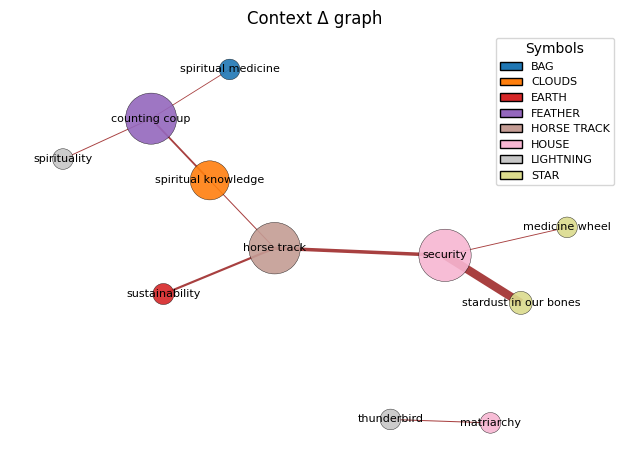

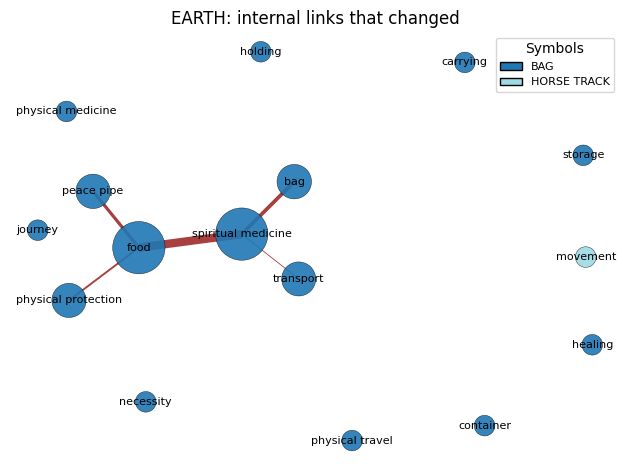

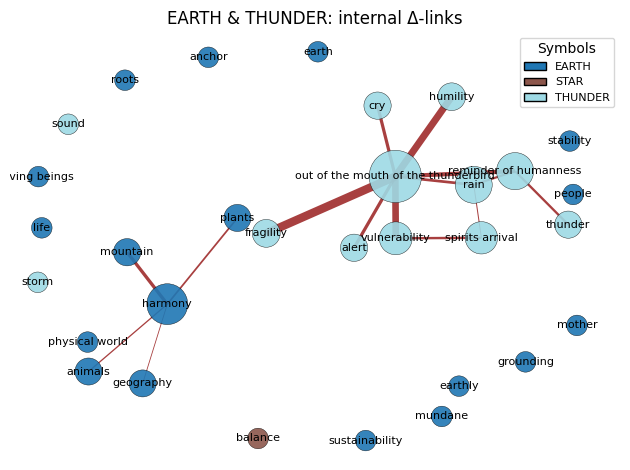

In [299]:
def context_delta_graph(space, *, sentence=None, weights=None,
                        beta=0.6, gate="relu", tau=0.2,
                        top_abs_edges=150, sym_filter=None,
                        min_abs_delta=0.02,
                        within_symbol=True,   # keep only same-symbol edges
                        only_symbol=None,     # restrict to a single symbol
                        connected_only=False  # NEW: keep only nodes with edges
                        ):
    """
    Build a graph where edges are weighted by Δcos = cos_after - cos_before.
    Keeps the strongest |Δ| edges.

    within_symbol=True  -> keep only edges whose endpoints belong to the same symbol.
    only_symbol="EARTH" -> convenience: restrict to one symbol’s descriptors.
    sym_filter=[...]    -> restrict to a set of symbols (still respects within_symbol flag).
    connected_only=True -> only keep nodes that are part of at least one edge.
    """
    import networkx as nx
    import numpy as np

    # --- descriptor matrices (before/after) ---
    D0 = space.D
    D1 = space.descriptor_shifted_embeddings(weights=weights, sentence=sentence,
                                             beta=beta, gate=gate, tau=tau)

    # --- choose which descriptors to keep ---
    if only_symbol is not None:
        sym_filter = [only_symbol]  # override

    if sym_filter:
        keep_idx = []
        for s in sym_filter:
            keep_idx.extend(space.symbol_to_idx[s])
        keep_idx = sorted(set(keep_idx))
    else:
        keep_idx = list(range(len(space.descriptors)))

    D0 = D0[keep_idx]
    D1 = D1[keep_idx]
    names  = [space.descriptors[i] for i in keep_idx]
    owners = {space.descriptors[i]: space.owner[space.descriptors[i]] for i in keep_idx}

    # --- deltas ---
    C0 = D0 @ D0.T
    C1 = D1 @ D1.T
    Delta = C1 - C0
    np.fill_diagonal(Delta, 0.0)

    # --- optionally mask cross-symbol pairs ---
    if within_symbol:
        sym_of_row = np.array([owners[n] for n in names])
        same = (sym_of_row[:, None] == sym_of_row[None, :])
        Delta = Delta * same.astype(Delta.dtype)

    # --- pick strongest |Δ| edges (upper triangle only) ---
    tri = np.triu_indices_from(Delta, k=1)
    vals = Delta[tri]
    order = np.argsort(np.abs(vals))[::-1]

    G = nx.Graph()
    for n in names:
        G.add_node(n, kind="desc", symbol=owners[n])

    kept = 0
    for k in order:
        if kept >= top_abs_edges:
            break
        d = float(vals[k])
        if abs(d) < min_abs_delta:
            continue
        i, j = tri[0][k], tri[1][k]
        if d == 0.0:
            continue
        G.add_edge(names[i], names[j],
                   delta=d,
                   sign=("up" if d > 0 else "down"),
                   abs_delta=abs(d))
        kept += 1

    # --- remove isolated nodes if requested ---
    if connected_only:
        G.remove_nodes_from(list(nx.isolates(G)))

    return G



def plot_delta_graph(
    G,
    node_alpha=0.9,
    min_edge_alpha=0.15,
    title="Context Δ graph",
    color_dict=None,            # pass space.get_symbol_color_dict() for consistency
    *,
    # node sizing
    node_size_base=220,
    node_size_scale=1200.0,
    normalize_node_sizes=True,  # NEW
    # edge sizing
    edge_width_min=0.6,         # NEW: explicit min width
    edge_width_max=6.0,         # NEW: explicit max width
    normalize_edge_widths=True  # NEW
):
    import matplotlib.pyplot as plt, networkx as nx
    from matplotlib.patches import Patch
    import numpy as np

    # Symbols present
    syms_present = sorted({G.nodes[n]["symbol"] for n in G.nodes()})

    # Colors
    if color_dict is None:
        base = plt.cm.tab20(np.linspace(0, 1, max(1, len(syms_present))))
        cdict = {s: base[i] for i, s in enumerate(syms_present)}
    else:
        cdict = {s: color_dict.get(s, (0.5, 0.5, 0.5, 1.0)) for s in syms_present}

    pos = nx.spring_layout(G, seed=42, k=0.6)

    # ---- node sizes from total |Δ| of incident edges ----
    abs_sum = {n: 0.0 for n in G.nodes()}
    for u, v, d in G.edges(data=True):
        a = float(d.get("abs_delta", 0.0))
        abs_sum[u] += a
        abs_sum[v] += a

    if normalize_node_sizes and len(abs_sum) > 0:
        arr = np.array(list(abs_sum.values()), dtype=float)
        lo, hi = arr.min(), arr.max()
        if hi - lo < 1e-12:
            norm = np.ones_like(arr) * 0.5
        else:
            norm = (arr - lo) / (hi - lo)
        node_sizes = [node_size_base + node_size_scale * n for n in norm]
        node_sizes = dict(zip(G.nodes(), node_sizes))
    else:
        node_sizes = {n: node_size_base + node_size_scale * abs_sum[n] for n in G.nodes()}

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=list(G.nodes()),
        node_color=[cdict[G.nodes[n]["symbol"]] for n in G.nodes()],
        edgecolors="black", linewidths=0.3,
        alpha=node_alpha,
        node_size=[node_sizes[n] for n in G.nodes()]
    )

    # ---- edge widths from |Δ|, min–max normalized ----
    edges = list(G.edges(data=True))
    abs_d = np.array([float(d.get("abs_delta", 0.0)) for _, _, d in edges], dtype=float)
    if normalize_edge_widths and len(abs_d) > 0:
        lo, hi = abs_d.min(), abs_d.max()
        if hi - lo < 1e-12:
            nabs = np.ones_like(abs_d) * 0.5
        else:
            nabs = (abs_d - lo) / (hi - lo)
        widths = edge_width_min + nabs * (edge_width_max - edge_width_min)
    else:
        widths = np.maximum(edge_width_min, abs_d * (edge_width_max - edge_width_min))

    width_map = { (u, v): w for (u, v, _), w in zip(edges, widths) }
    width_map.update({ (v, u): w for (u, v, _), w in zip(edges, widths) })  # undirected

    up = [(u, v) for u, v, d in edges if d["delta"] > 0]
    dn = [(u, v) for u, v, d in edges if d["delta"] < 0]
    w_up = [width_map[(u, v)] for u, v in up]
    w_dn = [width_map[(u, v)] for u, v in dn]

    nx.draw_networkx_edges(G, pos, edgelist=up, edge_color="darkred",  width=w_up, alpha=0.75)
    nx.draw_networkx_edges(G, pos, edgelist=dn, edge_color="tab:blue", width=w_dn, alpha=0.55)

    nx.draw_networkx_labels(G, pos, font_size=8)

    handles = [Patch(facecolor=cdict[s], edgecolor='black', label=s) for s in syms_present]
    if handles:
        plt.legend(handles=handles, title="Symbols", loc='best', fontsize=8)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


space = SymbolSpace(    symbols_to_descriptors,
    TextEmbedder(
        backend="qwen3",
        pooling="eos",),
    contextual_embeddings=False
)
cdict = space.get_symbol_color_dict()

G = context_delta_graph(
    space,
    # sentence="I travel between inner and outer worlds",
    # sentence="I want to know how to dissolve autopoiesis into smaller conscious entities",
    sentence="Legitimacy of the kernel",
    gate="relu", tau=0.1, beta=0.6,
    top_abs_edges=9,
    within_symbol=False,
    connected_only=True
)
plot_delta_graph(G, title=f"Context Δ graph",
                 color_dict=cdict,
)


# 2) Only EARTH’s internal links
G = context_delta_graph(space, sentence="banana lovers",
                        only_symbol="BAG", within_symbol=True, top_abs_edges=5)
plot_delta_graph(G, title="EARTH: internal links that changed")

# 3) Compare two specific symbols, but still only their *internal* links
G = context_delta_graph(space, sentence="The symmetry of the storm",
                        sym_filter=["EARTH","THUNDER"], within_symbol=True, top_abs_edges=15)
plot_delta_graph(G, title="EARTH & THUNDER: internal Δ-links")


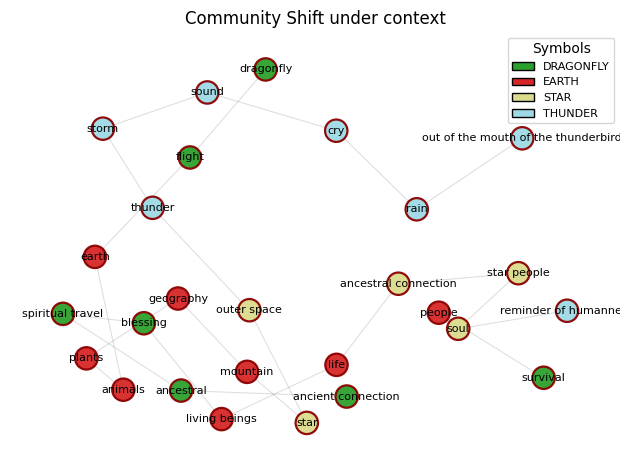

In [305]:
def community_shift(space, *, sentence=None, weights=None,
                    beta=0.6, gate="relu", tau=0.2, k=8,
                    sym_filter=None):
    """
    Faster community shift:
      - builds kNN graphs from sparse kneighbors_graph (no dense toarray)
      - avoids nested i/j loops
    Returns: moved, P0, P1
    """
    import numpy as np
    import networkx as nx
    from sklearn.neighbors import kneighbors_graph

    # Choose subset once
    if sym_filter:
        keep_idx = sorted({i for s in sym_filter for i in space.symbol_to_idx[s]})
    else:
        keep_idx = list(range(len(space.descriptors)))

    names  = [space.descriptors[i] for i in keep_idx]
    owners = {n: space.owner[n] for n in names}

    # Before / after
    D0 = space.D[keep_idx]
    D1 = space.descriptor_shifted_embeddings(weights=weights, sentence=sentence,
                                             beta=beta, gate=gate, tau=tau)[keep_idx]

    k_eff = min(k, max(1, len(names)-1))

    def build_graph_sparse(D):
        # cosine distances in a sparse (n x n) graph (row->its k neighbors)
        A = kneighbors_graph(D, n_neighbors=k_eff, metric="cosine", mode="distance")
        A = A.tocoo()

        G = nx.Graph()
        for n in names:
            G.add_node(n, symbol=owners[n])

        # Convert distances to similarities on the fly: w = 1 - d
        # Keep only upper triangle to avoid duplicate undirected edges
        for i, j, d in zip(A.row, A.col, A.data):
            if i < j:
                w = 1.0 - float(d)
                if w > 0.0:
                    G.add_edge(names[i], names[j], weight=w)
        return G

    G0 = build_graph_sparse(D0)
    G1 = build_graph_sparse(D1)

    # Partition helpers
    try:
        import community as community_louvain  # python-louvain
        def part(G):
            return community_louvain.best_partition(G, weight="weight")
    except Exception:
        def part(G):
            # Greedy modularity (returns list of sets)
            coms = nx.algorithms.community.greedy_modularity_communities(G, weight="weight")
            return {n: c for c, com in enumerate(coms) for n in com}

    P0 = part(G0)
    P1 = part(G1)

    # Who moved?
    moved = [(n, P0.get(n, -1), P1.get(n, -1))
             for n in G0.nodes()
             if P0.get(n, -1) != P1.get(n, -1)]

    return moved, P0, P1

def plot_community_shift(space, moved, P0, P1, title="Community Shift", color_dict=None):
    import matplotlib.pyplot as plt
    import networkx as nx
    from matplotlib.patches import Patch

    # Small graph of moved nodes only (keeps layout quick)
    G = nx.Graph()
    for n, c0, c1 in moved:
        G.add_node(n, symbol=space.owner[n], c0=c0, c1=c1)

    # Connect nodes that landed in the SAME new community (light structure for layout)
    by_new = {}
    for n, _, c1 in moved:
        by_new.setdefault(c1, []).append(n)
    for com_nodes in by_new.values():
        for i in range(len(com_nodes)-1):
            G.add_edge(com_nodes[i], com_nodes[i+1], thin=True)

    pos = nx.spring_layout(G, seed=42, k=0.7)

    # Colors consistent with your space
    if color_dict is None:
        base = plt.cm.tab20(np.linspace(0, 1, max(1, len(space.symbols))))
        cdict = {s: base[i] for i, s in enumerate(space.symbols)}
    else:
        cdict = {s: color_dict.get(s, (0.5, 0.5, 0.5, 1.0)) for s in space.symbols}

    node_colors = [cdict[G.nodes[n]["symbol"]] for n in G.nodes()]
    # Thicker red border for nodes that moved
    moved_nodes = list(G.nodes())

    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8, edge_color="gray")
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=moved_nodes,
        node_color=node_colors,
        edgecolors="darkred", linewidths=1.6,  # highlight movers
        alpha=0.95, node_size=260
    )
    nx.draw_networkx_labels(G, pos, font_size=8)

    # Legend: only symbols present
    syms_present = sorted({G.nodes[n]["symbol"] for n in G.nodes()})
    handles = [Patch(facecolor=cdict[s], edgecolor='black', label=s) for s in syms_present]
    if handles:
        plt.legend(handles=handles, title="Symbols", loc='best', fontsize=8)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

moved, P0, P1 = community_shift(
    space,
    sentence="silence is gold",
    beta=0.5, gate="cos", tau=0.08, k=15,
    sym_filter=["EARTH", "THUNDER", "DRAGONFLY", 'STAR']
)
plot_community_shift(space, moved, P0, P1,
                     title="Community Shift under context",
                     color_dict=space.get_symbol_color_dict())

In [ ]:
def attention_weighted_delta(space, symbol, *, sentence=None, tau=0.2,
                             beta=0.6, gate="relu"):
    import numpy as np

    idx = space.symbol_to_idx[symbol]
    desc = space.symbols_to_descriptors[symbol]

    # Before/after
    D0 = space.D[idx]
    D1_all = space.descriptor_shifted_embeddings(sentence=sentence, beta=beta, gate=gate, tau=tau)
    D1 = D1_all[idx]

    # Within-symbol attention (softmax over symbol’s descriptors)
    vctx = space.ctx_vec(sentence=sentence)
    sims = (space.D[idx] @ vctx)
    a = softmax(sims, tau=tau)  # attention over this symbol’s descriptors

    C0 = D0 @ D0.T
    C1 = D1 @ D0.T if False else D1 @ D1.T  # keep symmetric after/before
    Delta = C1 - C0  # Δ cosine
    np.fill_diagonal(Delta, 0.0)

    A = a[:, None] * a[None, :]   # attention co-mass for pairs
    return desc, Delta, A          # you can use A*Delta to prioritize salient shifts


c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


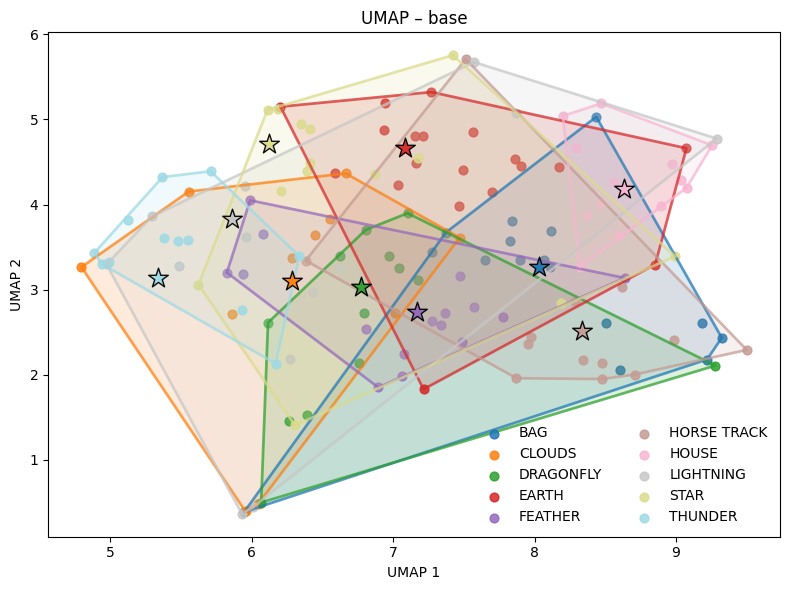

c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


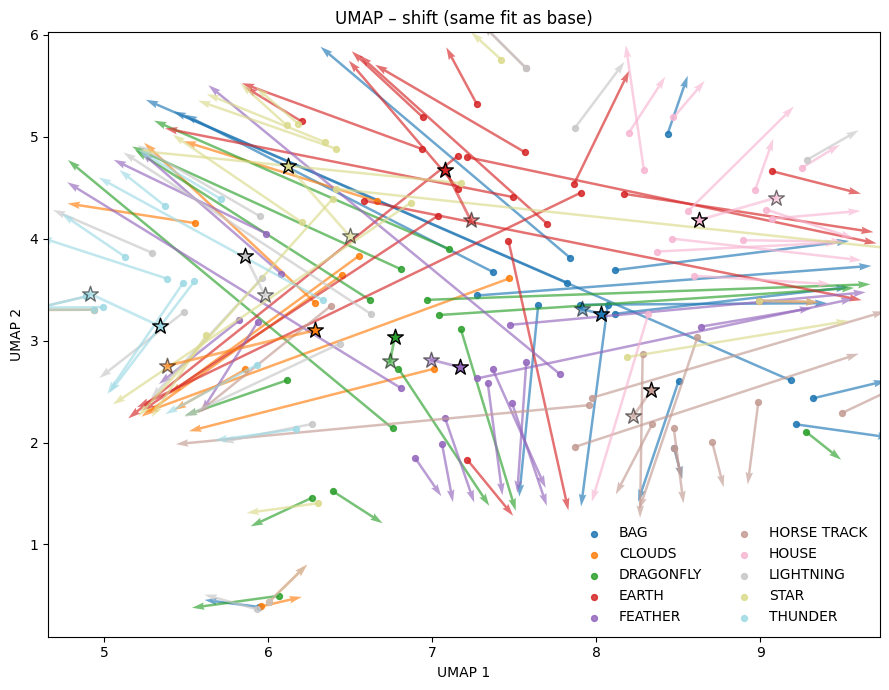

In [ ]:
space.plot_map(method="umap", n_neighbors=15, with_hulls=True,
                
               include_centroids=True, normalize_centroids=False,
               title="UMAP – base")

space.plot_map_shift(method="umap", sentence = 'Love', n_neighbors=15, with_hulls=True,
                     include_centroids=True, normalize_centroids=False,
                     tau=0.02, beta=0.6, gate="relu",
                     title="UMAP – shift (same fit as base)")

[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.


c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


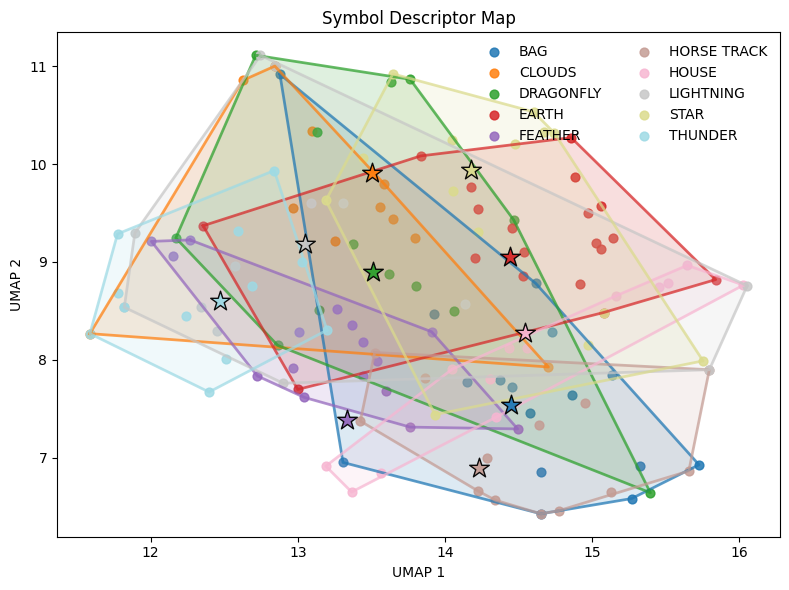


[Ambiguity metrics]
Symbol       | Dispersion |    Leakage |    Entropy
----------------------------------------------
LIGHTNING    |      0.900 |      0.855 |      0.565
BAG          |      0.774 |      0.688 |      0.656
DRAGONFLY    |      0.738 |      0.880 |      0.900
CLOUDS       |      0.486 |      0.900 |      0.241
THUNDER      |      0.370 |      0.286 |      0.268
STAR         |      0.311 |      0.562 |      0.622
HORSE TRACK  |      0.310 |      0.187 |      0.270
EARTH        |      0.228 |      0.100 |      0.663
HOUSE        |      0.133 |      0.261 |      0.100
FEATHER      |      0.100 |      0.266 |      0.479


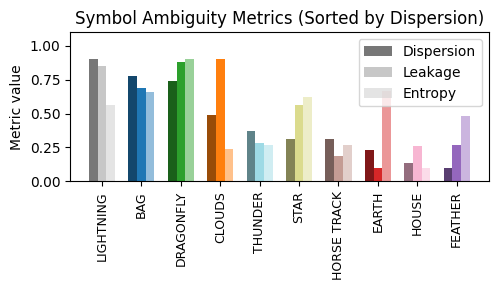


Predictions per sentence:

Sentence  1: A lone wolf howls beneath the silver moon, echoing through the forest.
    THUNDER      | score=0.800  coh=1.000  ppr=0.500
    LIGHTNING    | score=0.696  coh=0.827  ppr=0.500
    STAR         | score=0.598  coh=0.664  ppr=0.500
    CLOUDS       | score=0.595  coh=0.659  ppr=0.500
    DRAGONFLY    | score=0.485  coh=0.476  ppr=0.500
    EARTH        | score=0.479  coh=0.464  ppr=0.500
    FEATHER      | score=0.446  coh=0.410  ppr=0.500
    HORSE TRACK  | score=0.428  coh=0.380  ppr=0.500
    BAG          | score=0.341  coh=0.235  ppr=0.500
    HOUSE        | score=0.200  coh=0.000  ppr=0.500
----------------------------------------------------
Sentence  2: Children chase fireflies as dusk settles over the quiet meadow.
    THUNDER      | score=0.800  coh=1.000  ppr=0.500
    LIGHTNING    | score=0.771  coh=0.952  ppr=0.500
    DRAGONFLY    | score=0.652  coh=0.753  ppr=0.500
    STAR         | score=0.649  coh=0.748  ppr=0.500
    HORSE TRACK 

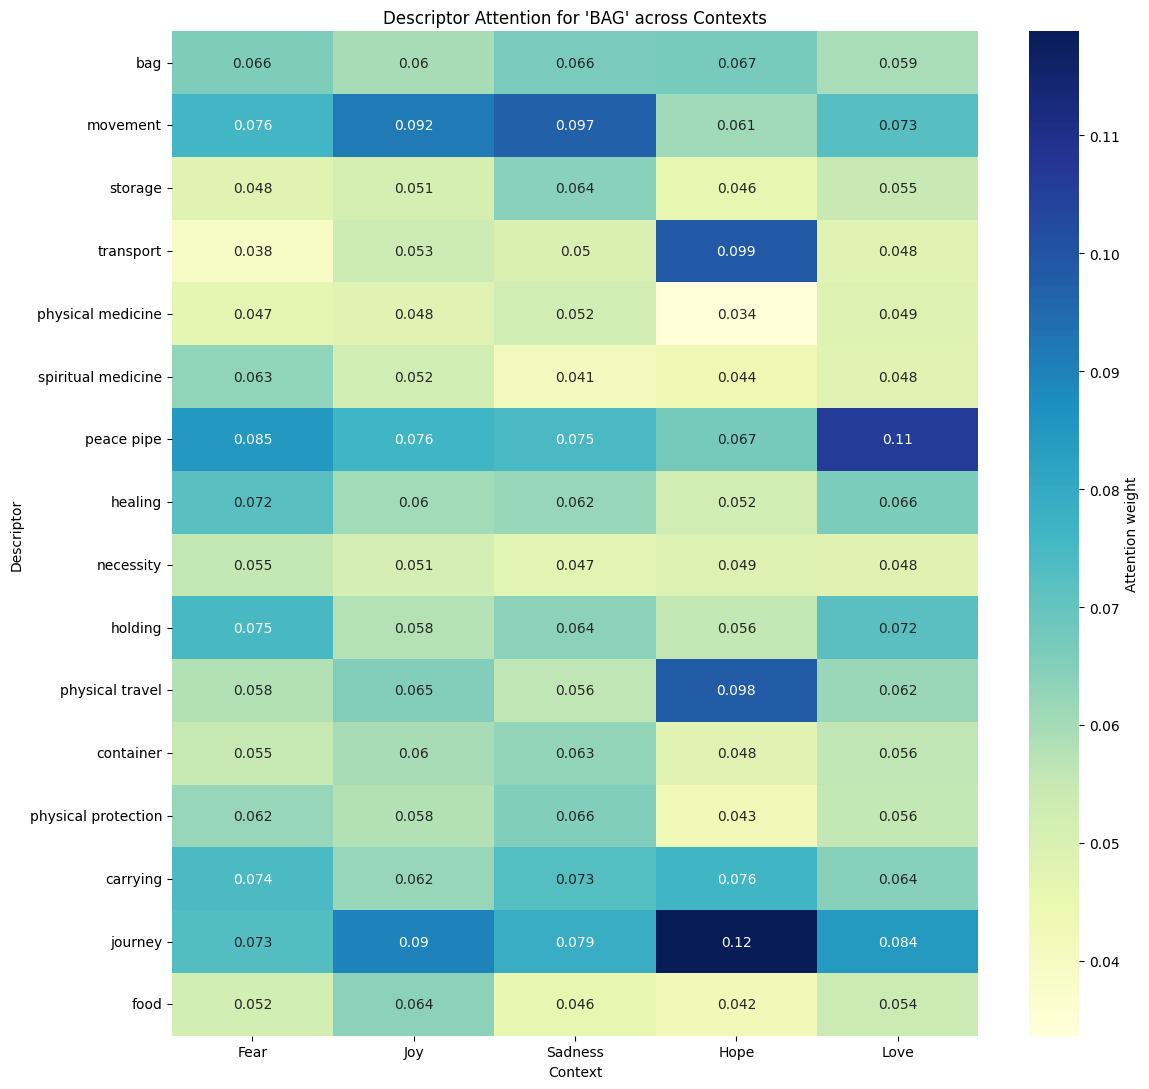

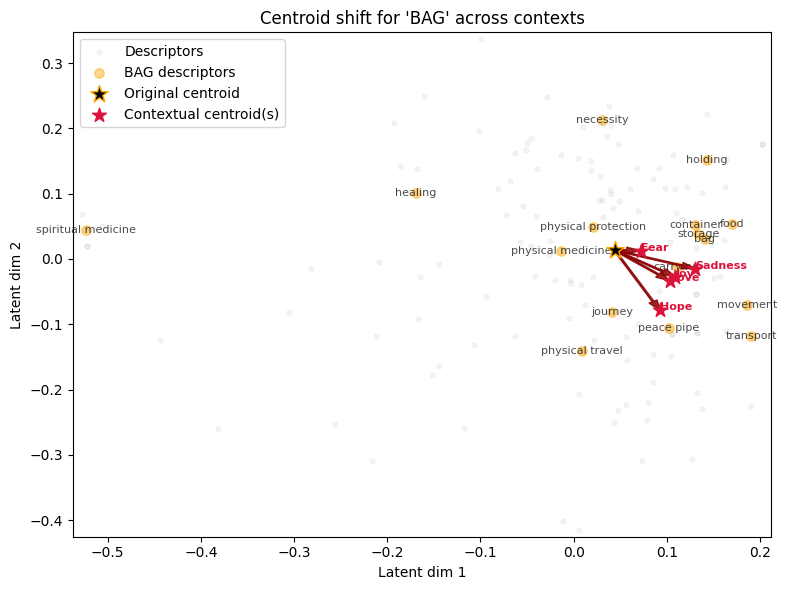

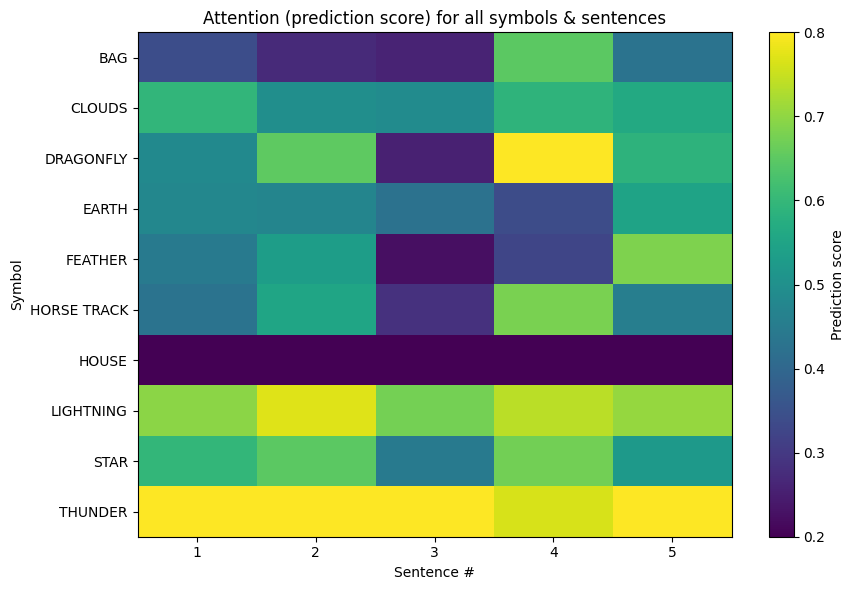


Most predicted symbol per sentence:
  Sentence  1: THUNDER      | 'A lone wolf howls beneath the silver moon, echoing through the forest.'
  Sentence  2: THUNDER      | 'Children chase fireflies as dusk settles over the quiet meadow.'
  Sentence  3: THUNDER      | 'A sudden storm scatters leaves across the empty playground.'
  Sentence  4: DRAGONFLY    | 'The old train whistles in the distance, promising journeys unknown.'
  Sentence  5: THUNDER      | 'A feather drifts gently onto the surface of a still pond.'


In [41]:
import seaborn as sns
from numpy import dot
from numpy.linalg import norm
import numpy as np


import random

# --- SYMBOL SET ---


# Add original Jungian archetypes and their descriptors
# symbols_to_descriptors = {
#     "Shadow": [
#         "repressed", "hidden", "unconscious", "instinct", "darkness", "unknown", "fear", "denial", "projection"
#     ],
#     "Self": [
#         "wholeness", "integration", "unity", "center", "balance", "totality", "individuation", "completion", "core"
#     ],
#     "Anima": [
#         "feminine", "emotion", "intuition", "receptive", "nurturing", "creativity", "relationship", "unconscious feminine", "feeling"
#     ],
#     "Animus": [
#         "masculine", "logic", "reason", "assertive", "will", "structure", "authority", "unconscious masculine", "thinking"
#     ],
#     'Persona': [
#         "mask", "social role", "public face", "adaptation", "identity", "conformity", "presentation", "outer self", "image"
#     ],
# }

space = SymbolSpace(
    symbols_to_descriptors,
    TextEmbedder(
        backend="qwen3",
        pooling="eos",
        # default_instruction="Encode the meaning in its symbolic form. Each word is a facet of a symbol and is part of a bigger constellation of meaning.",
        # default_context = 'Distributed'
    ),
    contextual_embeddings=False
)


# 1) Descriptor map
space.plot_map(title="Symbol Descriptor Map", method='umap', n_neighbors=15)

# --- Compute and print table with correct order ---

# --- Compute and print table with correct order ---

symbols = list(space.symbols)
disp_values = [space.dispersion(s) for s in symbols]
leak_values = [space.leakage(s) for s in symbols]
entr_values = [space.soft_entropy(s) for s in symbols]

# Choose sort key (e.g., by dispersion descending)
sort_idx = np.argsort(disp_values)[::-1]
symbols_sorted = [symbols[i] for i in sort_idx]
disp_sorted = [disp_values[i] for i in sort_idx]
leak_sorted = [leak_values[i] for i in sort_idx]
entr_sorted = [entr_values[i] for i in sort_idx]

# normalize values to [0, 1] for better visualization
disp_sorted = (np.array(disp_sorted) - np.min(disp_sorted)) / (np.max(disp_sorted) - np.min(disp_sorted))
leak_sorted = (np.array(leak_sorted) - np.min(leak_sorted)) / (np.max(leak_sorted) - np.min(leak_sorted))
entr_sorted = (np.array(entr_sorted) - np.min(entr_sorted)) / (np.max(entr_sorted) - np.min(entr_sorted))

# rescale between 0.1 and 0.9 for better visibility
disp_sorted = 0.1 + 0.8 * disp_sorted
leak_sorted = 0.1 + 0.8 * leak_sorted
entr_sorted = 0.1 + 0.8 * entr_sorted

# Print table
print("\n[Ambiguity metrics]")
print(f"{'Symbol':<12} | {'Dispersion':>10} | {'Leakage':>10} | {'Entropy':>10}")
print("-" * 46)
for s, disp, leak, entr in zip(symbols_sorted, disp_sorted, leak_sorted, entr_sorted):
    print(f"{s:<12} | {disp:10.3f} | {leak:10.3f} | {entr:10.3f}")

x = np.arange(len(symbols_sorted))
bar_width = 0.22

# Get base colors from tab20 colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(symbols_sorted)))
colors = [colors[i] for i in sort_idx]

# Helper to darken a color (scales RGB toward black)
def darken(color, factor=0.6):
    return tuple(factor * np.array(color[:3]))  # ignore alpha
def lighten(color, factor=0.6):
    return tuple((1 - factor) + factor * np.array(color[:3]))
plt.figure(figsize=(5, 3))
# Plot each metric as a separate bar, side by side
plt.bar(x - bar_width, disp_sorted, width=bar_width,
        color=[darken(c) for c in colors], label="Dispersion")
plt.bar(x, leak_sorted, width=bar_width,
        color=colors, label="Leakage")
plt.bar(x + bar_width, entr_sorted, width=bar_width,
        color=[lighten(c, factor=0.8) for c in colors], alpha=0.6, label="Entropy")

plt.xticks(x, symbols_sorted, rotation=90, fontsize=9)
plt.ylabel("Metric value")
plt.title("Symbol Ambiguity Metrics (Sorted by Dispersion)")
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()





# --- 10 pseudo-random sentences ---
random_sentences = [
    "A lone wolf howls beneath the silver moon, echoing through the forest.",
    "Children chase fireflies as dusk settles over the quiet meadow.",
    "A sudden storm scatters leaves across the empty playground.",
    "The old train whistles in the distance, promising journeys unknown.",
    "A feather drifts gently onto the surface of a still pond."
]


n_sent = len(random_sentences)
symbols = list(symbols_to_descriptors)
n_sym = len(symbols)

# --- Store results for all sentences ---
symbol_preds = np.zeros((n_sent, n_sym))   # rows: sentences, cols: symbols

print("\nPredictions per sentence:\n")
for i, sent in enumerate(random_sentences):
    preds = space.propose(sentence=sent, topk=n_sym, tau=0.2, use_ppr=False)
    print(f"Sentence {i+1:2d}: {sent}")
    for j, (s, score, coh, ppr) in enumerate(preds):
        symbol_preds[i, symbols.index(s)] = score
        print(f"    {s:12s} | score={score:.3f}  coh={coh:.3f}  ppr={ppr:.3f}")
    print("-" * 52)



symbol = "BAG"
contexts = [{"sentence": s} for s in random_sentences]
plot_descriptor_attention_heatmap(
    space, symbol, contexts,
    context_labels=["Fear", "Joy", "Sadness", "Hope", "Love"],
    tau=0.2
)



# for i, sent in enumerate(random_sentences):
#     orig_cent = space.symbol_centroids[symbol]
#     context_vec = space.embedder.encode([sent])[0]
#     cos_sim_orig = dot(orig_cent, context_vec) / (norm(orig_cent) * norm(context_vec) + 1e-9)
#     emb, _ = space.conditioned_symbol(symbol, sentence=sent, tau=0.3)
#     cos_sim_cond = dot(emb, context_vec) / (norm(emb) * norm(context_vec) + 1e-9)
#     print(f"Context {i}: {sent}")
#     print(f"  Original centroid:      {cos_sim_orig:.3f}")
#     print(f"  Conditioned centroid:   {cos_sim_cond:.3f}")
#     print(f"  ΔCosSim:                {cos_sim_cond - cos_sim_orig:.3f}")
#     print("------")


# sentence = "Sadness floats in the sky as a gentle rain."
# tau = 0.01
# _, attn = space.conditioned_symbol(symbol, sentence=sentence, tau=tau)

# # Print all attention weights sorted from high to low
# for desc, w in sorted(attn.items(), key=lambda x: -x[1]):
#     print(f"{desc:18s} {w:.4f}")


plot_symbol_centroid_shifts(space, symbol, random_sentences,
                            tau=0.05, method="pca",
                            context_labels=["Fear", "Joy", "Sadness", "Hope", "Love"],
                            title=f"Centroid shift for '{symbol}' across contexts")

# plot_contexts_and_symbol_centroid(space, symbol, random_sentences,
#                                   tau=0.2, method="pca",
#                                   context_labels=["Fear", "Joy", "Sadness", "Hope", "Love"])


# --- Heatmap: all symbol prediction scores for all sentences ---
plt.figure(figsize=(9, 6))
im = plt.imshow(symbol_preds.T, aspect='auto', cmap='viridis')
plt.yticks(range(n_sym), symbols)
plt.xticks(range(n_sent), [f"{i+1}" for i in range(n_sent)], rotation=0)
plt.xlabel("Sentence #")
plt.ylabel("Symbol")
plt.title("Attention (prediction score) for all symbols & sentences")
plt.colorbar(im, label='Prediction score')
plt.tight_layout()
plt.show()

# --- For reference: print which symbol was top for each sentence
print("\nMost predicted symbol per sentence:")
for i, sent in enumerate(random_sentences):
    top_idx = np.argmax(symbol_preds[i])
    print(f"  Sentence {i+1:2d}: {symbols[top_idx]:12s} | '{sent}'")


# # ------ weighted-symbol context ------
# weights_ctx = {"BAG": 0.7, "STAR": 0.3, "EARTH": 0.5}

# # ------ simple ambiguity metrics ------
# print("\n[Ambiguity metrics]")
# for s in space.symbols:
#     print(f"{s:6s} | dispersion={space.dispersion(s):.3f}  "
#             f"leakage={space.leakage(s):.3f}  "
#             f"entropy={space.soft_entropy(s):.3f}")

# space.plot_symbol_predictions(weights=weights_ctx, sentence=None,
#                                 title="Symbol prediction scores for context")
# # or with PageRank:
# pr = space._ppr(weights_ctx, 0.85)
# space.plot_graph(context_symbols=["Mystery", "Star"], pagerank_scores=pr)



C:\Users\skite\AppData\Local\Temp\ipykernel_54748\2014150299.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_54748\2014150299.py:83: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_54748\2014150299.py:83: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_54748\2014150299.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

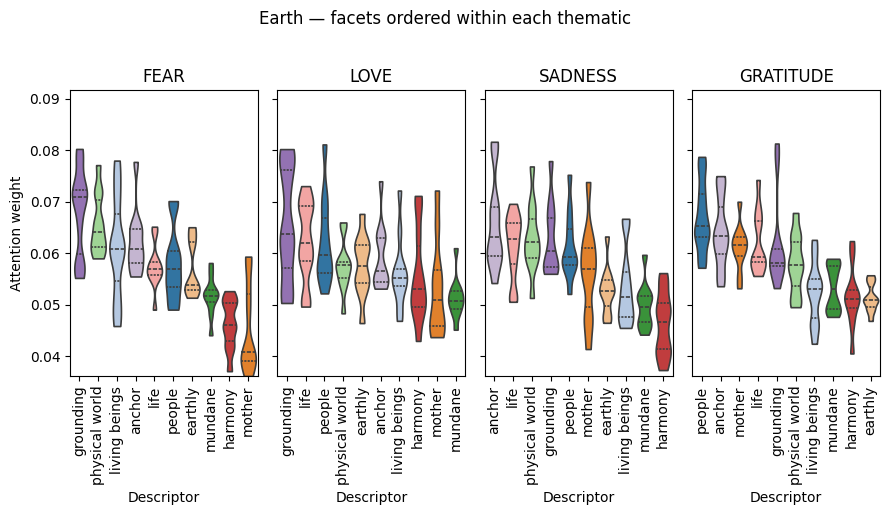

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_thematic_first_descriptor_violins(
    space,
    symbol: str,
    contexts: dict,                 # {"FEAR": [s1..s5], "LOVE":[..], ...}
    tau: float = 0.2,
    top_n: int = None,              # limit to the top N descriptors (per overall mean)
    order_by: str = "context_median",  # "context_median" | "context_mean"
    figsize=(9, 5),
    title=None
):
    """
    One subplot per THEMATIC. Inside each subplot, show violins for *descriptors*,
    ordered *within that thematic* by their typical activation (median or mean).
    Each violin aggregates the attention values across the ~5 sentences in that thematic.
    """
    descriptors = space.symbols_to_descriptors[symbol]
    rows = []

    # 1) Collect attention weights per sentence, per context, per descriptor
    for ctx_label, sentences in contexts.items():
        for i, sent in enumerate(sentences):
            _, attn = space.conditioned_symbol(symbol, sentence=sent, tau=tau)
            for d in descriptors:
                rows.append({
                    "context": ctx_label,
                    "descriptor": d,
                    "attention": float(attn.get(d, 0.0)),
                    "sentence_ix": i
                })

    df = pd.DataFrame(rows)

    # 2) Optional: select a subset of descriptors globally (by overall mean)
    if top_n is not None:
        top_desc = (
            df.groupby("descriptor")["attention"]
              .mean()
              .sort_values(ascending=False)
              .head(top_n)
              .index.tolist()
        )
        df = df[df["descriptor"].isin(top_desc)]

    # 3) Build a per-context descriptor order (sorted within each thematic)
    ctx_orders = {}
    for ctx in contexts.keys():
        sub = df[df["context"] == ctx]
        if order_by == "context_mean":
            order = (sub.groupby("descriptor")["attention"]
                         .mean()
                         .sort_values(ascending=False)
                         .index.tolist())
        else:  # "context_median"
            order = (sub.groupby("descriptor")["attention"]
                         .median()
                         .sort_values(ascending=False)
                         .index.tolist())
        ctx_orders[ctx] = order

    # 4) Plot: one column per thematic (shared y-scale = attention)
    n_ctx = len(contexts)
    fig, axes = plt.subplots(1, n_ctx, figsize=figsize, sharey=True)

    if n_ctx == 1:
        axes = [axes]

    maxval = df["attention"].max()
    minval = df["attention"].min()
    n_descriptors = len(df["descriptor"].unique())
    colors = sns.color_palette("tab20", n_colors=n_descriptors)
    color_order = {d: colors[i % len(colors)] for i, d in enumerate(df["descriptor"].unique())}
    for ax, ctx in zip(axes, contexts.keys()):
        ordered_descriptors = ctx_orders[ctx]
        ordered_colors = [color_order[d] for d in ordered_descriptors]
        sub = df[df["context"] == ctx]
        order = ctx_orders[ctx]
        sns.violinplot(
            data=sub,
            x="descriptor",
            y="attention",
            order=order,
            cut=0,
            scale="width",
            inner="quartile",
            ax=ax,
            palette=ordered_colors,
            linewidth=1.2,
            bw=0.3
        )
        # Add horizontal line at 0.5 for reference
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.6
        )

        ax.set_title(ctx)
        ax.set_xlabel("Descriptor")
        ax.set_ylabel("Attention weight")
        ax.set_ylim(minval, maxval+ 0.01)  # leave some space above max
        ax.tick_params(axis='x', rotation=90)
    
    fig.suptitle(title or f"{symbol}: descriptor attention per thematic (ordered within each thematic)", y=1.02)
    plt.tight_layout()
    plt.show()

    return df


contexts = {
    "FEAR": [
        "A shadow moves behind the trees; breath turns shallow.",
        "Cold wind rattles the window as footsteps approach.",
        "Eyes watch from the dark water below the boat.",
        "The cave narrows; the light behind fades away.",
        "An animal scream splits the night and then silence.",
        "A sudden howl echoes across the empty field.",
        "The lantern flickers as something brushes past.",
        "Footsteps stop just outside the locked door.",
        "A cold hand grips the back of my neck.",
        "The silence grows heavier with every heartbeat."
    ],
    "LOVE": [
        "Their hands met by the river at dusk.",
        "Breath synced with a heartbeat under warm light.",
        "A letter folded in a pocket carries a smile.",
        "Two paths converged beside the old willow.",
        "A quiet morning coffee became a promise.",
        "Eyes meet and laughter fills the room.",
        "A gentle touch lingers after goodbye.",
        "Shared secrets whispered beneath the stars.",
        "A song played softly in the kitchen.",
        "The warmth of an embrace on a cold night."
    ],
    "SADNESS": [
        "Rain kept the chair by the window empty.",
        "Echoes lingered after the song stopped.",
        "Footprints on the shore washed away too fast.",
        "The room remembered the laughter better than we did.",
        "A cracked cup waiting on the shelf.",
        "A faded photograph tucked in a drawer.",
        "The last light in the hallway flickers out.",
        "A suitcase packed but never opened.",
        "The scent of perfume long after she's gone.",
        "A single tear stains the letter unread."
    ],
    "GRATITUDE": [
        "Warm bread shared at sunrise after a long night.",
        "A stranger’s umbrella in sudden rain.",
        "Hands washed clean in the cold river.",
        "A soft blanket after the journey home.",
        "The last apple given without asking.",
        "A smile offered when hope was thin.",
        "A friend’s call just when it was needed.",
        "A gentle word that eased the pain.",
        "A door held open on a heavy day.",
        "A memory cherished more with each year."
    ]
}

_ = plot_thematic_first_descriptor_violins(
    space,
    symbol="EARTH",
    contexts=contexts,
    tau=0.2,
    top_n=10,                       # optional
    order_by="context_median",      # or "context_mean"
    title="Earth — facets ordered within each thematic"
)


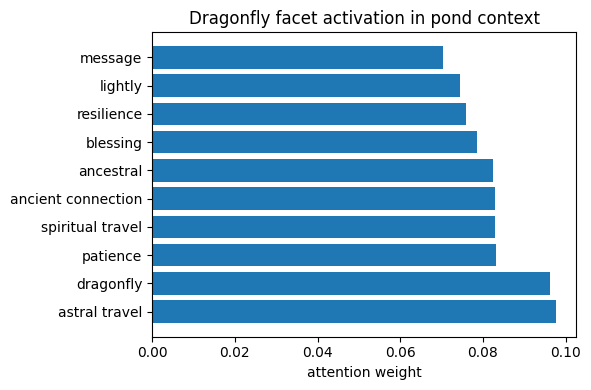

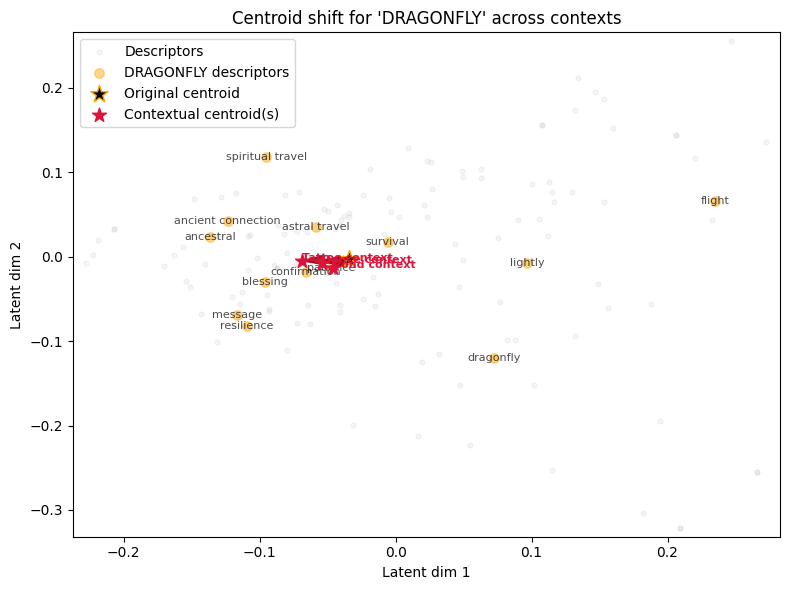

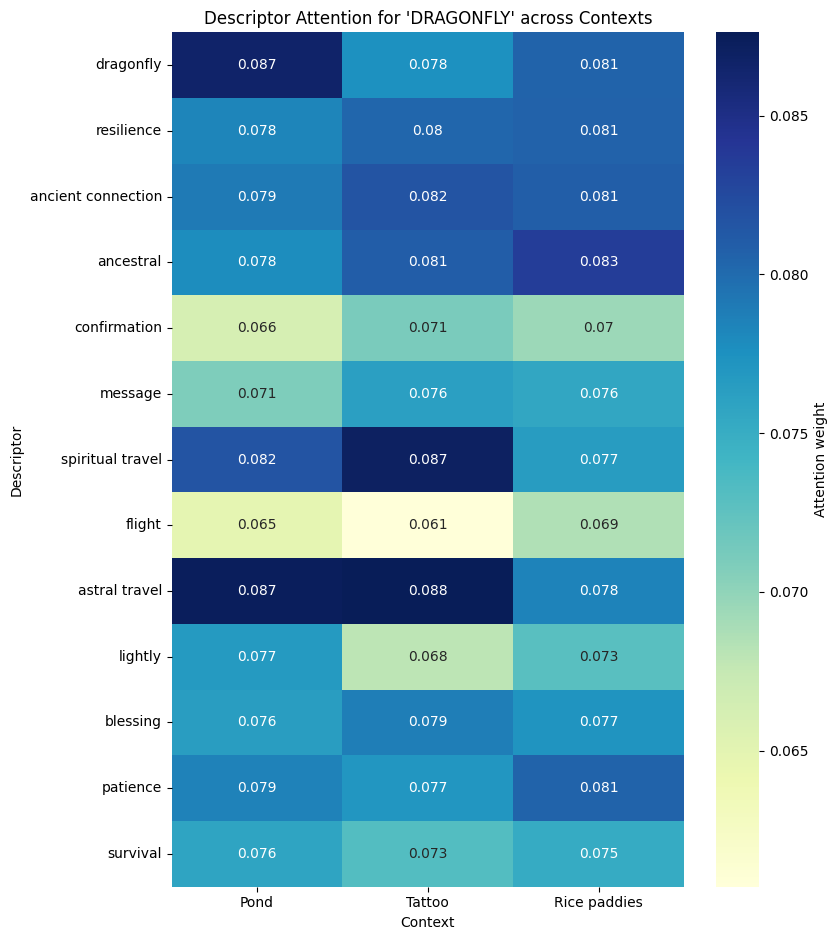

In [198]:
space.plot_attention(
    "DRAGONFLY",
    sentence="The shimmering lover hovers over the pond",
    tau=0.2,
    top_n=10,
    title="Dragonfly facet activation in pond context"
)
plot_symbol_centroid_shifts(space,
    "DRAGONFLY",
    sentences=[
        "The shimmering insect hovers over the pond",
        "tattoo symbolized freedom and transformation",
        "danced lightly above the water's surface"
    ],
    tau=0.2,
    context_labels=["Pond context", "Tattoo context", "Dance context"],
)

plot_descriptor_attention_heatmap(
    space,
    "DRAGONFLY",
    contexts=[
        {"sentence": "The shimmering hovers over the pond"},
        {"sentence": "tattoo symbolized freedom and transformation"},
        {"sentence": "dart above the rice paddies"}
    ],
    context_labels=["Pond", "Tattoo", "Rice paddies"],
    tau=0.4
)



In [256]:


embedder = TextEmbedder(backend="qwen3", pooling="eos",
                        # default_instruction="Represent the meaning of the input as a multistable, polymorphic and ambigous structure."
                        )

space = SymbolSpace(symbols_to_descriptors, embedder)

sentence = "I was swimming in the memories of the fire, dancing like a blooming dust."
sentence = 'The imagination of the fire is warming the existential dust of the universe.'
topk = 10

# Get PPR results
ppr_results = space.recommend_symbols_with_ppr_descriptors(sentence, topk=topk, tau=0.001, n_best=5)
# Get softmax results
softmax_results = space.recommend_symbols_with_softmax_attention(sentence, topk=topk, tau=0.1, n_best=5)

print(f"\nTop {topk} symbols for context: '{sentence}'\n")

print("=== Personalized PageRank (PPR) ===")
for res in ppr_results:
    descs = res['best_descriptors']
    desc_scores = res['descriptor_scores']
    desc_str = ", ".join([f"'{d}' (desc-PR={s:.3g})" for d, s in zip(descs, desc_scores)])
    print(f"  • {res['symbol']} (score={res['score']:.3f}): top descriptors = {desc_str}")

print("\n=== Softmax Attention ===")
for res in softmax_results:
    descs = res['best_descriptors']
    desc_scores = res['descriptor_scores']
    desc_str = ", ".join([f"'{d}' (attn={s:.3g})" for d, s in zip(descs, desc_scores)])
    print(f"  • {res['symbol']} (score={res['score']:.3f}): top descriptors = {desc_str}")


[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.

Top 10 symbols for context: 'The imagination of the fire is warming the existential dust of the universe.'

=== Personalized PageRank (PPR) ===
  • CLOUDS (score=0.002): top descriptors = 'spirit world' (desc-PR=0.155), 'transcendence' (desc-PR=0.00674), 'wisdom' (desc-PR=0.0067), 'portal' (desc-PR=0.00666), 'spiritual connection' (desc-PR=0.00647)
  • EARTH (score=0.001): top descriptors = 'life' (desc-PR=0.00684), 'anchor' (desc-PR=0.0067), 'people' (desc-PR=0.00665), 'physical world' (desc-PR=0.00661), 'stability' (desc-PR=0.00652)
  • BAG (score=0.001): top descriptors = 'movement' (desc-PR=0.00672), 'holding' (desc-PR=0.00663), 'journey' (desc-PR=0.00653), 'carrying' (desc-PR=0.00633), 'healing' (desc-PR=0.00632)
  • FEATHER (score=0.001): top descriptors = 'strength' (desc-PR=0.0066), 'eagle' (desc-PR=0.00653), 'virtue' (desc-PR=0.00653), 'honor' (desc-PR=0.00651), 'feather' (d

[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.


C:\Users\skite\AppData\Local\Temp\ipykernel_19796\3652168166.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_19796\3652168166.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_19796\3652168166.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\skite\AppData\Local\Temp\ipykernel_19796\3652168166.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

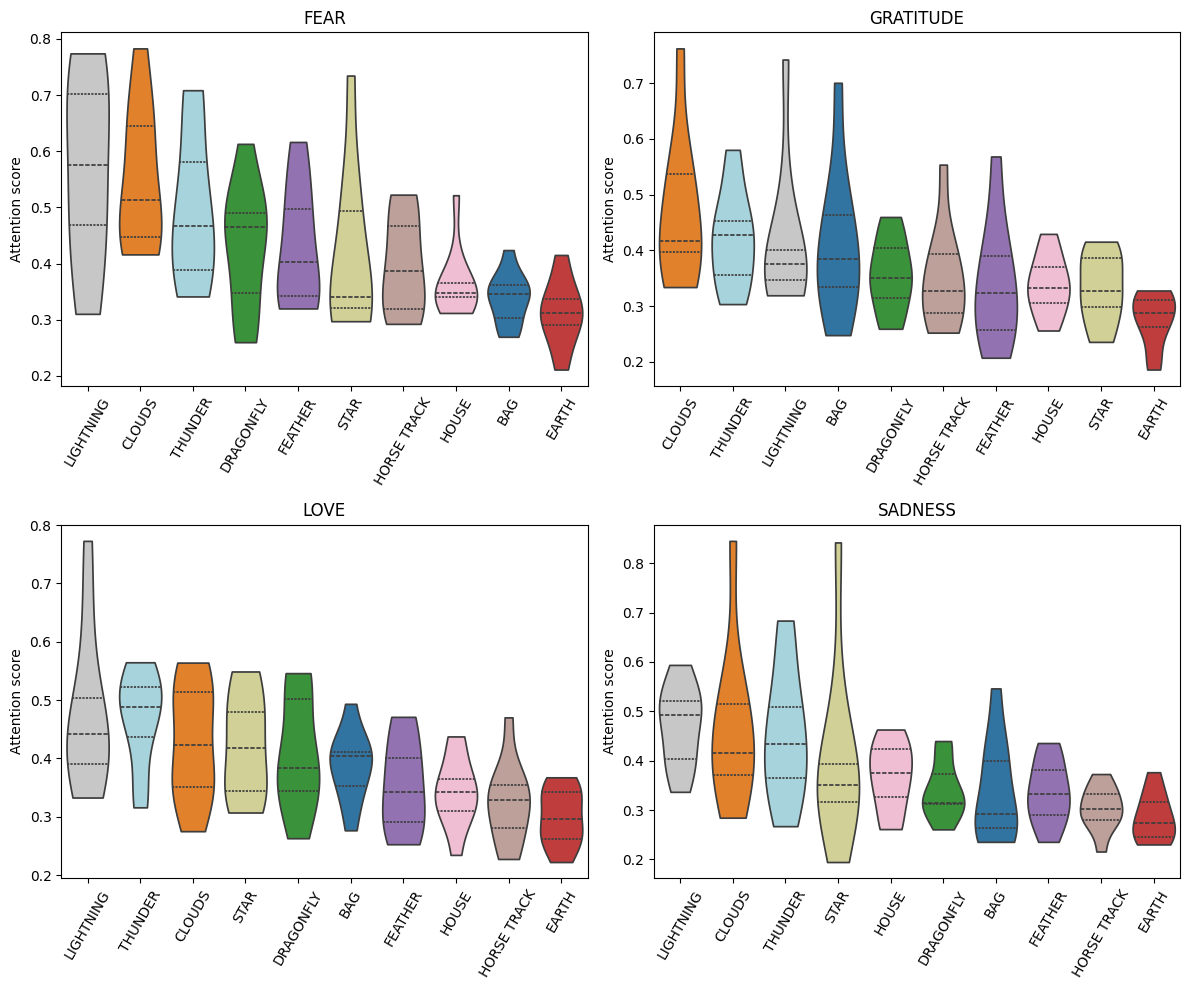

In [282]:
contexts = {
    "FEAR": [
        "A shadow moves behind the trees; breath turns shallow.",
        "Cold wind rattles the window as footsteps approach.",
        "Eyes watch from the dark water below the boat.",
        "The cave narrows; the light behind fades away.",
        "An animal scream splits the night and then silence.",
        "A sudden howl echoes across the empty field.",
        "The lantern flickers as something brushes past.",
        "Footsteps stop just outside the locked door.",
        "A cold hand grips the back of my neck.",
        "The silence grows heavier with every heartbeat."
    ],
    "LOVE": [
        "Their hands met by the river at dusk.",
        "Breath synced with a heartbeat under warm light.",
        "A letter folded in a pocket carries a smile.",
        "Two paths converged beside the old willow.",
        "A quiet morning coffee became a promise.",
        "Eyes meet and laughter fills the room.",
        "A gentle touch lingers after goodbye.",
        "Shared secrets whispered beneath the stars.",
        "A song played softly in the kitchen.",
        "The warmth of an embrace on a cold night."
    ],
    "SADNESS": [
        "Rain kept the chair by the window empty.",
        "Echoes lingered after the song stopped.",
        "Footprints on the shore washed away too fast.",
        "The room remembered the laughter better than we did.",
        "A cracked cup waiting on the shelf.",
        "A faded photograph tucked in a drawer.",
        "The last light in the hallway flickers out.",
        "A suitcase packed but never opened.",
        "The scent of perfume long after she's gone.",
        "A single tear stains the letter unread."
    ],
    "GRATITUDE": [
        "Warm bread shared at sunrise after a long night.",
        "A stranger’s umbrella in sudden rain.",
        "Hands washed clean in the cold river.",
        "A soft blanket after the journey home.",
        "The last apple given without asking.",
        "A smile offered when hope was thin.",
        "A friend’s call just when it was needed.",
        "A gentle word that eased the pain.",
        "A door held open on a heavy day.",
        "A memory cherished more with each year."
    ]
}

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def violins_by_theme_attention(
    space, contexts, tau=0.05, top_k=10, color_dict=None,
    score_method="sum_topN", topN=5
):
    import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
    rows = []

    # 1) collect scores for ALL symbols (avoid truncation bias)
    for theme, sentences in contexts.items():
        for sent in sentences:
            results = space.recommend_symbols_with_softmax_attention(
                sent, topk=len(space.symbols), tau=tau, n_best=5,
                score_method=score_method, topN=topN
            )
            for r in results:
                rows.append({"theme": theme, "sentence": sent,
                             "symbol": r["symbol"], "score": r["score"]})
    df = pd.DataFrame(rows)

    # 2) per-theme top_k and per-theme order
    orders = {}
    keep = []
    for theme, dft in df.groupby("theme"):
        order = (dft.groupby("symbol")["score"]
                   .mean().sort_values(ascending=False)
                   .head(top_k).index.tolist())
        orders[theme] = order
        keep.append(dft[dft["symbol"].isin(order)])
    df_keep = pd.concat(keep, ignore_index=True)

    # 3) plot with subplots; each axis has its own order
    themes = list(orders.keys())
    ncols = 2
    nrows = int(np.ceil(len(themes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
    axes = axes.flatten()

    for ax, theme in zip(axes, themes):
        dft = df_keep[df_keep["theme"] == theme]
        order = orders[theme]
        palette = None
        if color_dict:
            palette = [color_dict[s] for s in order]
        sns.violinplot(
            data=dft, x="symbol", y="score",
            order=order, inner="quartile", cut=0, density_norm="width",
            palette=palette, ax=ax
        )
        ax.set_title(theme)
        ax.set_xlabel("")
        ax.set_ylabel("Attention score")
        ax.tick_params(axis="x", rotation=60)

    # hide any extra axes
    for ax in axes[len(themes):]:
        ax.axis("off")

    plt.tight_layout()
    return df_keep, fig


space = SymbolSpace(    symbols_to_descriptors,
    TextEmbedder(
        backend="qwen3",
        pooling="eos",
    ),
    contextual_embeddings=False
)
# Example usage:
try:
    cdict = space.get_symbol_color_dict()
except AttributeError:
    cdict = None

df_attn, fig = violins_by_theme_attention(
    space, contexts, tau=0.05, top_k=10, color_dict=cdict,
    score_method="sum_topN", topN=2
)


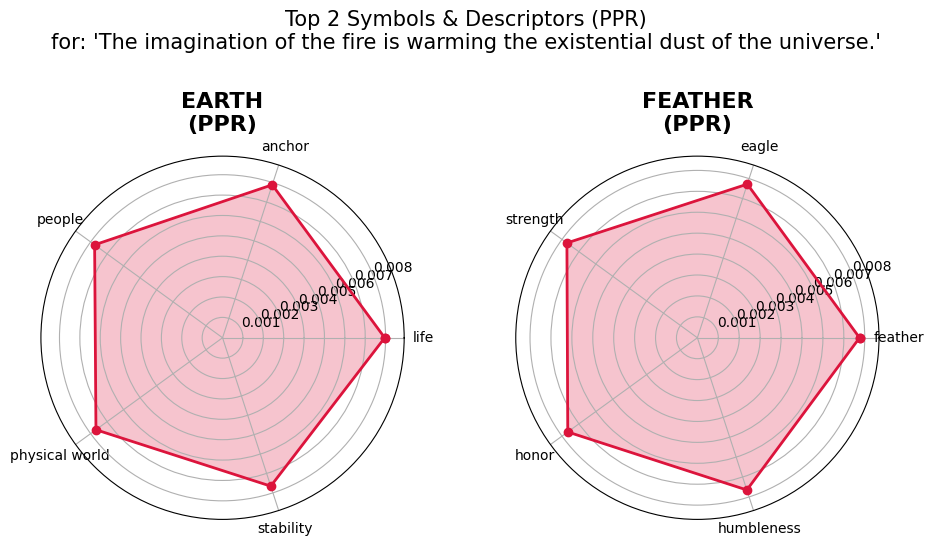

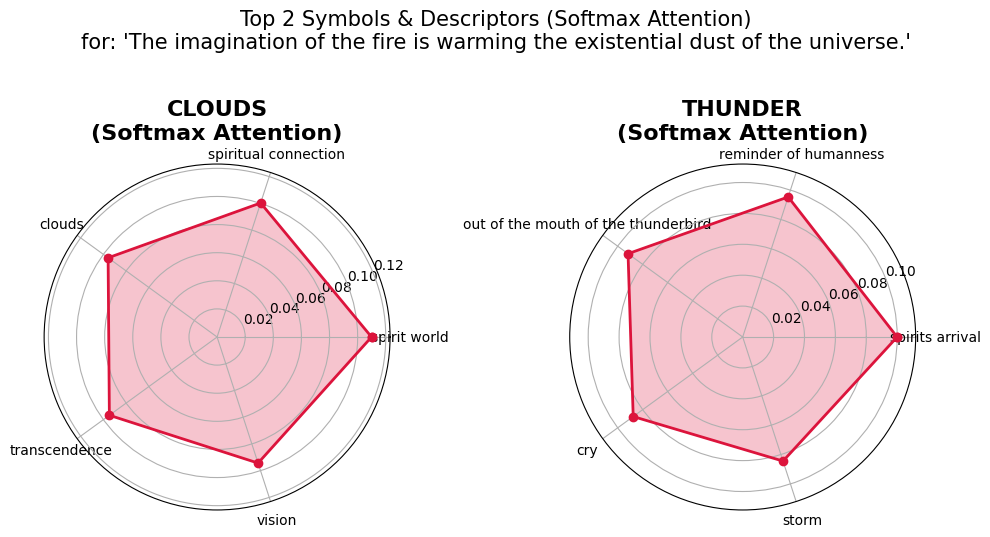

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def plot_symbol_descriptor_radar(results, method_label="PPR", sentence=None):
    """
    Plot radar charts for top symbols and their descriptors.
    results: list of dicts from recommend_symbols_with_* functions
    method_label: string label for the method (e.g., "PPR", "Softmax")
    sentence: (optional) the input context for the plot title
    """
    n_syms = len(results)
    n_best = len(results[0]['best_descriptors']) if results else 0
    angles = np.linspace(0, 2 * np.pi, n_best, endpoint=False).tolist()
    angles += angles[:1]  # close the radar chart

    fig, axs = plt.subplots(1, n_syms, subplot_kw=dict(polar=True), figsize=(5 * n_syms, 5))
    if n_syms == 1:
        axs = [axs]
    
    for i, res in enumerate(results):
        descs = res['best_descriptors']
        scores = res['descriptor_scores']
        # Close the plot by repeating the first value
        values = scores + [scores[0]]

        ax = axs[i]
        ax.plot(angles, values, color="crimson", linewidth=2, linestyle='-', marker='o')
        ax.fill(angles, values, color="crimson", alpha=0.25)
        ax.set_thetagrids(np.degrees(angles[:-1]), descs)
        ax.set_ylim(bottom=0, top=max(values) * 1.12)
        ax.set_title(f"{res['symbol']}\n({method_label})", fontsize=16, weight='bold')
        ax.grid(True)

    suptitle = f"Top {n_syms} Symbols & Descriptors ({method_label})"
    if sentence is not None:
        suptitle += f"\nfor: '{sentence}'"
    plt.suptitle(suptitle, fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()


# ---- Example usage ----

# For PPR
plot_symbol_descriptor_radar(ppr_results, method_label="PPR", sentence=sentence)

# For Softmax
plot_symbol_descriptor_radar(softmax_results, method_label="Softmax Attention", sentence=sentence)


[Embedder] Loading Qwen model: Qwen/Qwen3-Embedding-0.6B
[Embedder] Qwen loaded (1024-d), pooling=eos.

Context: 'I discovered my true identity'
STAR: Δscore=-0.013406 | ['stardust in our bones', 'soul', 'star']
EARTH: Δscore=-0.014954 | ['anchor', 'life', 'stability']
FEATHER: Δscore=-0.014980 | ['strength', 'honor', 'feather']


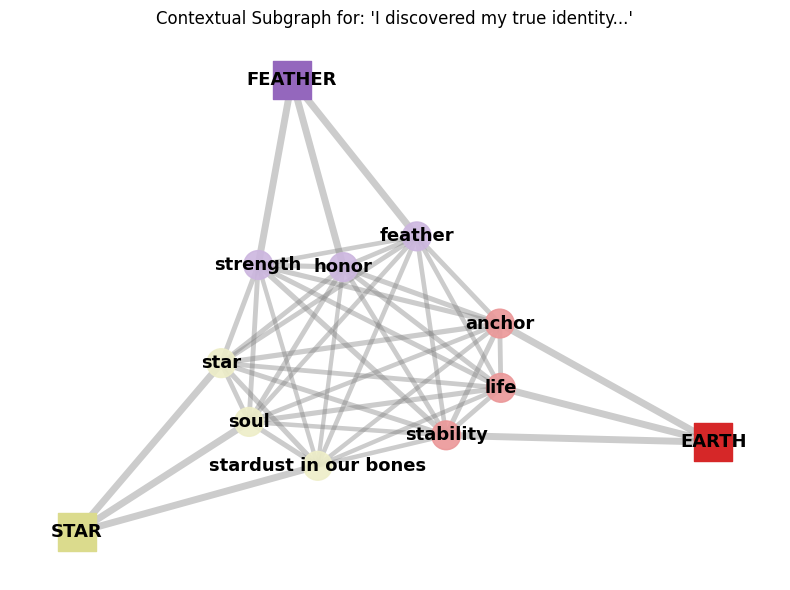


Context: 'Below the threshold, many faces embrace'
THUNDER: Δscore=-0.013960 | ['spirits arrival', 'reminder of humanness', 'out of the mouth of the thunderbird']
EARTH: Δscore=-0.014771 | ['grounding', 'anchor', 'people']
LIGHTNING: Δscore=-0.014856 | ['goes out of the eyes of the thunderbird', 'storm', 'fear']


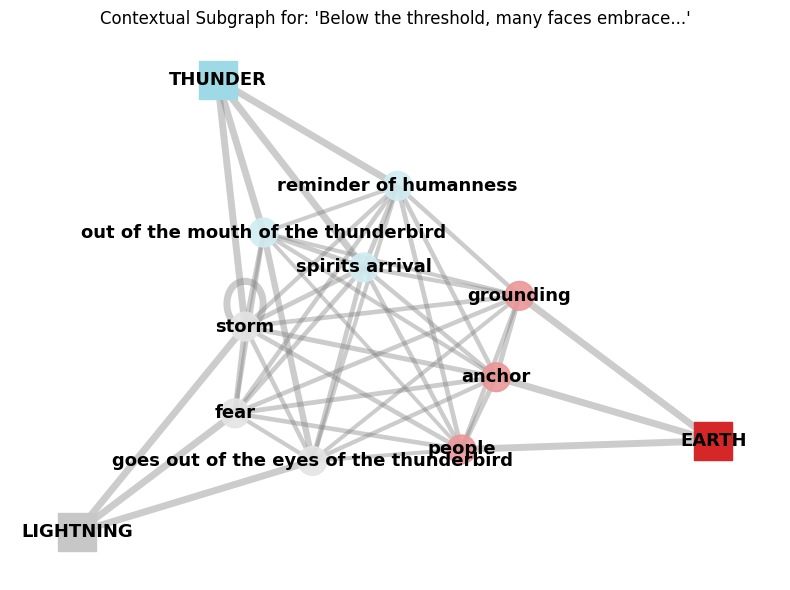


Context: 'My cereals are sleeping in the cradle'
LIGHTNING: Δscore=-0.013917 | ['goes out of the eyes of the thunderbird', 'grandfather', 'storm']
THUNDER: Δscore=-0.014795 | ['out of the mouth of the thunderbird', 'spirits arrival', 'reminder of humanness']
EARTH: Δscore=-0.014806 | ['grounding', 'anchor', 'life']


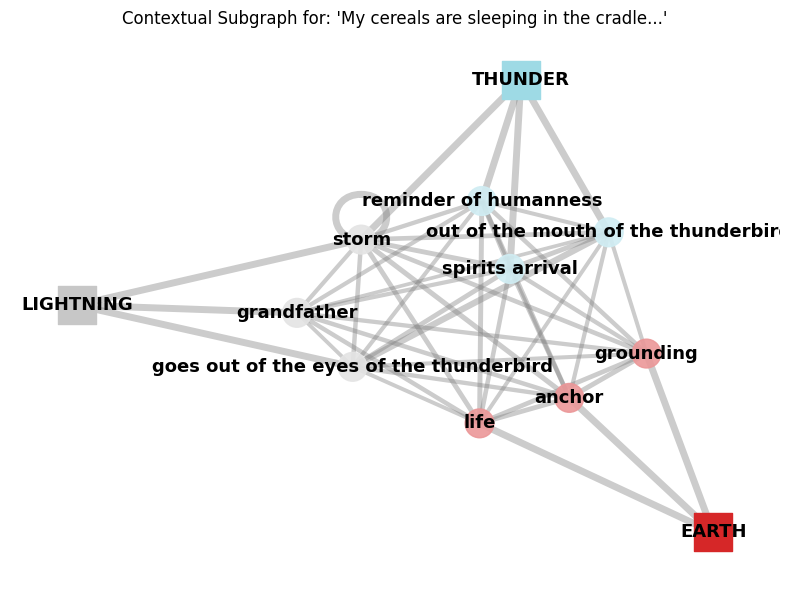


Context: 'Livers, storms, and the shivers of the coal'
THUNDER: Δscore=-0.013658 | ['storm', 'spirits arrival', 'thunder']
LIGHTNING: Δscore=-0.014311 | ['storm', 'west', 'danger']
STAR: Δscore=-0.014901 | ['stardust in our bones', 'north', 'soul']


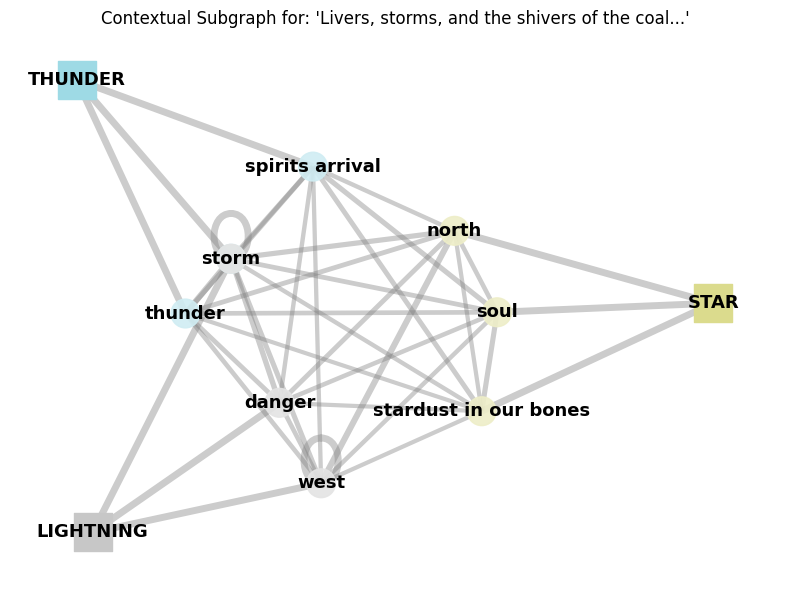


Context: 'one banana in my ear, one in my hand'
EARTH: Δscore=-0.014325 | ['balance', 'anchor', 'grounding']
BAG: Δscore=-0.014469 | ['carrying', 'bag', 'peace pipe']
STAR: Δscore=-0.014657 | ['balance', 'source', 'north']


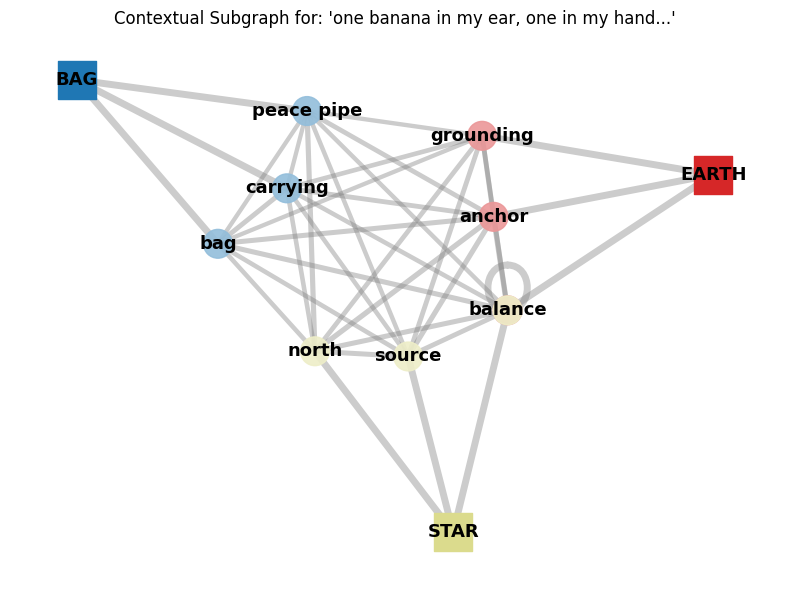

In [297]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def lighten_color(color, amount=0.5):
    """Blend a color with white to lighten it."""
    white = np.array([1, 1, 1])
    color = np.array(color[:3])
    return tuple((1-amount)*color + amount*white)

def plot_contextual_subgraph_colored(
    space,
    context_sentence,
    topk_symbols=3,
    topk_desc=3,
    method="ppr",
    alpha=0.85,
    tau=0.1,
    normalize=False,
    global_color_map=None  # pass global palette here
):
    """
    Plot contextual subgraph for a given sentence using a fixed global color palette.

    normalize=True will subtract baseline PPR with uniform personalization
    to remove centrality prior.
    """

    if method == "ppr":
        # 1. Contextual PPR
        results_raw = space.recommend_symbols_with_ppr_descriptors(
            context_sentence, topk=None, alpha=alpha, tau=tau, n_best=topk_desc
        )

        # 2. Baseline PPR with uniform personalization
        uniform_weights = {f"S:{s}": 1.0 / len(space.symbols) for s in space.symbols}
        baseline_scores = nx.pagerank(
            space.G, alpha=alpha, personalization=uniform_weights, weight="weight"
        )

        # 3. Remove centrality prior if normalize=True
        norm_results = []
        for r in results_raw:
            sym_node = f"S:{r['symbol']}"
            if normalize:
                norm_score = r['score'] - baseline_scores.get(sym_node, 0.0)
            else:
                norm_score = r['score']

            norm_results.append({
                "symbol": r['symbol'],
                "score": norm_score,
                "best_descriptors": r['best_descriptors']
            })

        # 4. Sort and take top k
        results = sorted(norm_results, key=lambda x: x['score'], reverse=True)[:topk_symbols]

        for r in results:
            print(f"{r['symbol']}: Δscore={r['score']:.6f} | {r['best_descriptors']}")

    elif method == "softmax":
        results = space.recommend_symbols_with_softmax_attention(
            context_sentence, topk=topk_symbols, tau=tau, n_best=topk_desc
        )

    # --- Build subgraph ---
    symbols = [r['symbol'] for r in results]
    symbol_to_desc = {r['symbol']: r['best_descriptors'] for r in results}
    descriptors = [d for r in results for d in r['best_descriptors']]

    # Use global color map if provided, else fall back to local mapping
    if global_color_map is None:
        cmap = plt.cm.tab20
        color_map = {s: cmap(i / max(1, len(space.symbols)-1)) for i, s in enumerate(space.symbols)}
    else:
        color_map = global_color_map

    nodes = [f"S:{s}" for s in symbols] + [f"D:{d}" for d in descriptors]
    subG = space.G.subgraph(nodes).copy()
    pos = nx.spring_layout(subG, seed=42)

    plt.figure(figsize=(8, 6))

    # Symbol nodes
    for s in symbols:
        nx.draw_networkx_nodes(subG, pos,
                               nodelist=[f"S:{s}"],
                               node_color=[color_map[s]],
                               node_shape="s", node_size=750)

    # Descriptor nodes (lightened color of symbol)
    for s in symbols:
        desc_nodes = [f"D:{d}" for d in symbol_to_desc[s]]
        nx.draw_networkx_nodes(subG, pos,
                               nodelist=desc_nodes,
                               node_color=[lighten_color(color_map[s], amount=0.52)]*len(desc_nodes),
                               node_shape="o", node_size=430, alpha=0.9)

    scale_factor = 5
    edge_widths = [subG[u][v].get("weight", 1.0) * scale_factor for u, v in subG.edges()]
    nx.draw_networkx_edges(subG, pos, width=edge_widths, alpha=0.4, edge_color="gray")


    labels = {n: n[2:] for n in subG}
    nx.draw_networkx_labels(subG, pos, labels, font_size=13, font_weight="bold")

    plt.title(f"Contextual Subgraph for: '{context_sentence[:60]}...'")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# --- 2. Recreate the SymbolSpace object ---
# Make sure SymbolSpace and TextEmbedder are imported from your module
space = SymbolSpace(symbols_to_descriptors, TextEmbedder(backend='qwen3', pooling='eos'), contextual_embeddings=False)
# Example: define the global palette once
cmap = plt.cm.tab20
global_color_map = {s: cmap(i / max(1, len(space.symbols)-1)) for i, s in enumerate(space.symbols)}


# Example surrealist sentence in the style of Einstein

emotion_sentences = [
    'I discovered my true identity',
    'Below the threshold, many faces embrace',
    'My cereals are sleeping in the cradle',
    'Livers, storms, and the shivers of the coal',
    'one banana in my ear, one in my hand',
]


for sent in emotion_sentences:
    print(f"\nContext: '{sent}'")
    plot_contextual_subgraph_colored(
        space,
        context_sentence=sent,
        topk_symbols=3,
        topk_desc=3,
        method="ppr",
        alpha=0.85,
        tau=0.01,
        normalize=True,
        global_color_map=global_color_map
    )

In [175]:
def rank_deltas(space, context_sentence, alpha=0.85, tau=0.01):
    # Baseline PPR
    uniform_weights = {f"S:{s}": 1.0 / len(space.symbols) for s in space.symbols}
    baseline_scores = nx.pagerank(space.G, alpha=alpha, personalization=uniform_weights, weight="weight")
    baseline_scores = {s[2:]: score for s, score in baseline_scores.items() if s.startswith("S:")}

    # Contextual PPR
    ctx_results = space.recommend_symbols_with_ppr_descriptors(context_sentence, topk=None, alpha=alpha, tau=tau, n_best=3)
    ctx_scores = {r["symbol"]: r["score"] for r in ctx_results}

    # Compare ranks
    sorted_base = sorted(baseline_scores, key=baseline_scores.get, reverse=True)
    sorted_ctx  = sorted(ctx_scores, key=ctx_scores.get, reverse=True)

    rank_delta = {}
    for sym in space.symbols:
        base_rank = sorted_base.index(sym) + 1
        ctx_rank  = sorted_ctx.index(sym) + 1
        rank_delta[sym] = base_rank - ctx_rank  # positive = moved up in context

    return sorted(rank_delta.items(), key=lambda x: x[1], reverse=True)

deltas = rank_deltas(space, "Mystery and love intertwine like shadows in the night", alpha=0.85, tau=0.01)
for sym, change in deltas[:10]:
    print(f"{sym}: rank improved by {change}")


LIGHTNING: rank improved by 4
DRAGONFLY: rank improved by 1
CLOUDS: rank improved by 0
FEATHER: rank improved by 0
HOUSE: rank improved by 0
THUNDER: rank improved by 0
EARTH: rank improved by -1
HORSE TRACK: rank improved by -1
STAR: rank improved by -1
BAG: rank improved by -2


In [176]:
baseline_scores = nx.pagerank(space.G, alpha=0.85, personalization=None, weight="weight")
symbols_only = {n: score for n, score in baseline_scores.items() if n.startswith("S:")}
sorted_symbols = sorted(symbols_only.items(), key=lambda x: x[1], reverse=True)

for node, score in sorted_symbols[:10]:
    print(node, score)

from networkx.algorithms import bipartite

# Separate sets
symbols = [n for n in space.G.nodes if n.startswith("S:")]
descriptors = [n for n in space.G.nodes if n.startswith("D:")]

# Project bipartite graph onto symbols
G_symbols = bipartite.weighted_projected_graph(space.G, symbols)

# Now run PageRank only on symbols
baseline_scores_sym = nx.pagerank(G_symbols, alpha=0.85, weight="weight")
sorted_baseline_sym = sorted(baseline_scores_sym.items(), key=lambda x: x[1], reverse=True)

for node, score in sorted_baseline_sym[:10]:
    print(node, score)



S:EARTH 0.0023729925535393055
S:BAG 0.0021695950562490495
S:FEATHER 0.0021648074294153335
S:STAR 0.002026316879517546
S:LIGHTNING 0.0019608121348625358
S:DRAGONFLY 0.0019590096445153147
S:HORSE TRACK 0.0019578769511985634
S:HOUSE 0.0019560177173203
S:THUNDER 0.0018887554309749473
S:CLOUDS 0.0018190276251845653
S:EARTH 0.06273314083890989
S:BAG 0.052999623596883205
S:FEATHER 0.05295397999324955
S:STAR 0.046510430400110436
S:LIGHTNING 0.04335749245443974
S:HORSE TRACK 0.0433116195561887
S:DRAGONFLY 0.04322042887792231
S:HOUSE 0.04322042887792231
S:THUNDER 0.04006728750075505
S:CLOUDS 0.03682271999773858


weight_samples [[0.59063049 0.40936951]
 [0.92303346 0.07696654]
 [0.20923167 0.79076833]
 [0.05073403 0.94926597]
 [0.34939405 0.65060595]
 [0.9687765  0.0312235 ]
 [0.52638066 0.47361934]
 [0.81215785 0.18784215]
 [0.64001171 0.35998829]
 [0.06554348 0.93445652]
 [0.02949264 0.97050736]
 [0.84426154 0.15573846]
 [0.81482804 0.18517196]
 [0.53003359 0.46996641]
 [0.0260306  0.9739694 ]
 [0.66431701 0.33568299]
 [0.93262618 0.06737382]
 [0.27675655 0.72324345]
 [0.49678881 0.50321119]
 [0.973774   0.026226  ]
 [0.01467513 0.98532487]
 [0.12694386 0.87305614]
 [0.94839034 0.05160966]
 [0.36439022 0.63560978]
 [0.30620262 0.69379738]
 [0.39061534 0.60938466]
 [0.06372437 0.93627563]
 [0.45503695 0.54496305]
 [0.1519943  0.8480057 ]
 [0.66516167 0.33483833]
 [0.58617974 0.41382026]
 [0.1254603  0.8745397 ]
 [0.11380268 0.88619732]
 [0.55791523 0.44208477]
 [0.45660153 0.54339847]
 [0.97225473 0.02774527]
 [0.21241318 0.78758682]
 [0.32576259 0.67423741]
 [0.42527387 0.57472613]
 [0.297873

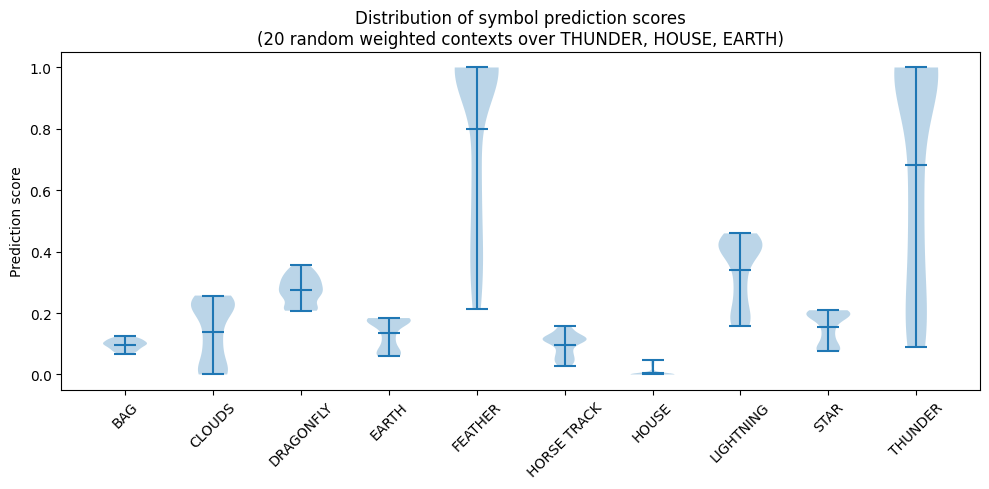

In [177]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 20 random variations of weights for THUNDER, HOUSE, EARTH (all positive, sum to 1)
n_variations = 100
symbols = ["THUNDER", 'FEATHER']
weight_samples = np.random.dirichlet([1, 1], size=n_variations)
print('weight_samples', weight_samples)

# For each variation, get the prediction scores for all symbols in the space
all_scores = []
for w in weight_samples:
    weights_ctx = dict(zip(symbols, w))
    print(f"\nWeights: {weights_ctx}")
    preds = space.propose(weights=weights_ctx, topk=len(space.symbols))
    # Make a dict from the prediction results
    score_dict = {s: score for s, score, _, _ in preds}
    # Extract in the same order as space.symbols
    scores = [score_dict[s] for s in space.symbols]
    all_scores.append(scores)
all_scores = np.array(all_scores)  # shape: [n_variations, n_symbols]

# Plot violin plots for each symbol in the space (order matches space.symbols)
plt.figure(figsize=(10, 5))
plt.violinplot(all_scores, showmeans=True)
plt.xticks(np.arange(1, len(space.symbols)+1), list(space.symbols), rotation=45)
plt.ylabel("Prediction score")
plt.title("Distribution of symbol prediction scores\n(20 random weighted contexts over THUNDER, HOUSE, EARTH)")
plt.tight_layout()
plt.show()


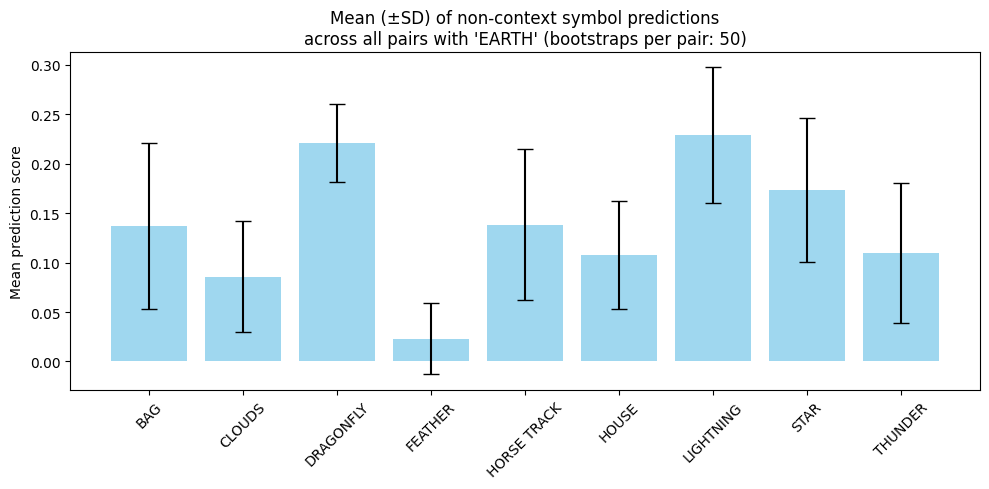

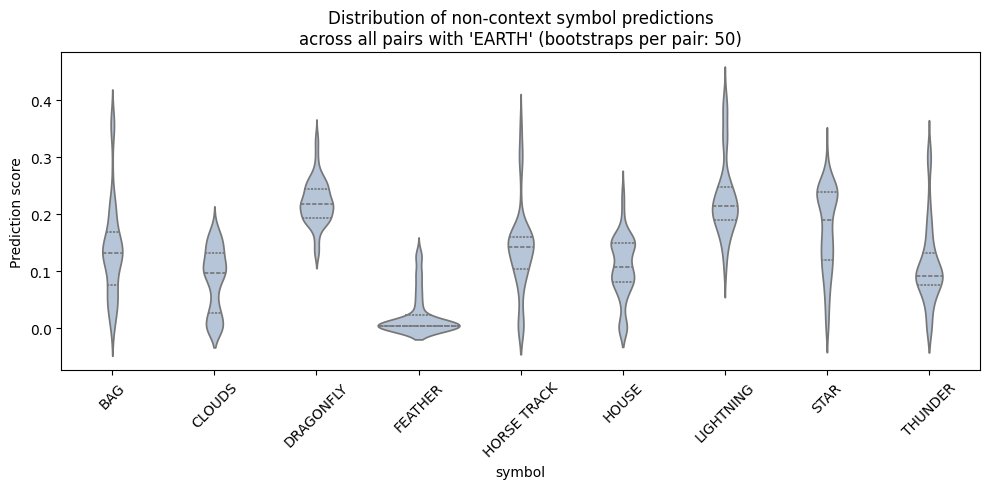

In [262]:
import numpy as np
import matplotlib.pyplot as plt

context_root = "EARTH"
all_syms = list(space.symbols)
other_syms = [s for s in all_syms if s != context_root]
n_iter = 50

# Store scores: {symbol: [all scores across all pairs/bootstraps]}
symbol_score_dict = {s: [] for s in all_syms if s != context_root}

for ctx_partner in other_syms:
    ctx_pair = [context_root, ctx_partner]
    weights_samples = np.random.dirichlet([1, 1], size=n_iter)
    for w in weights_samples:
        weights_ctx = dict(zip(ctx_pair, w))
        preds = space.propose(weights=weights_ctx, topk=len(all_syms))
        score_dict = {s: score for s, score, _, _ in preds}
        # Collect scores for all symbols NOT in the current context
        for s in all_syms:
            if s not in ctx_pair:
                symbol_score_dict[s].append(score_dict[s])

# To visualize: reorder by mean if you want, or alphabetical
symbols_nonctx = list(symbol_score_dict.keys())
means = [np.mean(symbol_score_dict[s]) for s in symbols_nonctx]
stds = [np.std(symbol_score_dict[s]) for s in symbols_nonctx]

# --- Bar plot (mean, with error bars) ---
plt.figure(figsize=(10, 5))
plt.bar(np.arange(len(symbols_nonctx)), means, yerr=stds, alpha=0.8, capsize=6, color='skyblue')
plt.xticks(np.arange(len(symbols_nonctx)), symbols_nonctx, rotation=45)
plt.ylabel("Mean prediction score")
plt.title(f"Mean (±SD) of non-context symbol predictions\nacross all pairs with '{context_root}' (bootstraps per pair: {n_iter})")
plt.tight_layout()
plt.show()

# --- Or violin/boxplot for full distribution ---
import seaborn as sns
import pandas as pd
records = []
for s in symbols_nonctx:
    for val in symbol_score_dict[s]:
        records.append({'symbol': s, 'score': val})
df = pd.DataFrame(records)
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="symbol", y="score", inner="quartile", color='lightsteelblue')
plt.xticks(rotation=45)
plt.ylabel("Prediction score")
plt.title(f"Distribution of non-context symbol predictions\nacross all pairs with '{context_root}' (bootstraps per pair: {n_iter})")
plt.tight_layout()
plt.show()


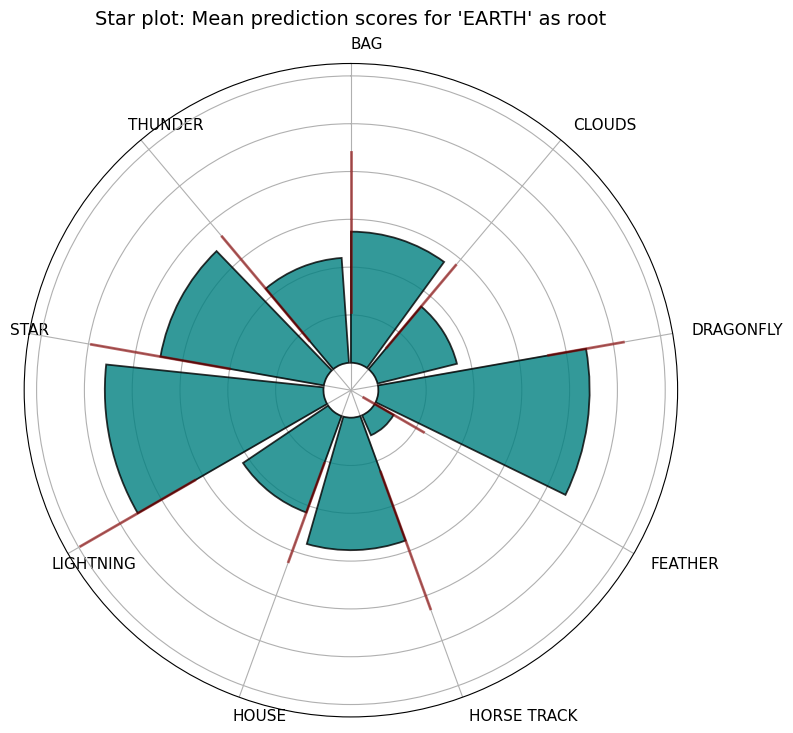

In [263]:
import numpy as np
import matplotlib.pyplot as plt

# symbols_nonctx, means, stds as computed above
N = len(symbols_nonctx)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# Repeat the first value to close the circle
means_circular = means + [means[0]]
stds_circular = stds + [stds[0]]
angles_circular = angles + [angles[0]]
labels_circular = symbols_nonctx + [symbols_nonctx[0]]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Plot the mean bar
bars = ax.bar(angles, means, width=2*np.pi/N*0.9, align='edge', alpha=0.8, color="teal", edgecolor="black", linewidth=1.3, zorder=2)

# Optionally: add error bars
for i, (angle, m, s) in enumerate(zip(angles, means, stds)):
    ax.plot([angle, angle], [m-s, m+s], color='darkred', linewidth=2, alpha=0.6, zorder=3)

# Set the ticks and labels
ax.set_xticks(angles)
ax.set_xticklabels(symbols_nonctx, fontsize=11, ha='left', va='center')
ax.set_yticklabels([])  # Hide radial ticks

# Make zero at the top
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_title(f"Star plot: Mean prediction scores for '{context_root}' as root", va='bottom', fontsize=14)
plt.tight_layout()
plt.show()


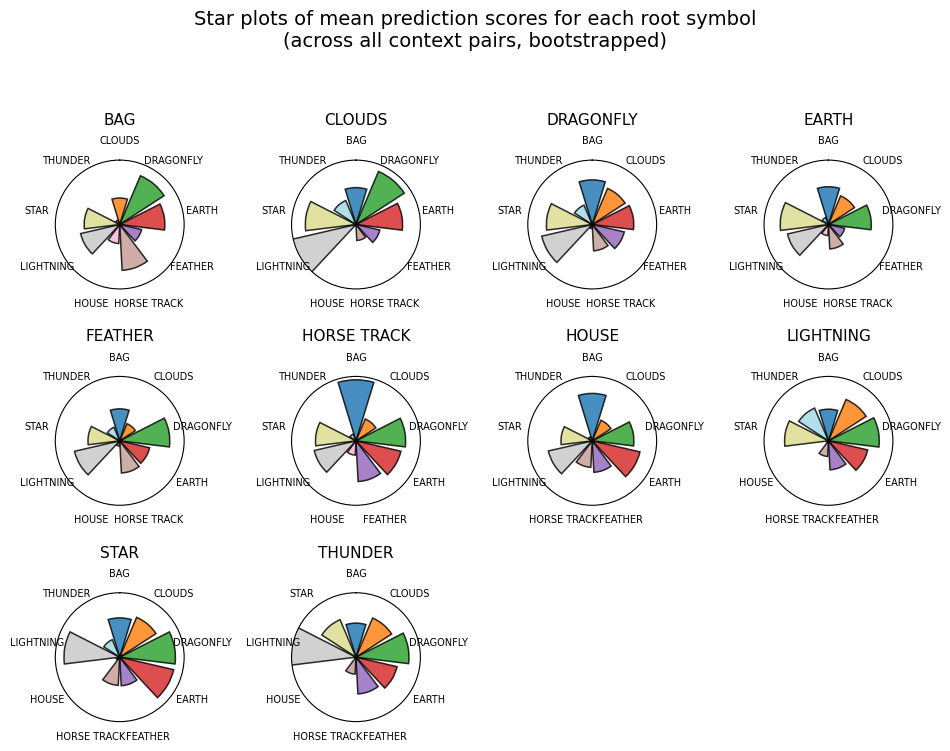

In [32]:
import numpy as np
import matplotlib.pyplot as plt


# --- Get your symbols (adjust this if using a custom symbol order) ---
all_syms = list(space.symbols)
N = len(all_syms)
n_iter = 10

# --- Get colors: assign each symbol a color from tab20 ---
colors = plt.cm.tab20(np.linspace(0, 1, N))
symbol_colors = {s: colors[i] for i, s in enumerate(all_syms)}

# --- Main bootstrapping loop ---
all_results = {}

for context_root in all_syms:
    other_syms = [s for s in all_syms if s != context_root]
    symbol_score_dict = {s: [] for s in all_syms if s != context_root}

    for ctx_partner in other_syms:
        ctx_pair = [context_root, ctx_partner]
        weights_samples = np.random.dirichlet([1, 1], size=n_iter)
        for w in weights_samples:
            weights_ctx = dict(zip(ctx_pair, w))
            preds = space.propose(weights=weights_ctx, topk=len(all_syms))
            score_dict = {s: score for s, score, _, _ in preds}
            for s in all_syms:
                if s not in ctx_pair:
                    symbol_score_dict[s].append(score_dict[s])
    all_results[context_root] = {s: np.mean(vals) for s, vals in symbol_score_dict.items()}

import math

ncols = int(np.ceil(np.sqrt(N)))
nrows = int(np.ceil(N / ncols))
angles = np.linspace(0, 2 * np.pi, N-1, endpoint=False)  # N-1 because we exclude the root each time

fig, axs = plt.subplots(nrows, ncols, subplot_kw=dict(polar=True), figsize=(2.4*ncols, 2.4*nrows))

for i, root in enumerate(all_syms):
    row, col = divmod(i, ncols)
    ax = axs[row, col] if nrows > 1 else axs[col] if ncols > 1 else axs
    # Get means for all non-root symbols
    means = [all_results[root][s] for s in all_syms if s != root]
    syms = [s for s in all_syms if s != root]
    # Angles
    means_circ = means + [means[0]]
    angles_circ = list(angles) + [angles[0]]
    syms_circ = syms + [syms[0]]
    # Colors for bars
    bar_colors = [symbol_colors[s] for s in syms]
    # Draw bars centered on each angle
    bars = ax.bar(
        angles, means, 
        width=2*np.pi/(N-1)*0.85, 
        align='center',
        alpha=0.82, color=bar_colors, 
        edgecolor="black", linewidth=1.1
    )
    # Setup axes
    ax.set_xticks(angles)
    ax.set_xticklabels(syms, fontsize=7)
    ax.set_yticklabels([])
    ax.set_title(root, va='bottom', fontsize=11)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(False)
    # Reduce radial limit if your scores are in [0,1]
    ax.set_ylim(0, 0.35)

# Hide unused subplots if any
for idx in range(N, nrows*ncols):
    fig.delaxes(axs.flatten()[idx])

fig.suptitle("Star plots of mean prediction scores for each root symbol\n(across all context pairs, bootstrapped)", fontsize=14, y=1.04)
plt.tight_layout()
plt.show()


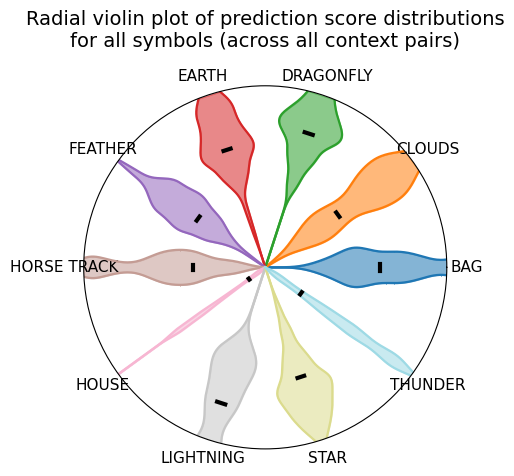

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Aggregate all scores for each symbol (excluding as context) ---
all_syms = list(space.symbols)
N = len(all_syms)
symbol_scores = {s: [] for s in all_syms}

# Aggregate scores for each symbol as "non-context" in all pairs
for context_root in all_syms:
    other_syms = [s for s in all_syms if s != context_root]
    for ctx_partner in other_syms:
        ctx_pair = [context_root, ctx_partner]
        weights_samples = np.random.dirichlet([1, 1], size=10)  # n_iter = 10
        for w in weights_samples:
            weights_ctx = dict(zip(ctx_pair, w))
            preds = space.propose(weights=weights_ctx, topk=len(all_syms))
            score_dict = {s: score for s, score, _, _ in preds}
            for s in all_syms:
                if s not in ctx_pair:
                    symbol_scores[s].append(score_dict[s])

# --- Prepare polar violin plot ---
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
symbol_order = all_syms
colors = plt.cm.tab20(np.linspace(0, 1, N))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, polar=True)

for i, s in enumerate(symbol_order):
    data = symbol_scores[s]
    angle = angles[i]

    # Make a violin plot "by hand" (mirror along radius)
    # Compute histogram/density
    from scipy.stats import gaussian_kde

    if len(data) > 1:
        kde = gaussian_kde(data)
        r_grid = np.linspace(0, 0.35, 150)  # Set max radius as needed
        dens = kde(r_grid)
        dens = dens / dens.max() * 0.22   # Scale density for visual appearance

        # Draw two sides: positive and negative theta offset for thickness
        ax.plot(angle + dens, r_grid, color=colors[i], lw=1.6)
        ax.plot(angle - dens, r_grid, color=colors[i], lw=1.6)
        # Fill between for violin
        ax.fill_betweenx(r_grid, angle - dens, angle + dens, color=colors[i], alpha=0.55)
        # Mark mean with a black line
        mean = np.mean(data)
        ax.plot([angle-0.03, angle+0.03], [mean, mean], color="black", lw=3, zorder=6)

# Set angular ticks and labels
ax.set_xticks(angles)
ax.set_xticklabels(symbol_order, fontsize=11)
ax.set_yticklabels([])
ax.set_ylim(0, 0.35)
ax.set_title("Radial violin plot of prediction score distributions\nfor all symbols (across all context pairs)", fontsize=14, pad=28)
ax.grid(False)
plt.tight_layout()
plt.show()


In [180]:
# pip install torch transformers

import torch
from transformers import AutoTokenizer, AutoModel

# --- Load Qwen3 embedding model ---
model_name = "Qwen/Qwen3-Embedding-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# --- Helper to embed with context ---
def embed_with_context(query: str, context: str = None, instruction: str = None):
    """
    Returns a context-dependent embedding for `query`.
    Context and instruction are baked into the input string for Qwen3.
    """
    parts = []
    if instruction:
        parts.append(instruction.strip())
    if context:
        parts.append(f"Context: {context.strip()}")
    parts.append(f"Query: {query.strip()}")
    formatted = "\n".join(parts)

    # Tokenize and forward pass
    toks = tokenizer([formatted], padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        out = model(**toks)

    # --- EOS pooling (last non-pad token hidden state) ---
    last_idx = toks["attention_mask"].sum(dim=1) - 1
    emb = out.last_hidden_state[0, last_idx[0]]
    emb = torch.nn.functional.normalize(emb, p=2, dim=0)  # L2 normalize
    return emb.cpu().numpy()

# --- Example ---
instruction = "Embed the query for retrieval in a Lakota archetype space."
context = "Here, concepts relate to Lakota symbolic meanings and archetypal relations."
query = "Dragonfly"

vec = embed_with_context(query, context=context, instruction=instruction)
print("Embedding shape:", vec.shape)
print("First 5 dims:", vec[:5])


Embedding shape: (1024,)
First 5 dims: [ 0.05511002  0.03616561 -0.00762886 -0.00793172  0.02505453]


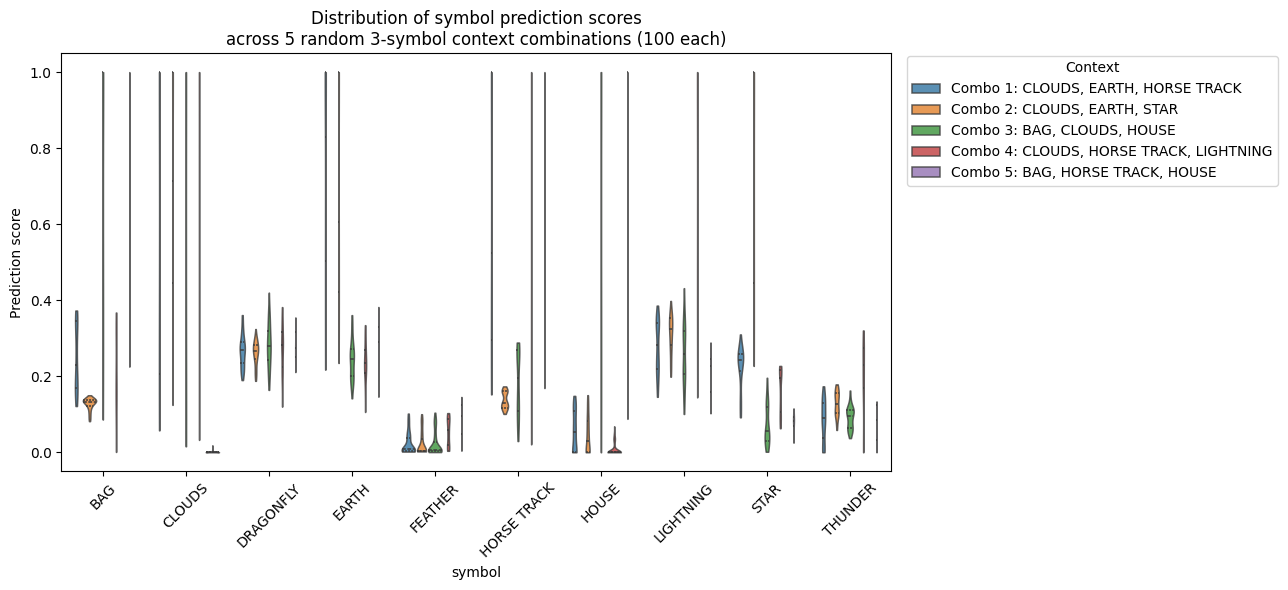

In [250]:
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

all_syms = list(space.symbols)
all_combos = list(combinations(all_syms, 3))
np.random.seed(42)
combo_indices = np.random.choice(len(all_combos), 5, replace=False)
combos = [list(all_combos[i]) for i in combo_indices]

n_iter = 100

records = []
for i, combo in enumerate(combos):
    weight_samples = np.random.dirichlet([1, 1, 1], size=n_iter)
    for w in weight_samples:
        weights_ctx = dict(zip(combo, w))
        preds = space.propose(weights=weights_ctx, topk=len(space.symbols))
        score_dict = {s: score for s, score, _, _ in preds}
        for s in all_syms:
            records.append({
                "symbol": s,
                "score": score_dict[s],
                "context_id": f"Combo {i+1}: {', '.join(combo)}",
                "selected": s in combo
            })

df = pd.DataFrame(records)

plt.figure(figsize=(13, 6))
sns.violinplot(
    data=df,
    x="symbol", y="score",
    hue="context_id",
    palette="tab10",
    cut=0,
    inner="quartile",
    linewidth=1.1,
    alpha=0.80
)

# Overlay: bold edge for selected context symbols (optional, see seaborn/matplotlib version for fine-tuning)
plt.ylabel("Prediction score")
plt.title("Distribution of symbol prediction scores\nacross 5 random 3-symbol context combinations (100 each)")
plt.xticks(rotation=45)
plt.legend(title="Context", bbox_to_anchor=(1.01, 1.01))
plt.tight_layout()
plt.show()


[Embedder] SentenceTransformer loaded (768-d).

--- SYMBOL PREDICTION: Sentence only ---

--- SYMBOL PREDICTION: Symbol weights only (Earth) ---

--- SYMBOL PREDICTION: Both sentence + symbol weights (Earth) ---


C:\Users\skite\AppData\Local\Temp\ipykernel_38896\2682763511.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


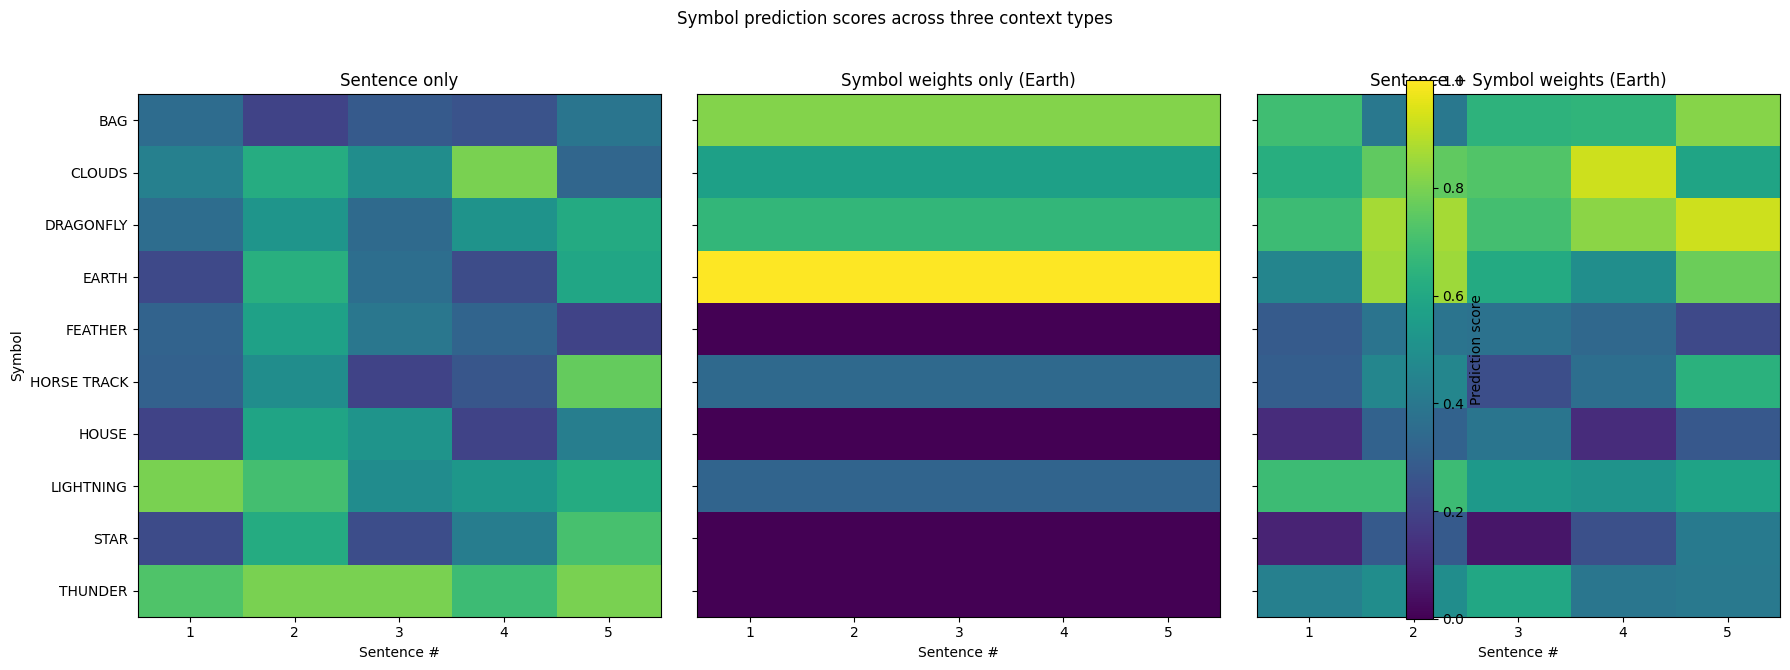

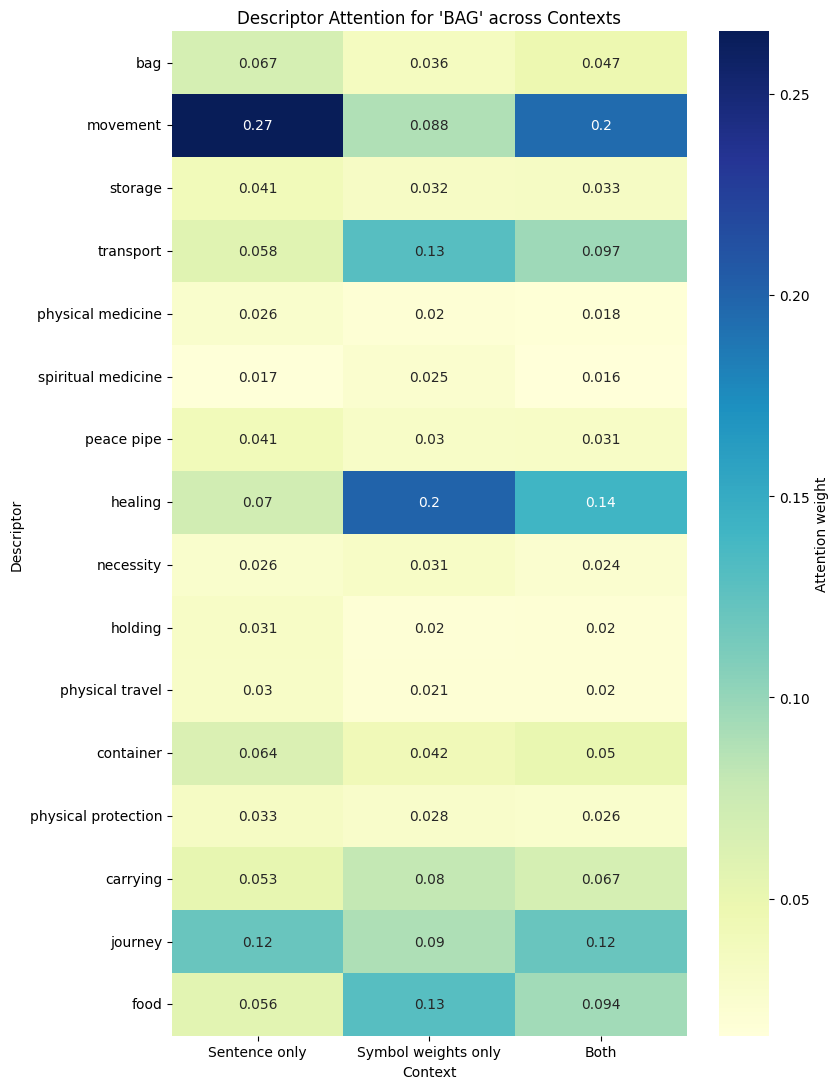

In [80]:
import seaborn as sns

def demo():
    import random

    # --- SYMBOL SET ---
    symbols_to_descriptors = {
    "BAG": [
        "bag", "movement", "storage", "transport", "physical medicine",
        "spiritual medicine", "peace pipe", "healing", "necessity", "holding",
        "physical travel", "container", "physical protection", "carrying", "journey", "food"
    ],
    "CLOUDS": [
        "clouds", "rain", "spiritual connection", "vision", "spiritual knowledge",
        "spirit world", "portal", "transcendence", "wisdom", "openness of the plane", "vastness"
    ],
    "DRAGONFLY": [
        "dragonfly", "resilience", "ancient connection", "ancestral", "confirmation",
        "message", "spiritual travel", "flight", "astral travel", "lightly", "blessing",
        "patience", "survival"
    ],
    "EARTH": [
        "earth", "people", "animals", "living beings", "plants", "roots", "mother",
        "geography", "mountain", "earthly", "mundane", "physical world", "harmony",
        "life", "sustainability", "balance", "grounding", "anchor", "stability"
    ],
    "FEATHER": [
        "feather", "achievement", "honor", "bravery", "merit", "counting coup",
        "courage", "knowledge", "eagle", "bird", "ceremony", "humbleness", "nobility",
        "virtue", "valor", "strength"
    ],
    "HORSE TRACK": [
        "horse track", "wealth", "travelling", "movement", "path", "motion",
        "riding", "hunting", "abundance", "dowry", "generosity", "west", "mobility"
    ],
    "HOUSE": [
        "house", "nurturing", "protection", "security", "home", "community",
        "matriarchy", "camp", "family", "care", "council", "grandmother", "safety"
    ],
    "LIGHTNING": [
        "lightning", "power", "thunderbird", "sacred clown", "spirituality", "storm",
        "spiritual connection", "electricity", "west", "fear", "grandfather", "danger",
        "goes out of the eyes of the thunderbird"
    ],
    "STAR": [
        "star", "medicine wheel", "four directions", "north", "ancestral connection",
        "stardust in our bones", "elemental", "extraterrestrial", "star people", "soul",
        "source", "light", "outer space", "balance"
    ],
    "THUNDER": [
        "thunder", "storm", "sound", "cry", "rain", "alert", "spirits arrival",
        "humility", "reminder of humanness", "fragility", "vulnerability", "out of the mouth of the thunderbird"
    ]
}

    symbols = list(symbols_to_descriptors)
    n_sym = len(symbols)
    space = SymbolSpace(symbols_to_descriptors, TextEmbedder(), contextual_embeddings=False)

    # 5 sentences, for demo
    random_sentences = [
        "A shadow moves silently, heart pounding in fear.",
        "Laughter fills the air, joy radiates from every face.",
        "Tears fall quietly, sadness lingers in the room.",
        "Eyes shine bright with hope for tomorrow.",
        "I was dancing in the midst of a underground party"
    ]
    # 1. Only sentence
    print("\n--- SYMBOL PREDICTION: Sentence only ---")
    symbol_preds_sent = np.zeros((len(random_sentences), n_sym))
    for i, sent in enumerate(random_sentences):
        preds = space.propose(sentence=sent, topk=n_sym)
        for j, (s, score, coh, ppr) in enumerate(preds):
            symbol_preds_sent[i, symbols.index(s)] = score

    # 2. Only symbol weights (simulate "Earth" context)
    # Assign a weight for each symbol (example: Earth highest, others decreasing)
    weights_earth = {symbol: weight for symbol, weight in zip(symbols, np.linspace(1.0, 0.1, n_sym))}
    four_weights = {'EARTH': 1.0, 'BAG': 0.8, 'CLOUDS': 0.6, 'DRAGONFLY': 0.4, 'FEATHER': 0.2, 'HORSE TRACK': 0.1}
    print("\n--- SYMBOL PREDICTION: Symbol weights only (Earth) ---")
    symbol_preds_weights = np.zeros((len(random_sentences), n_sym))
    for i in range(len(random_sentences)):
        preds = space.propose(weights=four_weights, topk=6)
        for j, (s, score, coh, ppr) in enumerate(preds):
            symbol_preds_weights[i, symbols.index(s)] = score

    # 3. Both sentence + symbol weights
    print("\n--- SYMBOL PREDICTION: Both sentence + symbol weights (Earth) ---")
    symbol_preds_both = np.zeros((len(random_sentences), n_sym))
    for i, sent in enumerate(random_sentences):
        preds = space.propose(weights=weights_earth, sentence=sent, topk=n_sym)
        for j, (s, score, coh, ppr) in enumerate(preds):
            symbol_preds_both[i, symbols.index(s)] = score

    # --- Plot all scenarios side by side ---
    fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
    titles = ["Sentence only", "Symbol weights only (Earth)", "Sentence + Symbol weights (Earth)"]
    all_preds = [symbol_preds_sent, symbol_preds_weights, symbol_preds_both]
    for ax, preds, title in zip(axs, all_preds, titles):
        im = ax.imshow(preds.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
        ax.set_yticks(range(n_sym))
        ax.set_yticklabels(symbols)
        ax.set_xticks(range(len(random_sentences)))
        ax.set_xticklabels([f"{i+1}" for i in range(len(random_sentences))])
        ax.set_xlabel("Sentence #")
        ax.set_title(title)
    axs[0].set_ylabel("Symbol")
    fig.colorbar(im, ax=axs.ravel().tolist(), label="Prediction score")
    plt.suptitle("Symbol prediction scores across three context types")
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

    # --- Descriptor attention for each scenario for "Bag" ---
    bag_ctxs = [
        {"sentence": random_sentences[4]},
        {"weights": weights_earth},
        {"sentence": random_sentences[4], "weights": weights_earth}
    ]
    context_labels = ["Sentence only", "Symbol weights only", "Both"]
    plot_descriptor_attention_heatmap(space, "BAG", bag_ctxs, context_labels=context_labels)

if __name__ == "__main__":
    demo()

[Embedder] SentenceTransformer loaded (768-d).

Predictions per sentence (all context types):

Sentence  1: The shimmering insect hovers over the pond
  - Most predicted by sentence:   DRAGONFLY
  - Most predicted by weights:    CLOUDS
  - Most predicted by both:       CLOUDS
------------------------------------------------------------
Sentence  2: We gather near the fireplace for warmth
  - Most predicted by sentence:   HOUSE
  - Most predicted by weights:    EARTH
  - Most predicted by both:       EARTH
------------------------------------------------------------
Sentence  3: Roots spread quietly in fertile ground
  - Most predicted by sentence:   EARTH
  - Most predicted by weights:    HORSE TRACK
  - Most predicted by both:       EARTH
------------------------------------------------------------
Sentence  4: A winding path leads into the forest
  - Most predicted by sentence:   HORSE TRACK
  - Most predicted by weights:    DRAGONFLY
  - Most predicted by both:       DRAGONFLY
-----

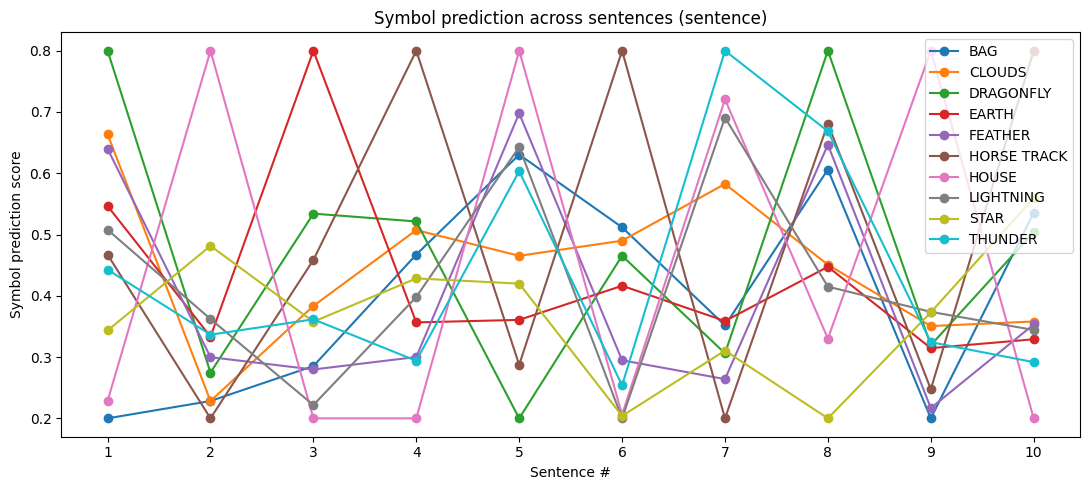

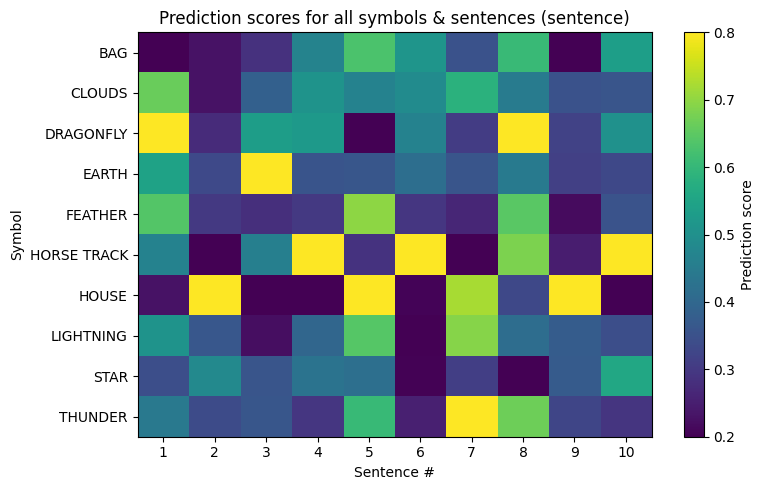

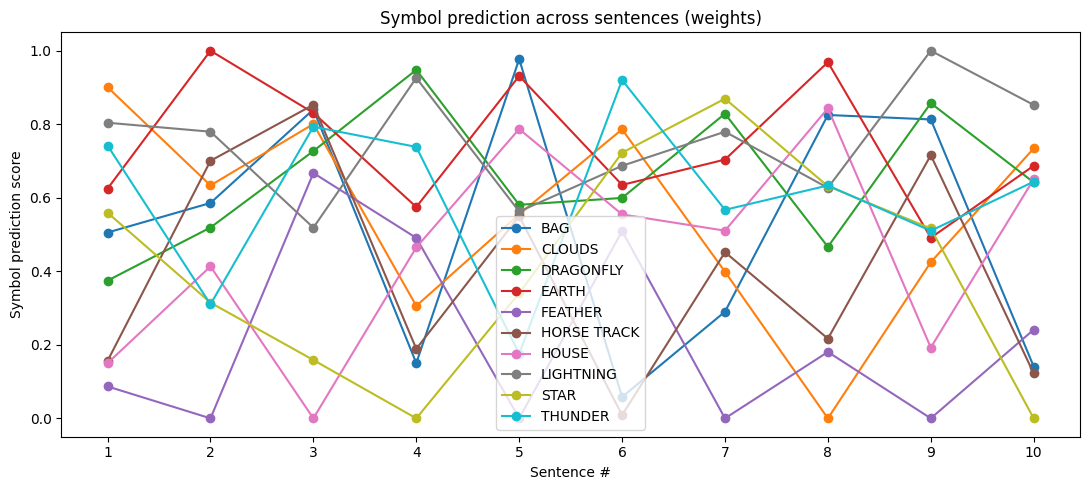

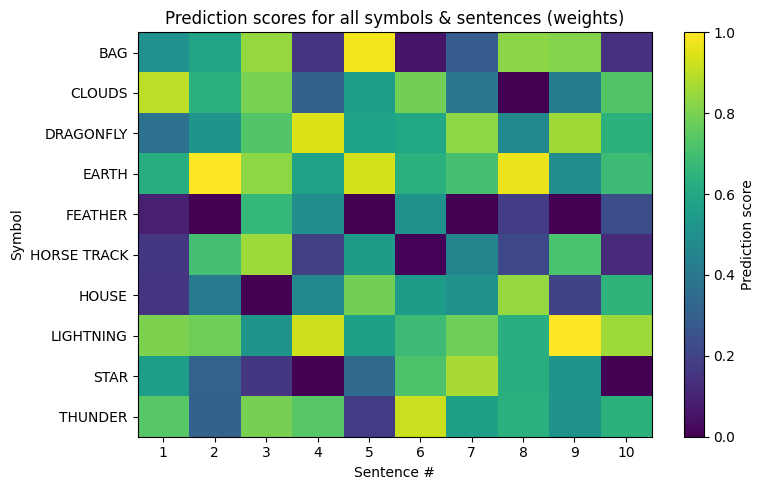

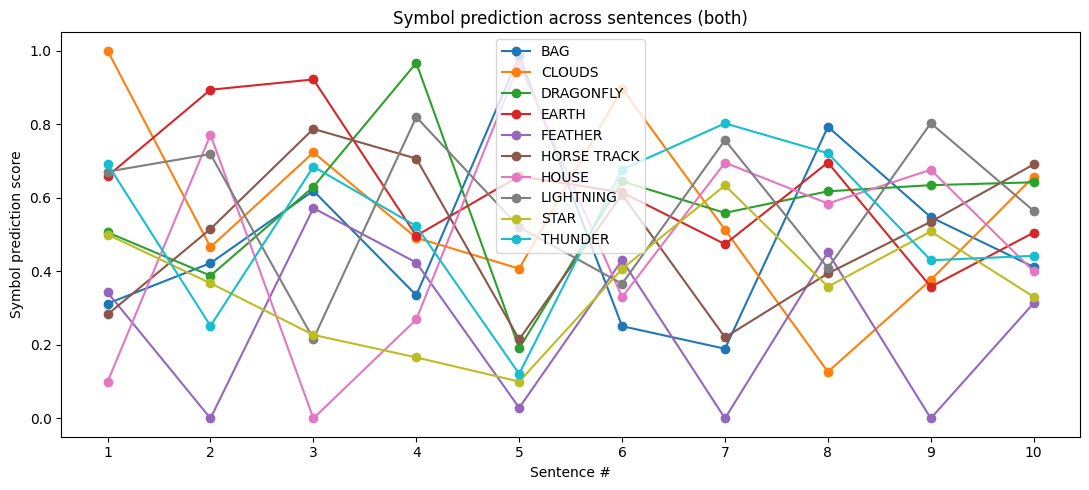

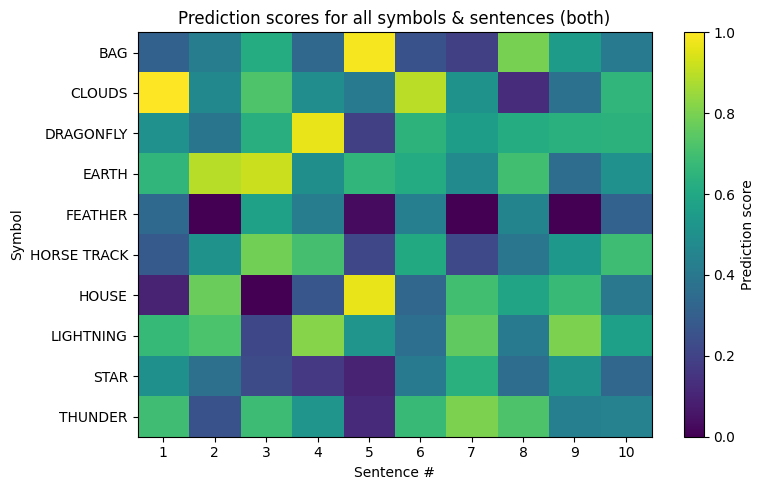

c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\skite\miniconda3\envs\adalog\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


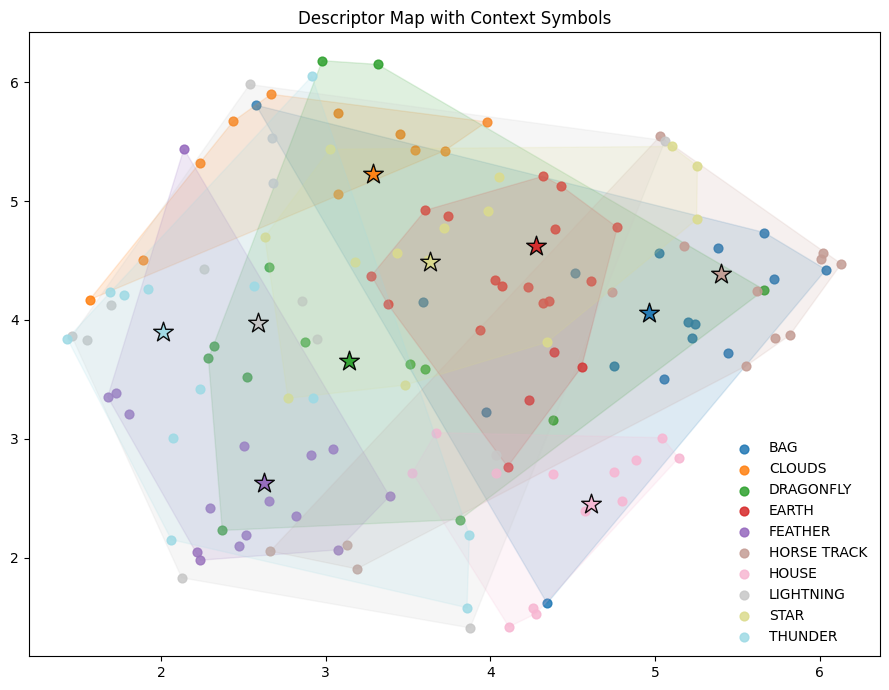


[Ambiguity metrics]
BAG    | dispersion=0.713  leakage=0.738  entropy=2.298
CLOUDS | dispersion=0.700  leakage=0.800  entropy=2.297
DRAGONFLY | dispersion=0.793  leakage=0.877  entropy=2.299
EARTH  | dispersion=0.719  leakage=0.758  entropy=2.300
FEATHER | dispersion=0.652  leakage=0.575  entropy=2.297
HORSE TRACK | dispersion=0.678  leakage=0.677  entropy=2.297
HOUSE  | dispersion=0.710  leakage=0.731  entropy=2.299
LIGHTNING | dispersion=0.740  leakage=0.823  entropy=2.299
STAR   | dispersion=0.776  leakage=0.843  entropy=2.300
THUNDER | dispersion=0.726  leakage=0.775  entropy=2.298


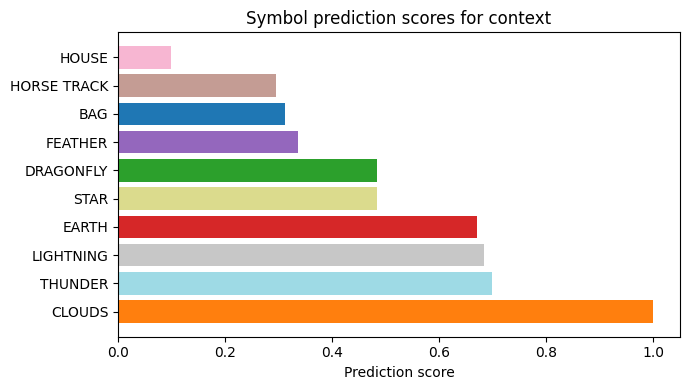

C:\Users\skite\AppData\Local\Temp\ipykernel_38896\1407237932.py:417: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


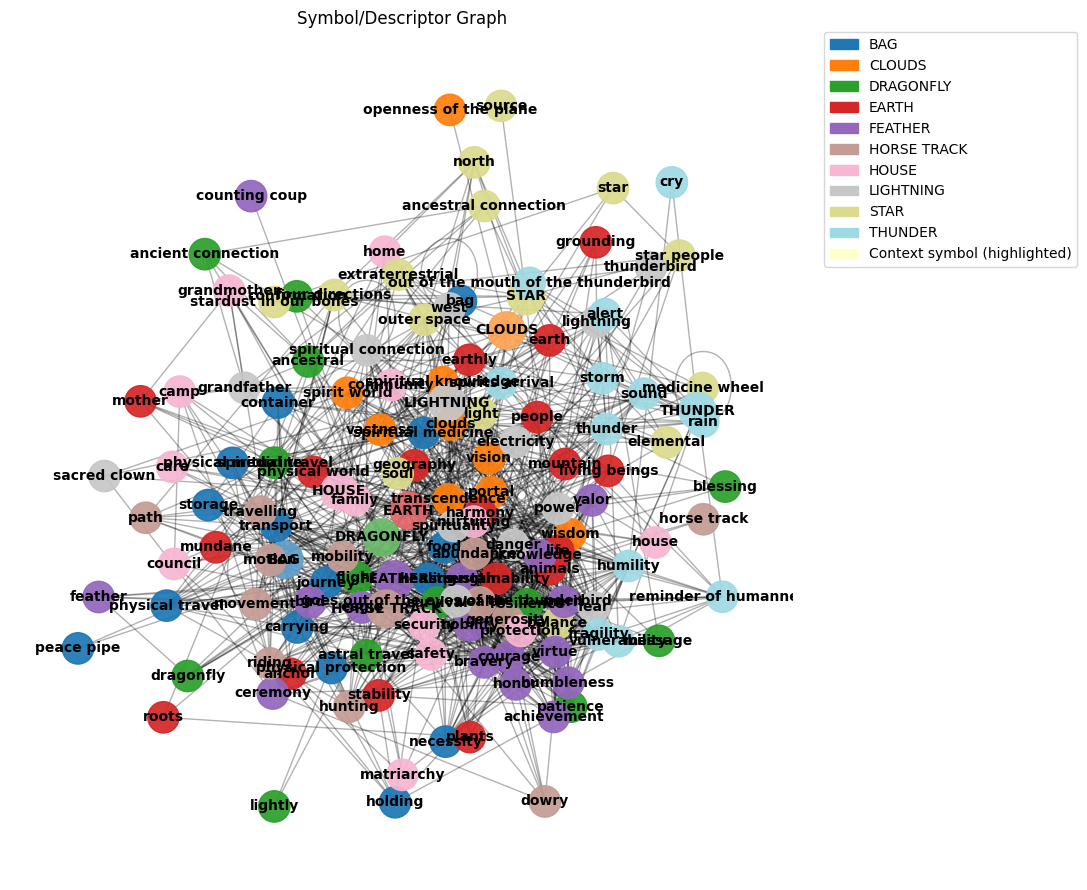

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ------------------------
# Insert your SymbolSpace and TextEmbedder definitions here!
# ------------------------

def demo():
    import random

    symbols_to_descriptors = {
        "BAG": [
            "bag", "movement", "storage", "transport", "physical medicine",
            "spiritual medicine", "peace pipe", "healing", "necessity", "holding",
            "physical travel", "container", "physical protection", "carrying", "journey", "food"
        ],
        "CLOUDS": [
            "clouds", "rain", "spiritual connection", "vision", "spiritual knowledge",
            "spirit world", "portal", "transcendence", "wisdom", "openness of the plane", "vastness"
        ],
        "DRAGONFLY": [
            "dragonfly", "resilience", "ancient connection", "ancestral", "confirmation",
            "message", "spiritual travel", "flight", "astral travel", "lightly", "blessing",
            "patience", "survival"
        ],
        "EARTH": [
            "earth", "people", "animals", "living beings", "plants", "roots", "mother",
            "geography", "mountain", "earthly", "mundane", "physical world", "harmony",
            "life", "sustainability", "balance", "grounding", "anchor", "stability"
        ],
        "FEATHER": [
            "feather", "achievement", "honor", "bravery", "merit", "counting coup",
            "courage", "knowledge", "eagle", "bird", "ceremony", "humbleness", "nobility",
            "virtue", "valor", "strength"
        ],
        "HORSE TRACK": [
            "horse track", "wealth", "travelling", "movement", "path", "motion",
            "riding", "hunting", "abundance", "dowry", "generosity", "west", "mobility"
        ],
        "HOUSE": [
            "house", "nurturing", "protection", "security", "home", "community",
            "matriarchy", "camp", "family", "care", "council", "grandmother", "safety"
        ],
        "LIGHTNING": [
            "lightning", "power", "thunderbird", "sacred clown", "spirituality", "storm",
            "spiritual connection", "electricity", "west", "fear", "grandfather", "danger",
            "goes out of the eyes of the thunderbird"
        ],
        "STAR": [
            "star", "medicine wheel", "four directions", "north", "ancestral connection",
            "stardust in our bones", "elemental", "extraterrestrial", "star people", "soul",
            "source", "light", "outer space", "balance"
        ],
        "THUNDER": [
            "thunder", "storm", "sound", "cry", "rain", "alert", "spirits arrival",
            "humility", "reminder of humanness", "fragility", "vulnerability", "out of the mouth of the thunderbird"
        ]
    }

    space = SymbolSpace(symbols_to_descriptors, TextEmbedder())

    random_sentences = [
        "The shimmering insect hovers over the pond",
        "We gather near the fireplace for warmth",
        "Roots spread quietly in fertile ground",
        "A winding path leads into the forest",
        "She puts secrets in her pocket",
        "A nimble journey across the meadow",
        "The stone house protects from the storm",
        "Agility is key to navigating change",
        "Family sits at the doorway, sharing stories",
        "The adventurer rides on, following hoofprints"
    ]
    n_sent = len(random_sentences)
    symbols = list(symbols_to_descriptors)
    n_sym = len(symbols)

    # --- Random symbol weight context for each sentence
    np.random.seed(1)
    weights_contexts = []
    for _ in range(n_sent):
        w = np.random.uniform(0, 1, n_sym)
        w /= w.sum()
        weights_contexts.append({s: float(wi) for s, wi in zip(symbols, w)})

    symbol_preds_sentence = np.zeros((n_sent, n_sym))
    symbol_preds_weights = np.zeros((n_sent, n_sym))
    symbol_preds_both = np.zeros((n_sent, n_sym))

    print("\nPredictions per sentence (all context types):\n")
    for i, sent in enumerate(random_sentences):
        preds_sent = space.propose(sentence=sent, topk=n_sym)
        preds_weight = space.propose(weights=weights_contexts[i], topk=n_sym)
        preds_both = space.propose(weights=weights_contexts[i], sentence=sent, topk=n_sym)
        for j, (s, score, _, _) in enumerate(preds_sent):
            symbol_preds_sentence[i, symbols.index(s)] = score
        for j, (s, score, _, _) in enumerate(preds_weight):
            symbol_preds_weights[i, symbols.index(s)] = score
        for j, (s, score, _, _) in enumerate(preds_both):
            symbol_preds_both[i, symbols.index(s)] = score

        print(f"Sentence {i+1:2d}: {sent}")
        print(f"  - Most predicted by sentence:   {symbols[np.argmax(symbol_preds_sentence[i])]}")
        print(f"  - Most predicted by weights:    {symbols[np.argmax(symbol_preds_weights[i])]}")
        print(f"  - Most predicted by both:       {symbols[np.argmax(symbol_preds_both[i])]}")
        print("-" * 60)

    # --- Plotting ---

    colors = cm.tab10(np.linspace(0, 1, n_sym))

    for name, arr, cond in [
        ("Sentence only", symbol_preds_sentence, "sentence"),
        ("Weights only", symbol_preds_weights, "weights"),
        ("Both sentence + weights", symbol_preds_both, "both"),
    ]:
        plt.figure(figsize=(11, 5))
        for si, s in enumerate(symbols):
            plt.plot(range(n_sent), arr[:, si], marker="o", color=colors[si], label=s)
        plt.xticks(range(n_sent), [f"{i+1}" for i in range(n_sent)], rotation=0)
        plt.xlabel("Sentence #")
        plt.ylabel("Symbol prediction score")
        plt.title(f"Symbol prediction across sentences ({cond})")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()

        # Heatmap
        plt.figure(figsize=(8, 5))
        im = plt.imshow(arr.T, aspect='auto', cmap='viridis')
        plt.yticks(range(n_sym), symbols)
        plt.xticks(range(n_sent), [f"{i+1}" for i in range(n_sent)], rotation=0)
        plt.xlabel("Sentence #")
        plt.ylabel("Symbol")
        plt.title(f"Prediction scores for all symbols & sentences ({cond})")
        plt.colorbar(im, label='Prediction score')
        plt.tight_layout()
        plt.show()

    # plot the descriptor map
    space.plot_map(title="Descriptor Map with Context Symbols")

    # print the dispersion, leakage, and entropy for each symbol
    print("\n[Ambiguity metrics]")
    for s in space.symbols:
        print(f"{s:6s} | dispersion={space.dispersion(s):.3f}  "              f"leakage={space.leakage(s):.3f}  "
              f"entropy={space.soft_entropy(s):.3f}")
    space.plot_symbol_predictions(weights=weights_contexts[0], sentence=random_sentences[0],
                                  title="Symbol prediction scores for context")

    space.plot_graph(context_symbols=["BAG", "EARTH", "CLOUDS", "DRAGONFLY"])
if __name__ == "__main__":
    demo()


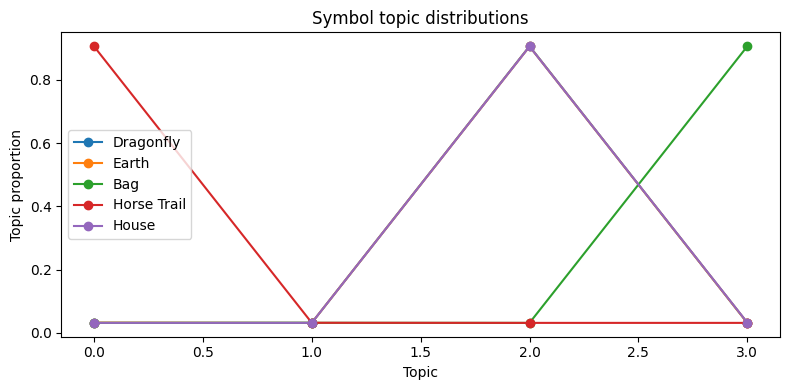

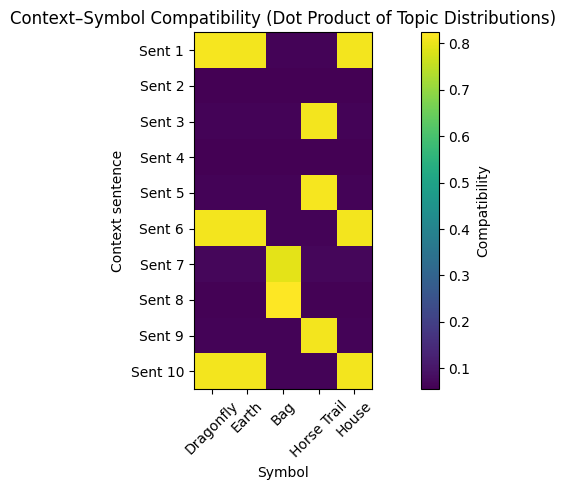

Most compatible symbol for each context:
A shimmering insect dances above the wat... => Dragonfly
We return to our warm house at night.... => Bag
Roots spread quietly in the earth.... => Horse Trail
A traveler ties a leather bag for the lo... => Horse Trail
Freedom is found along winding trails.... => Horse Trail
The pond is alive with flight.... => Dragonfly
Warmth gathers around the hearth.... => Bag
A container for all things needed to tra... => Bag
Stones and soil create the foundation.... => Horse Trail
The translucent wings shimmer in sunligh... => Dragonfly


In [26]:
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Symbols and their descriptors (as a 'document')
symbols_to_descriptors = {
    "Dragonfly": ["hover", "pond", "shimmer", "transform", "flight", "water", "translucent"],
    "Earth": ["soil", "roots", "fertile", "ground", "stone", "home", "stable"],
    "Bag": ["container", "carry", "leather", "pouch", "travel", "hold", "portable"],
    "Horse Trail": ["path", "hoof", "journey", "winding", "dust", "freedom", "explore"],
    "House": ["shelter", "roof", "home", "warmth", "gather", "hearth", "walls"],
}

# Convert descriptors to "documents"
symbol_names = list(symbols_to_descriptors)
symbol_docs = [" ".join(descriptors) for descriptors in symbols_to_descriptors.values()]

# Context sentences
context_sentences = [
    "A shimmering insect dances above the water.",
    "We return to our warm house at night.",
    "Roots spread quietly in the earth.",
    "A traveler ties a leather bag for the long journey.",
    "Freedom is found along winding trails.",
    "The pond is alive with flight.",
    "Warmth gathers around the hearth.",
    "A container for all things needed to travel.",
    "Stones and soil create the foundation.",
    "The translucent wings shimmer in sunlight."
]

# All docs = symbols + contexts (LDA needs more docs to extract topics)
all_docs = symbol_docs + context_sentences

# Vectorize
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(all_docs)

# LDA
n_topics = 4
lda = LatentDirichletAllocation(n_components=n_topics, random_state=40)
topic_distribs = lda.fit_transform(X)   # [n_docs, n_topics]

symbol_topic_distribs = topic_distribs[:len(symbol_docs)]
context_topic_distribs = topic_distribs[len(symbol_docs):]

# --- Plot: Symbol Topic Distributions ---
plt.figure(figsize=(8, 4))
for i, (name, topic_vec) in enumerate(zip(symbol_names, symbol_topic_distribs)):
    plt.plot(topic_vec, marker='o', label=name)
plt.xlabel("Topic")
plt.ylabel("Topic proportion")
plt.title("Symbol topic distributions")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot: Compatibility (dot product) between each context and each symbol ---
compatibility = np.dot(context_topic_distribs, symbol_topic_distribs.T)  # [n_context, n_symbol]

plt.figure(figsize=(10, 5))
im = plt.imshow(compatibility, cmap="viridis")
plt.colorbar(im, label="Compatibility")
plt.xticks(np.arange(len(symbol_names)), symbol_names, rotation=45)
plt.yticks(np.arange(len(context_sentences)), [f"Sent {i+1}" for i in range(len(context_sentences))])
plt.title("Context–Symbol Compatibility (Dot Product of Topic Distributions)")
plt.xlabel("Symbol")
plt.ylabel("Context sentence")
plt.tight_layout()
plt.show()

# Print example: which symbol best fits each context?
print("Most compatible symbol for each context:")
for i, ctx in enumerate(context_sentences):
    best_symbol = symbol_names[np.argmax(compatibility[i])]
    print(f"{ctx[:40]}... => {best_symbol}")
